scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating Data (Paul15) ---
Initial raw AnnData object shape (Paul15): (2730, 3451)
Initial raw AnnData .obs keys: ['paul15_clusters']
Initial raw AnnData .var keys: []

Initial raw AnnData .uns keys: ['iroot']

Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference d

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Overall Balanced Accuracy (excluding 'unassigned'): 0.8586
Matthews Correlation Coefficient (MCC) (excluding 'unassigned'): 0.9225

--- Full Classification Report ---
              precision    recall  f1-score   support

       10GMP       1.00      0.02      0.04        46
        11DC       1.00      1.00      1.00         9
      12Baso       1.00      0.10      0.17        21
      13Baso       1.00      0.06      0.11        90
        14Mo       1.00      0.10      0.18       112
        15Mo       0.71      0.09      0.16        56
       16Neu       1.00      0.12      0.22        49
       17Neu       1.00      0.17      0.29         6
       18Eos       1.00      1.00      1.00         3
     19Lymph       1.00      1.00      1.00         9
        1Ery       0.00      0.00      0.00        13
        2Ery       0.90      0.36      0.52        99
        3Ery       1.00      0.15      0.26        74
        4Ery       0.00      0.00      0.00        37
        5Ery       0.7

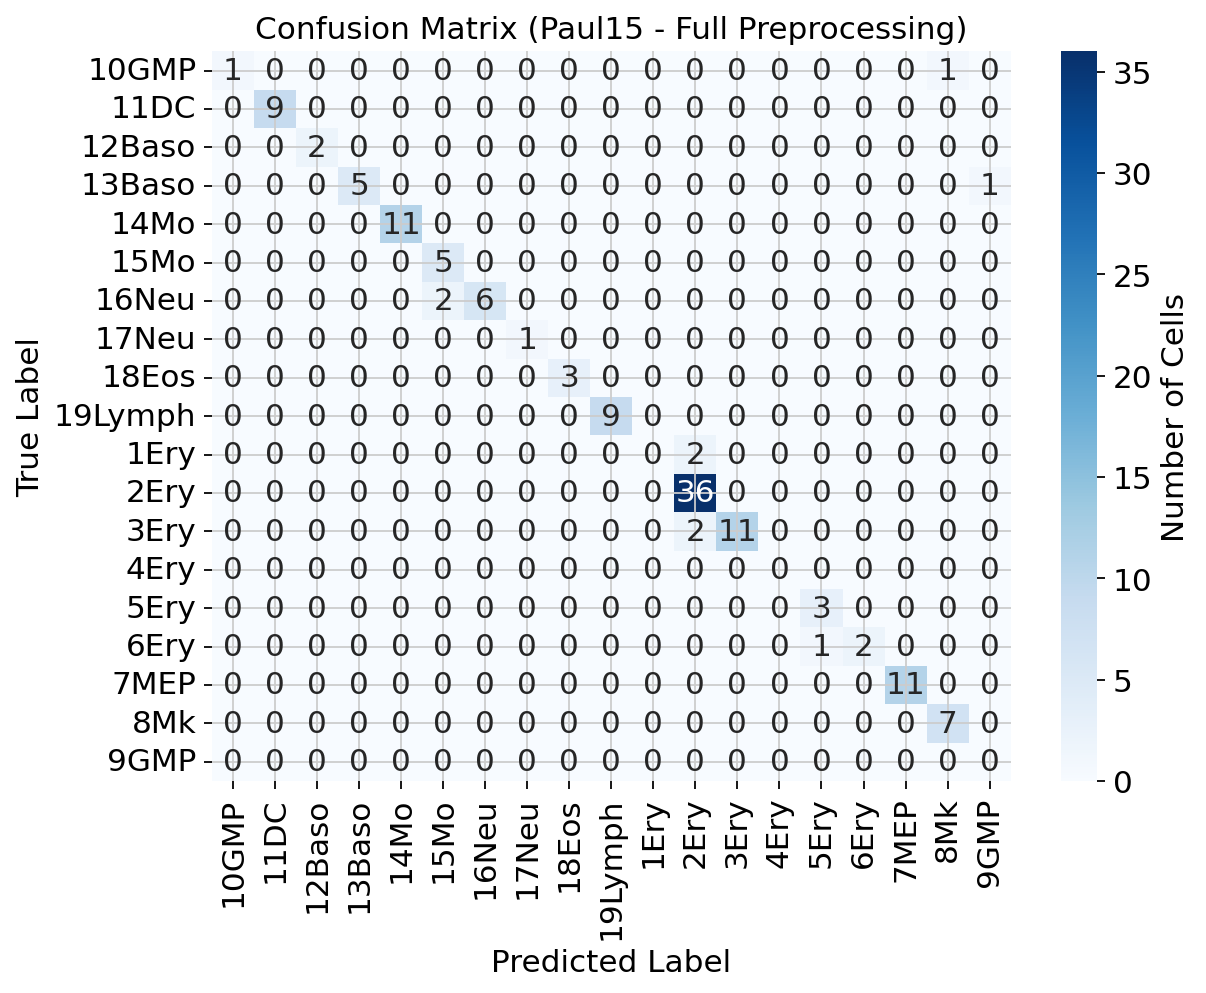


--- Per-Class ROC AUC (Paul15 - Full Preprocessing) ---


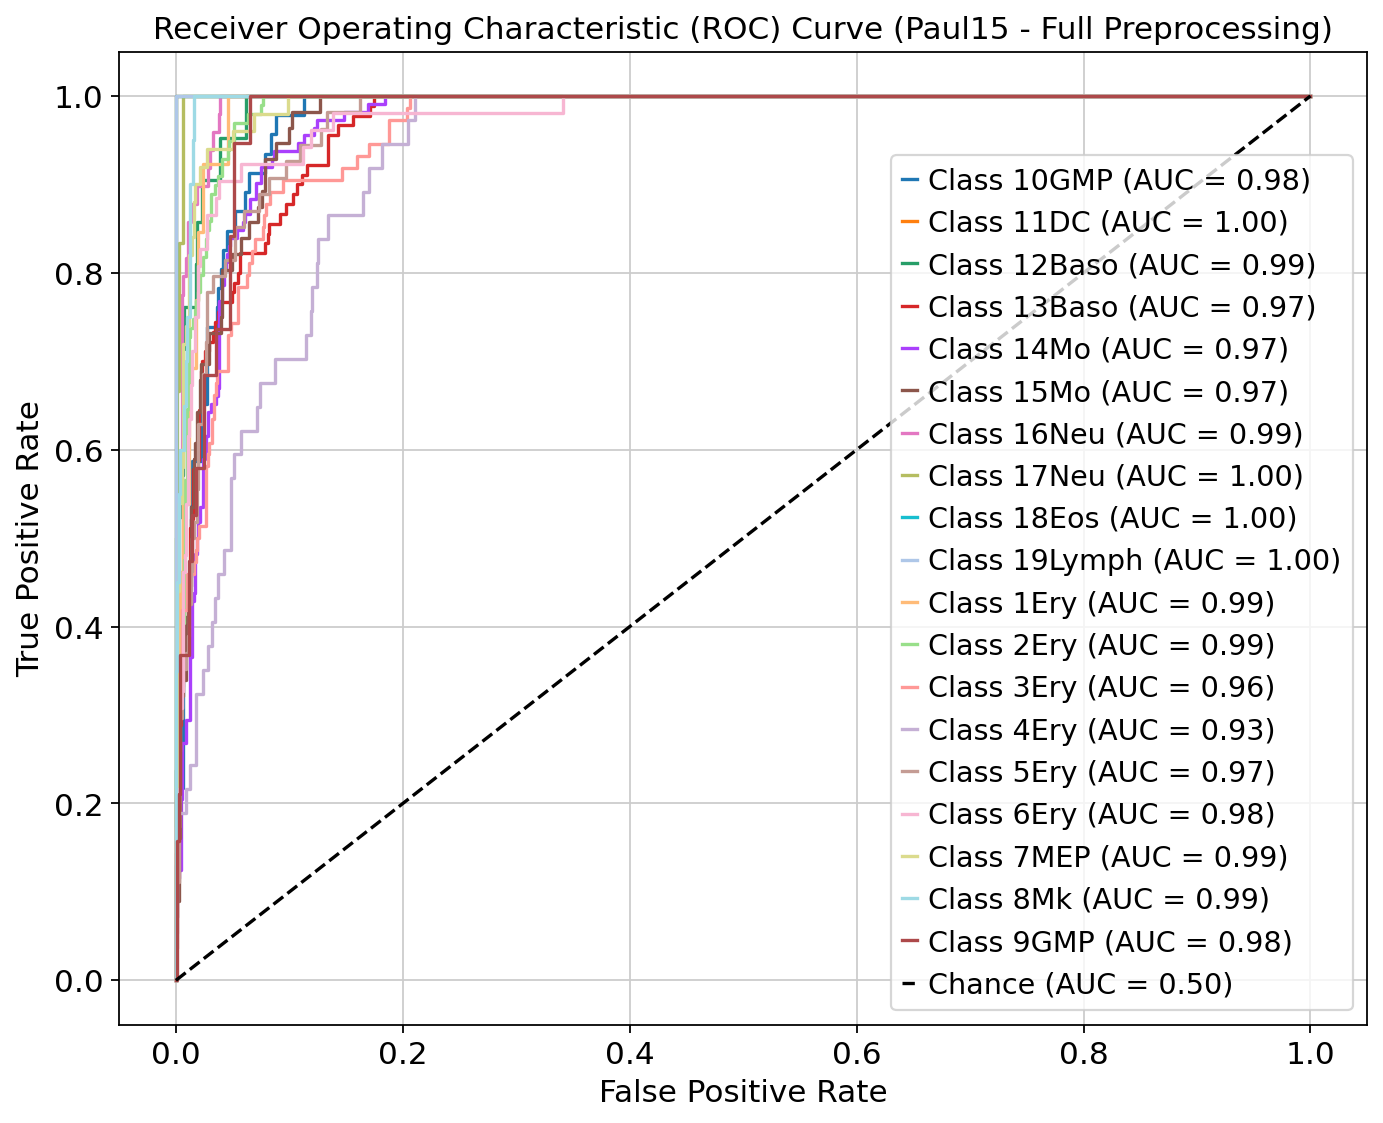


--- Distribution of Prediction Probabilities (Paul15 - Full Preprocessing) ---


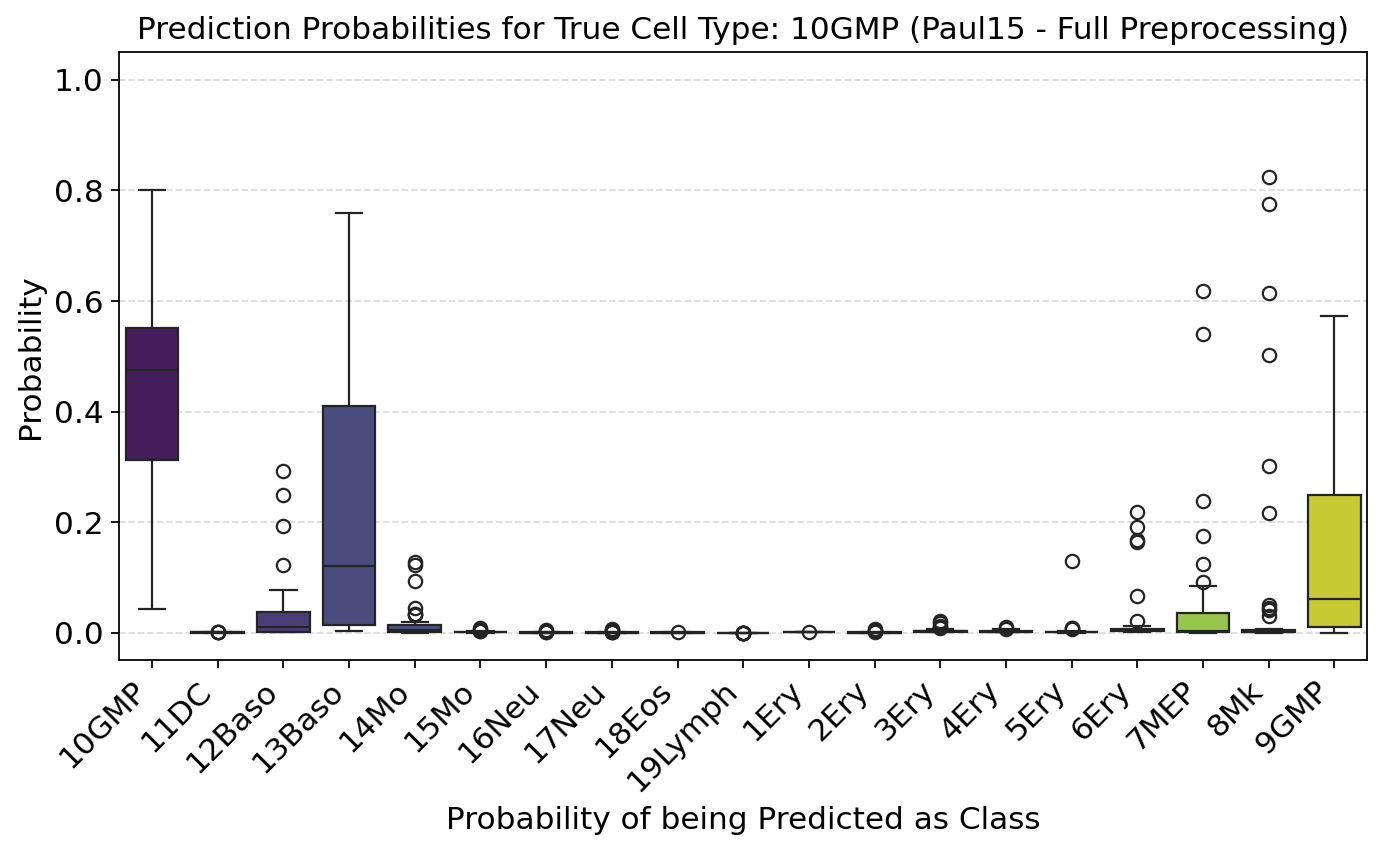

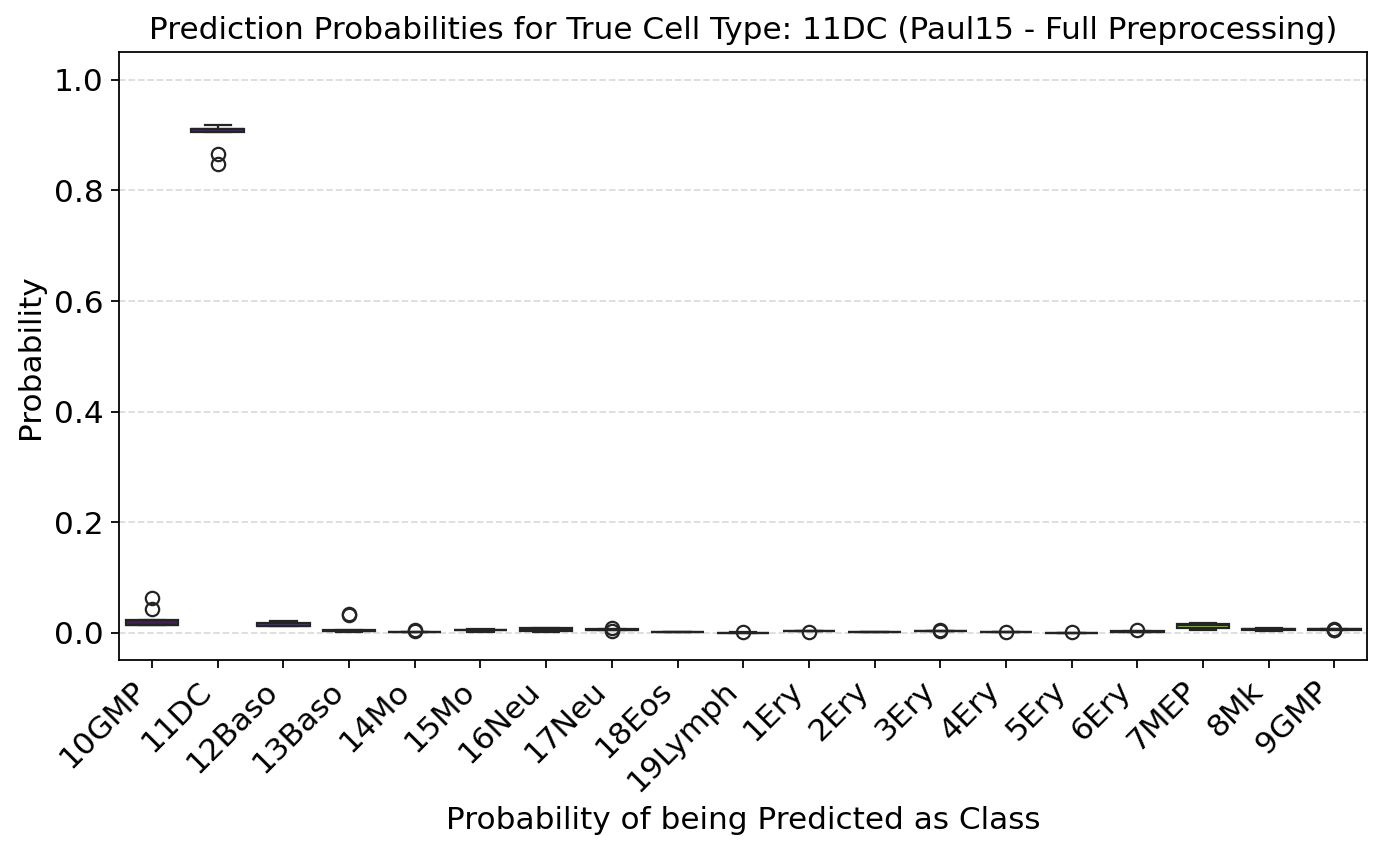

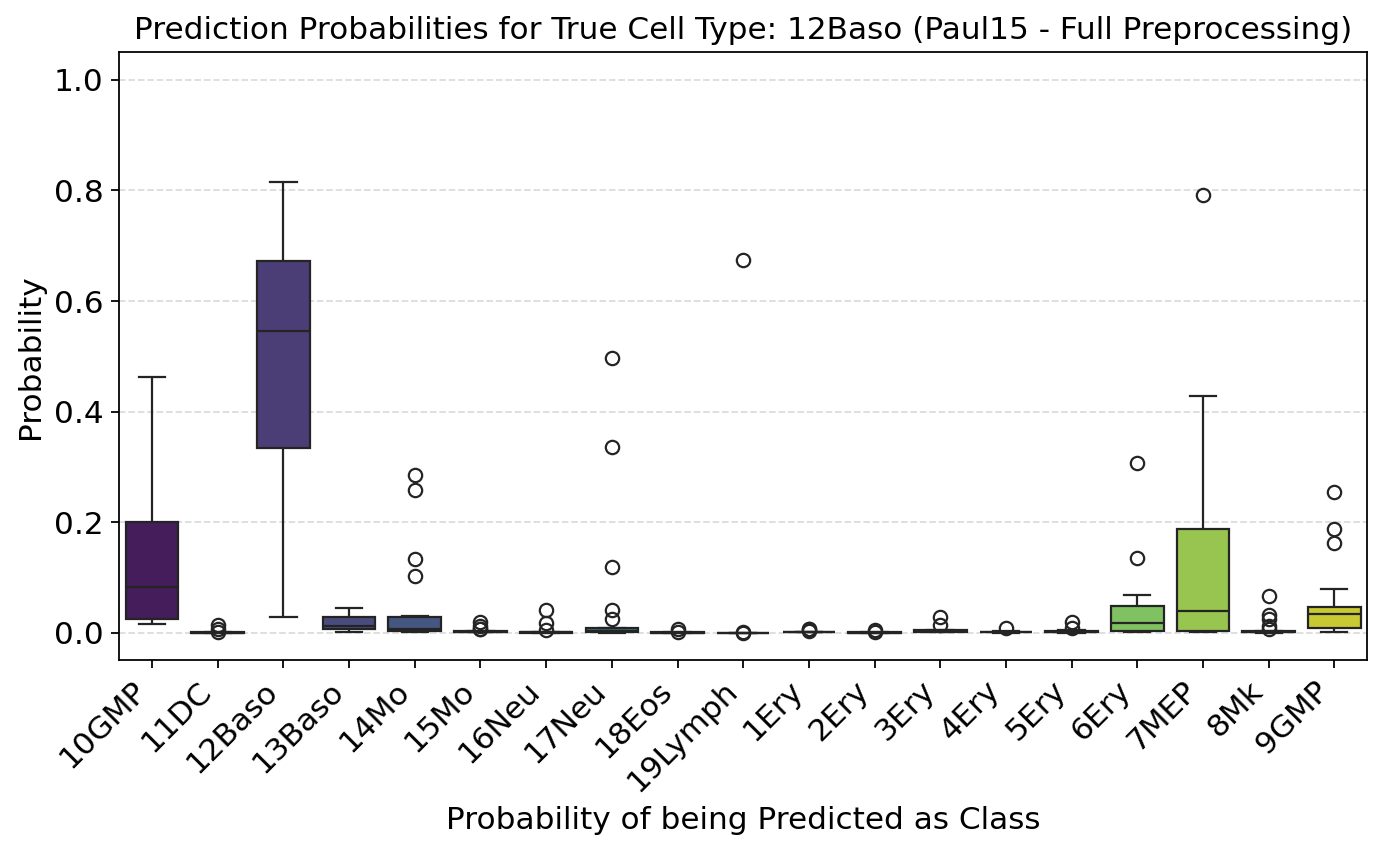

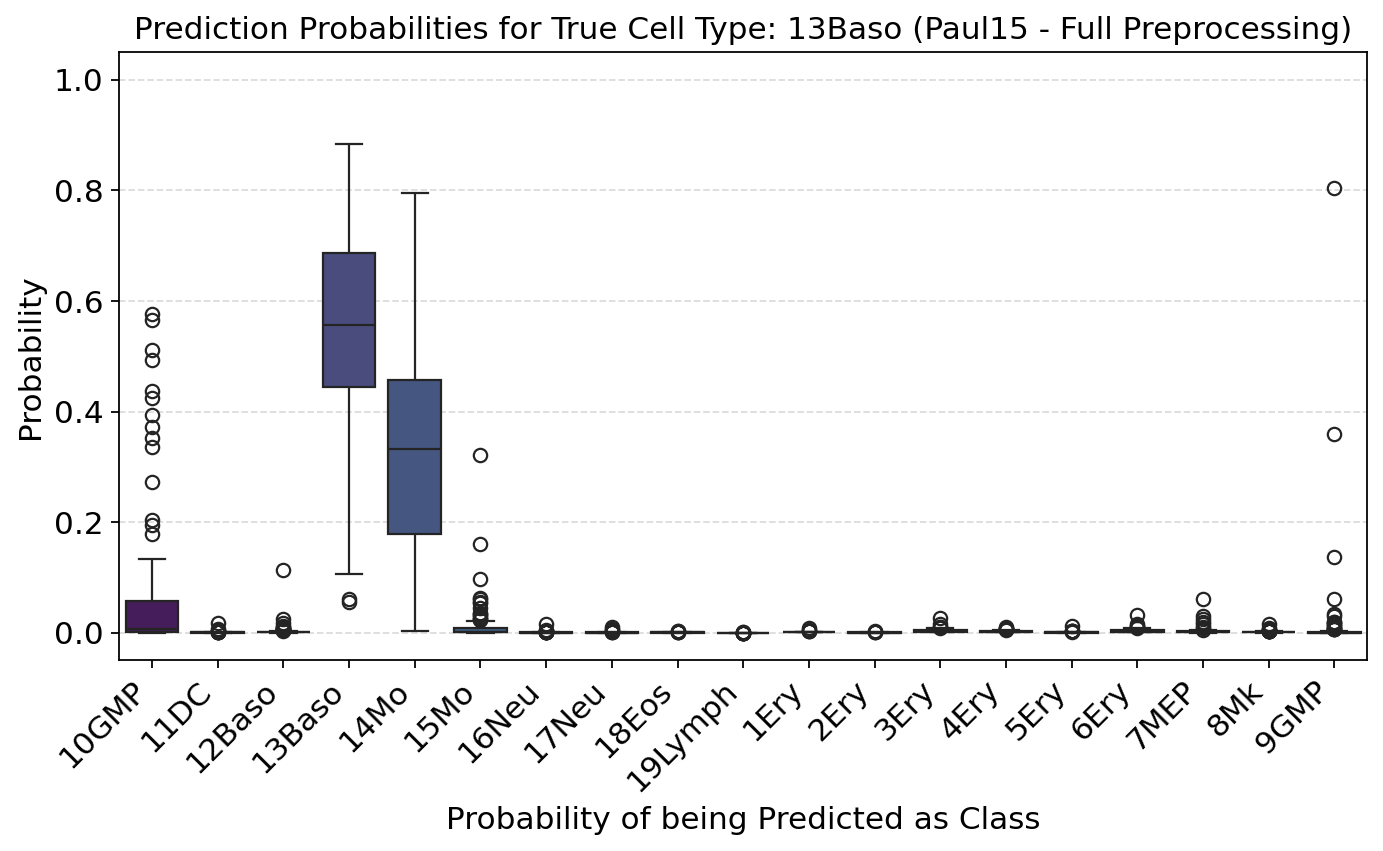

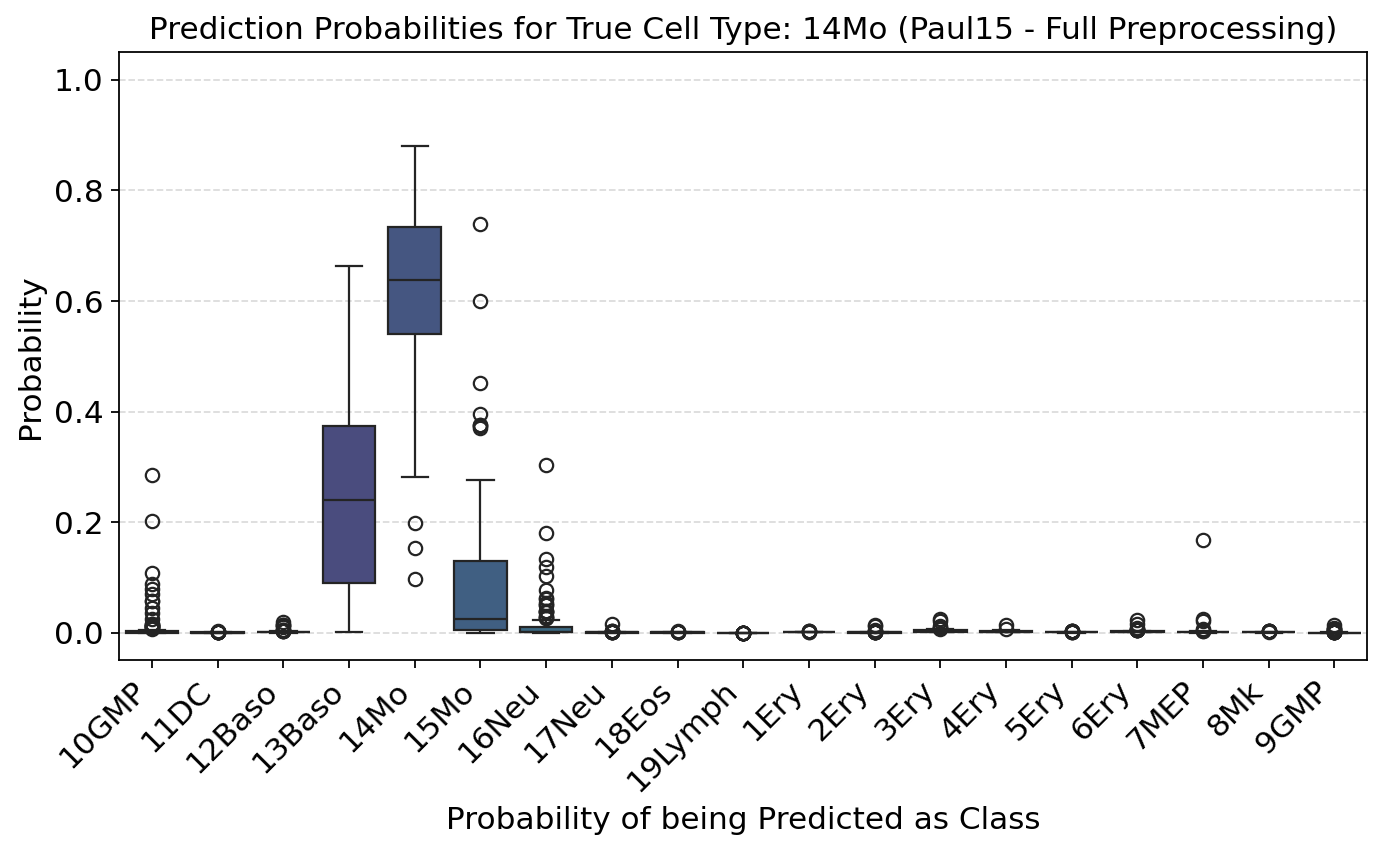

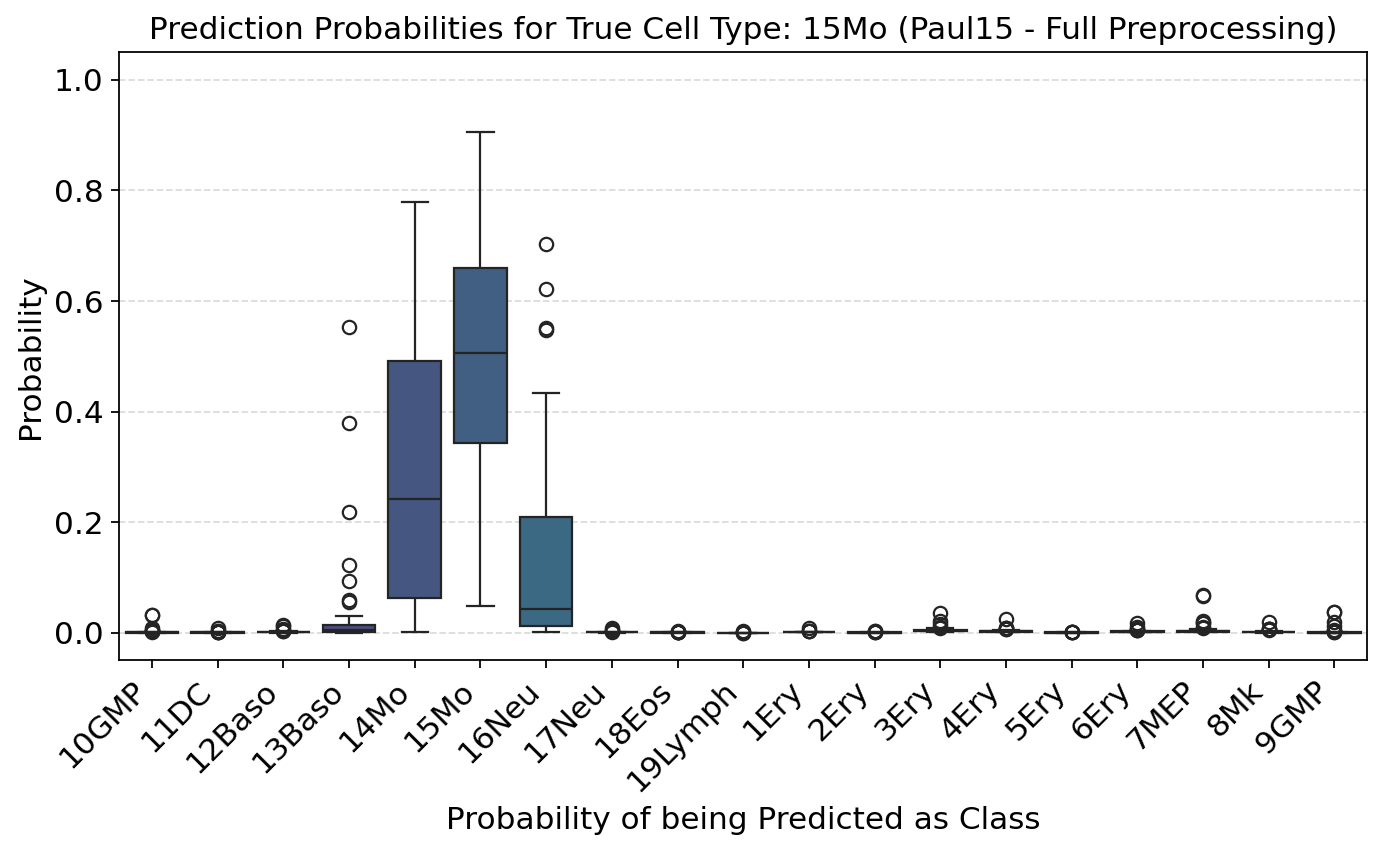

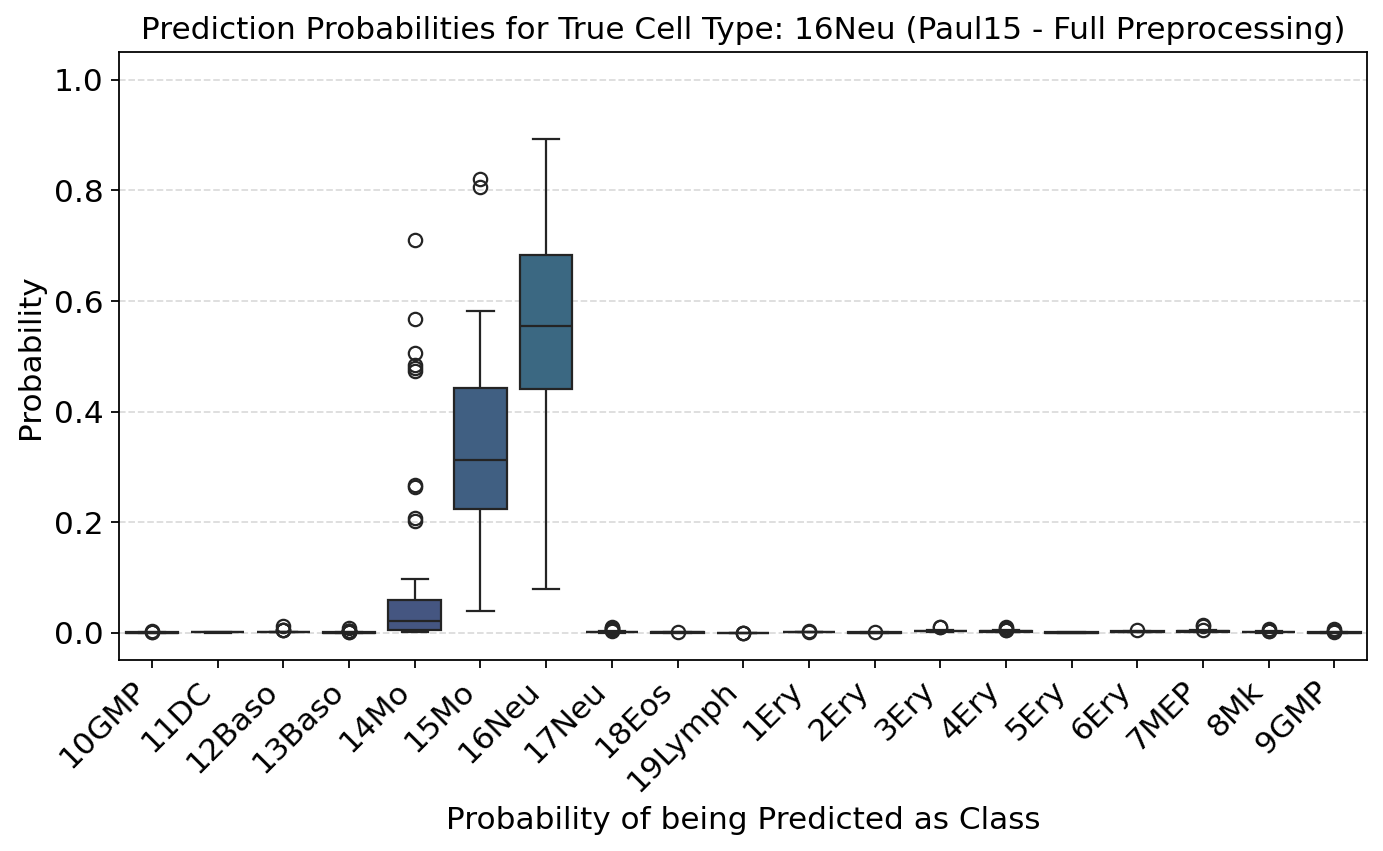

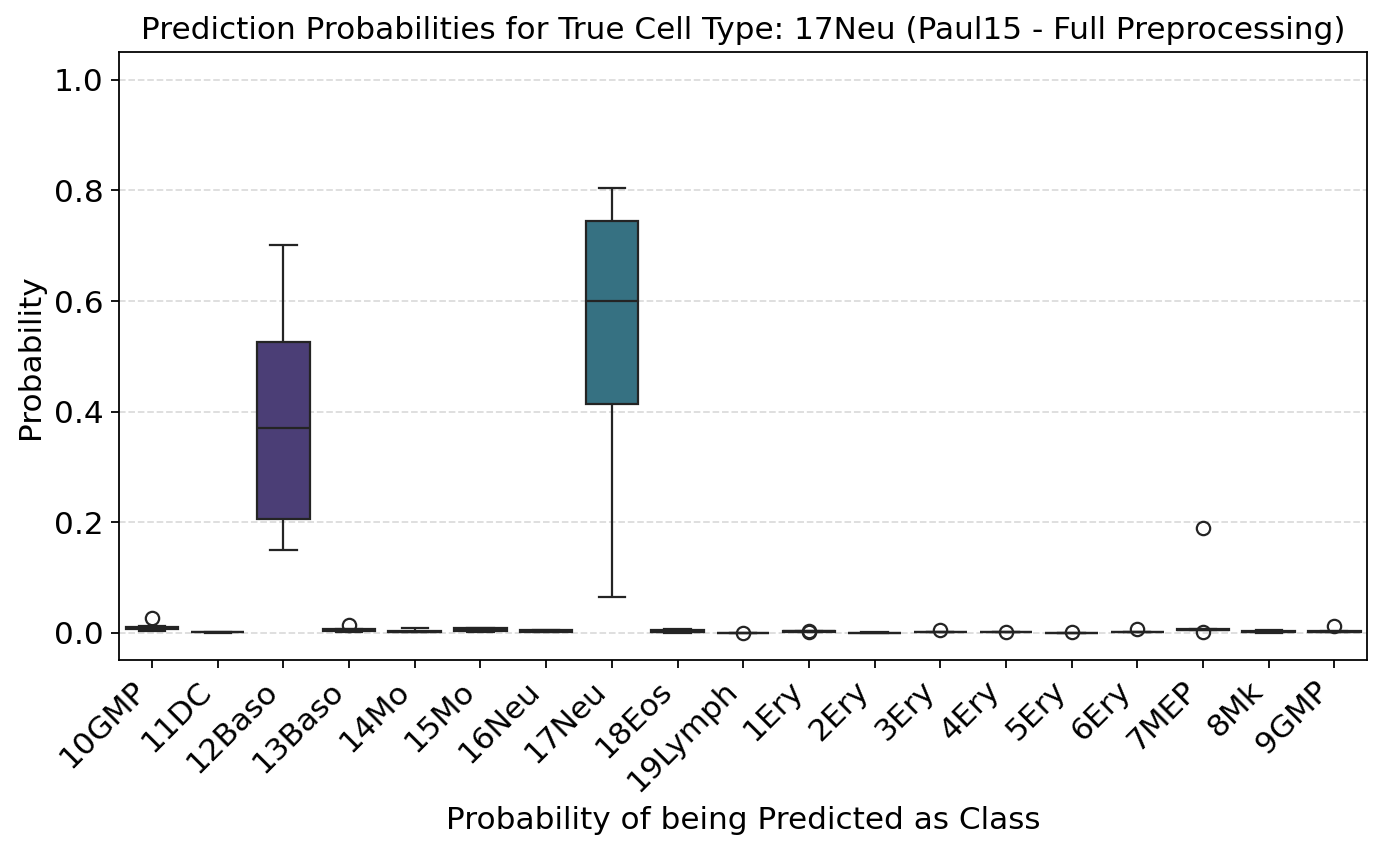

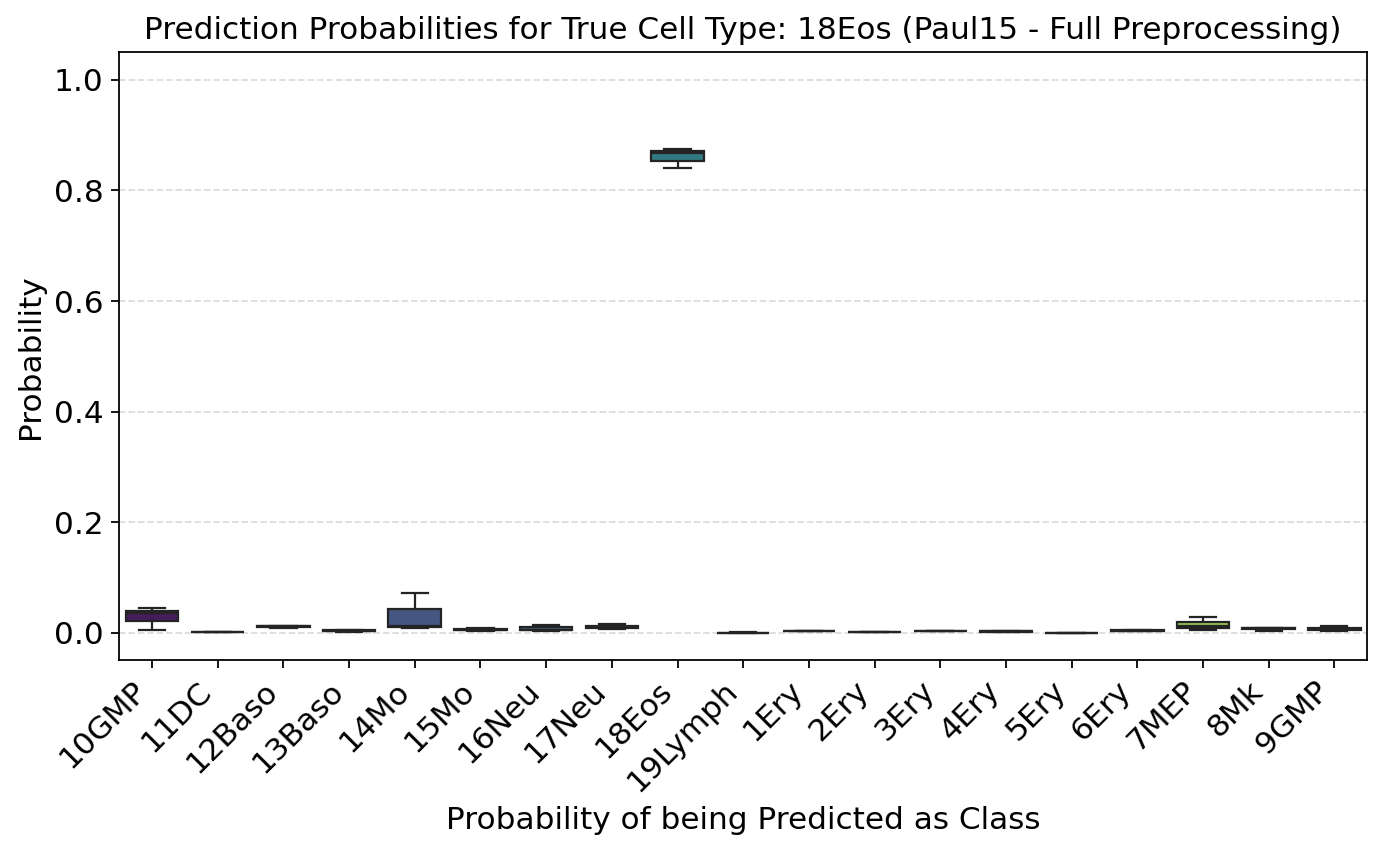

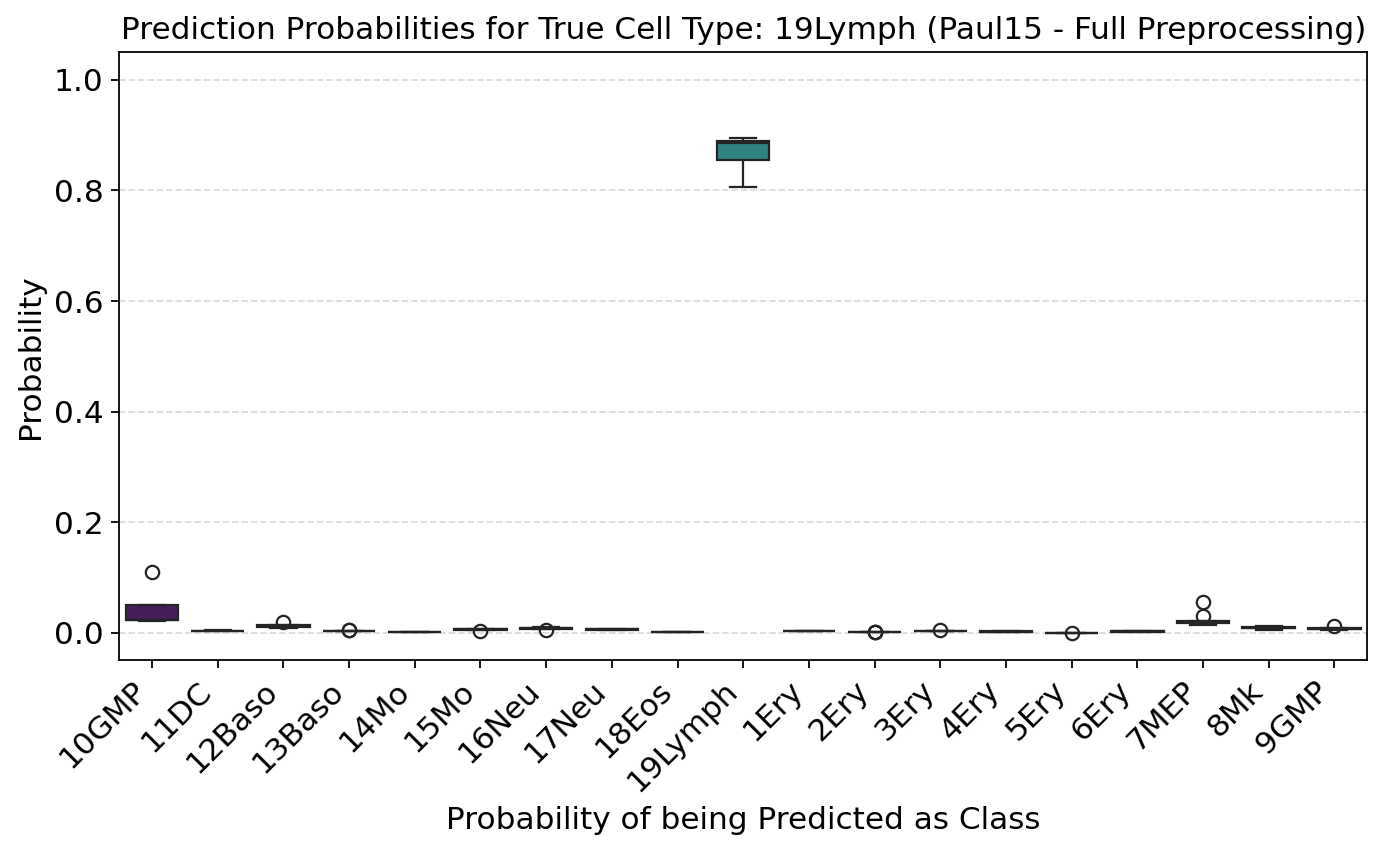

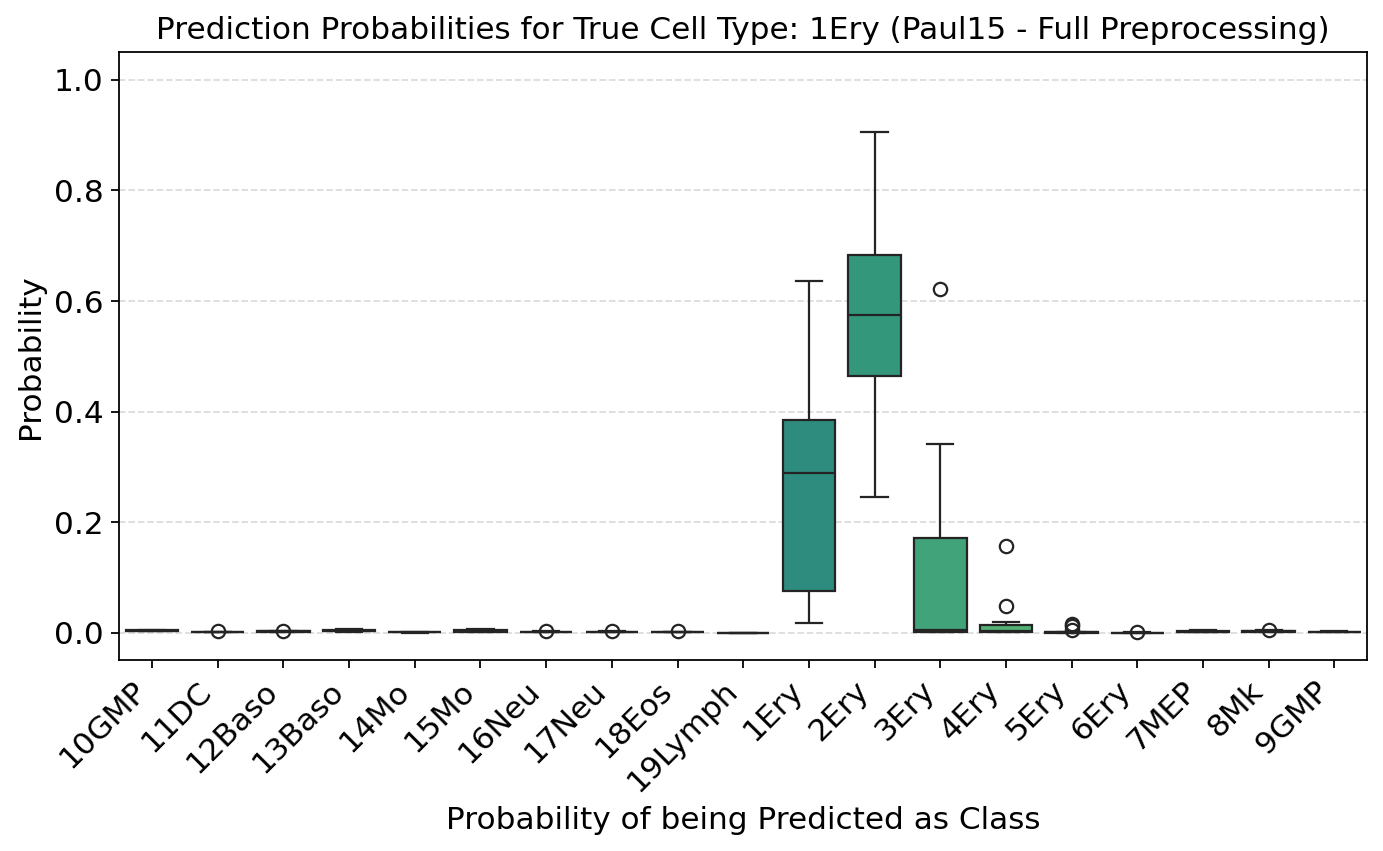

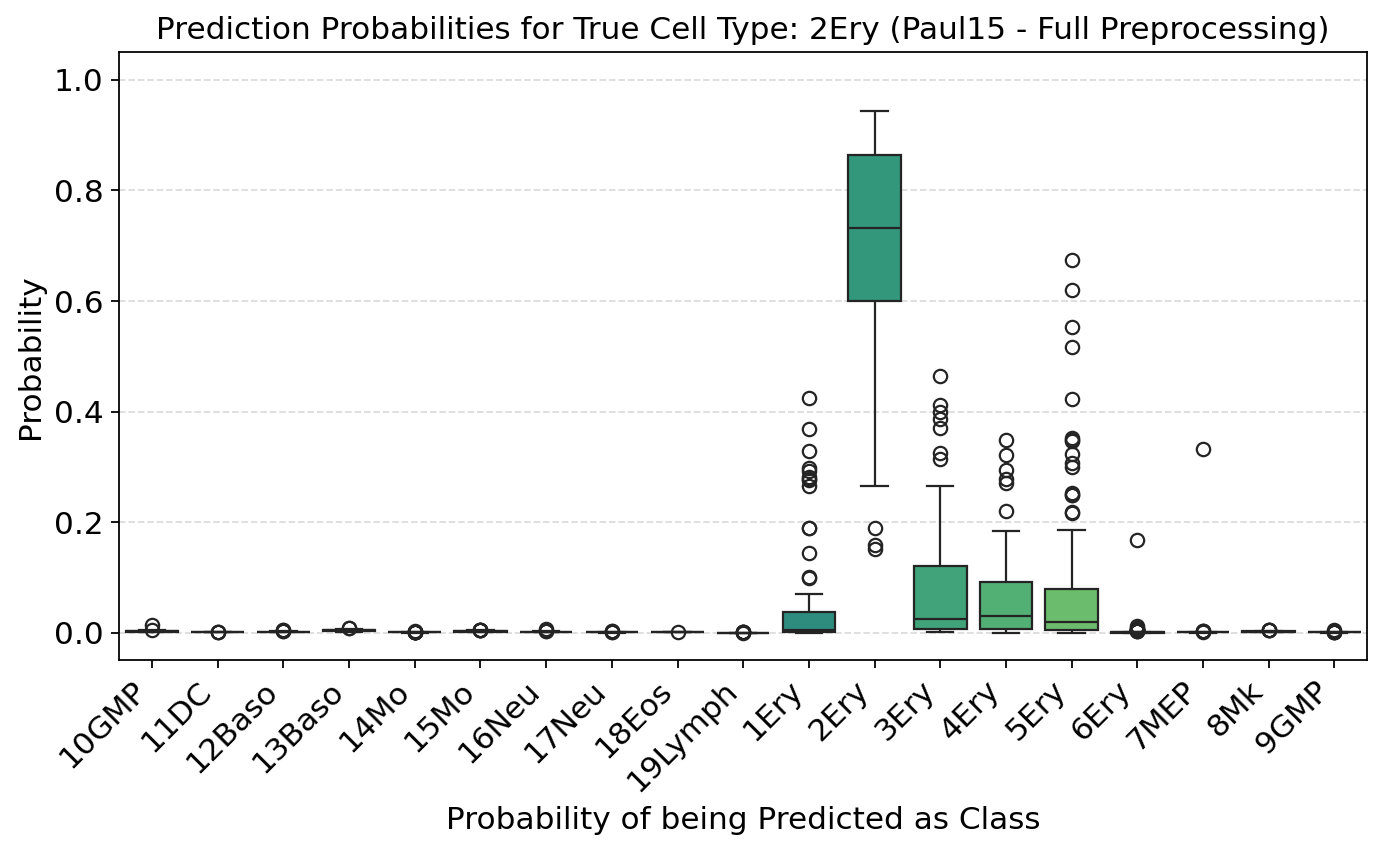

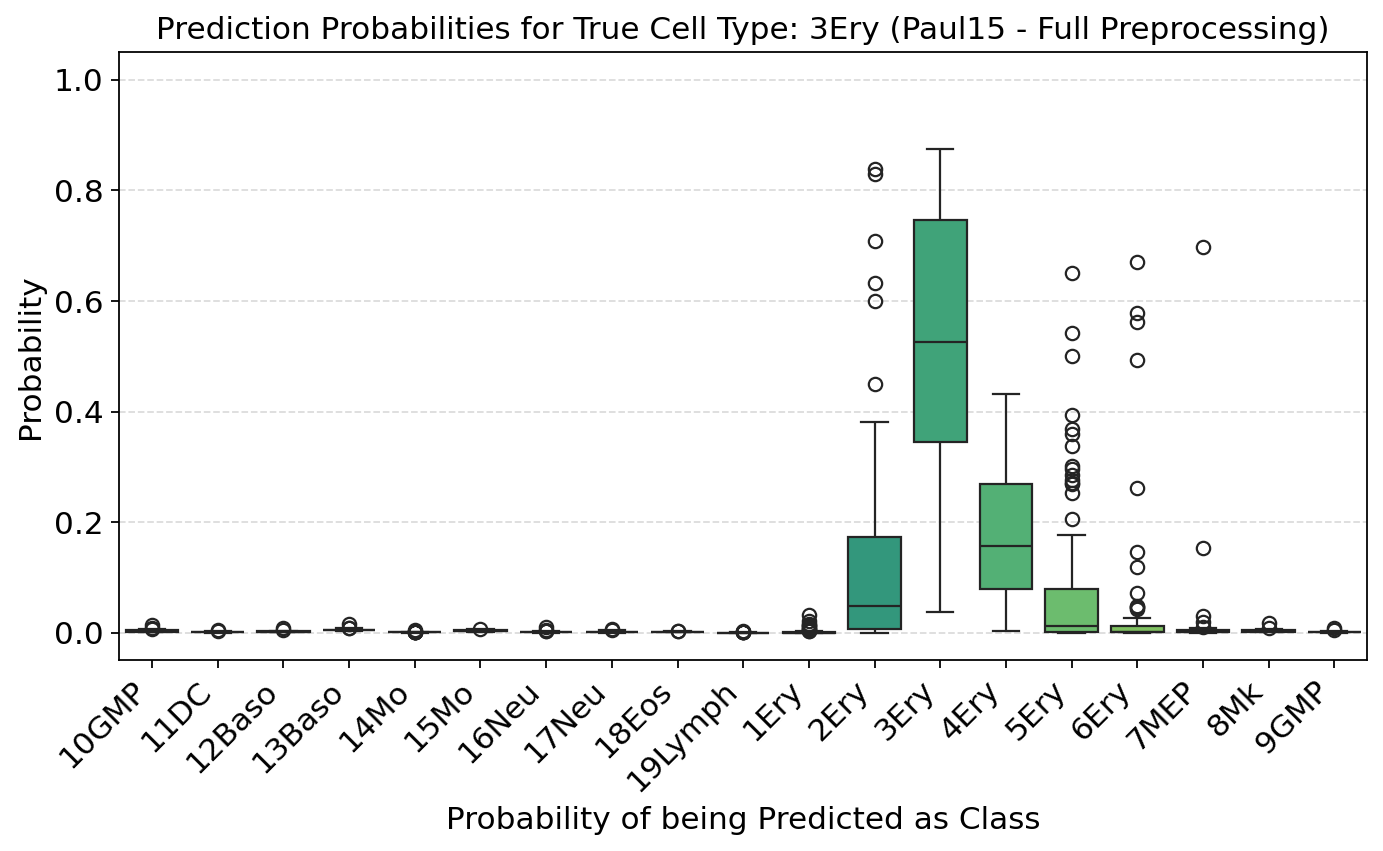

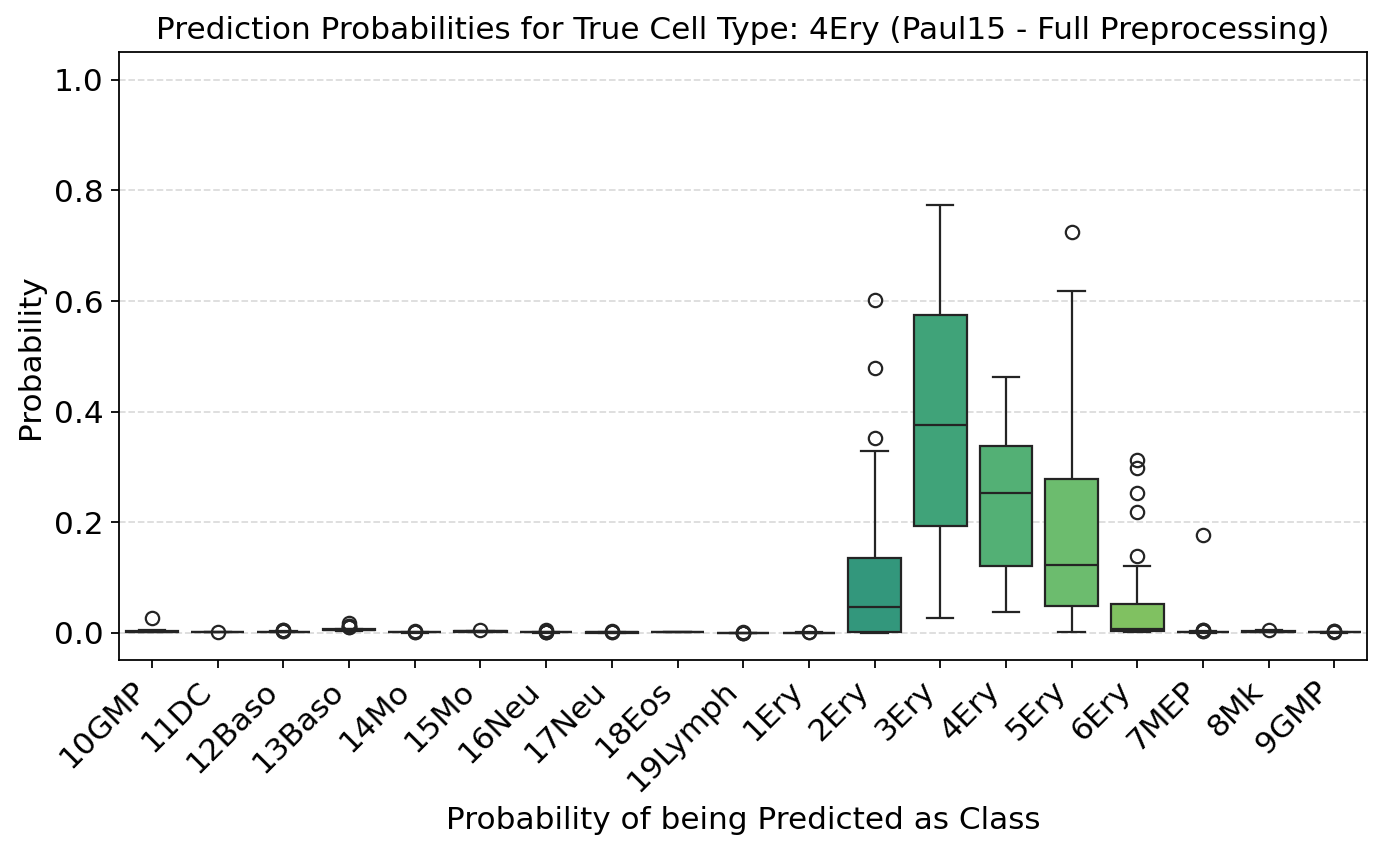

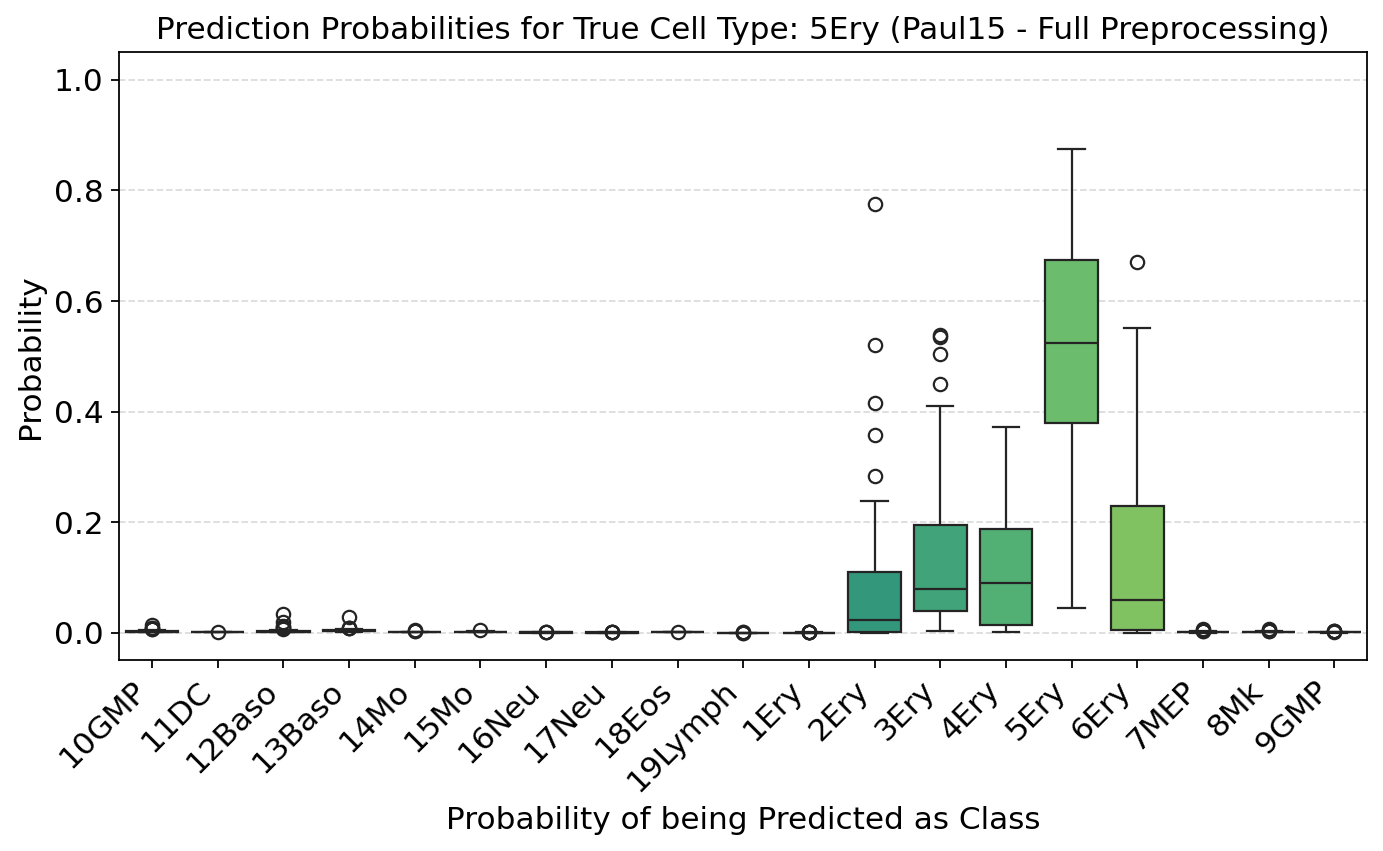

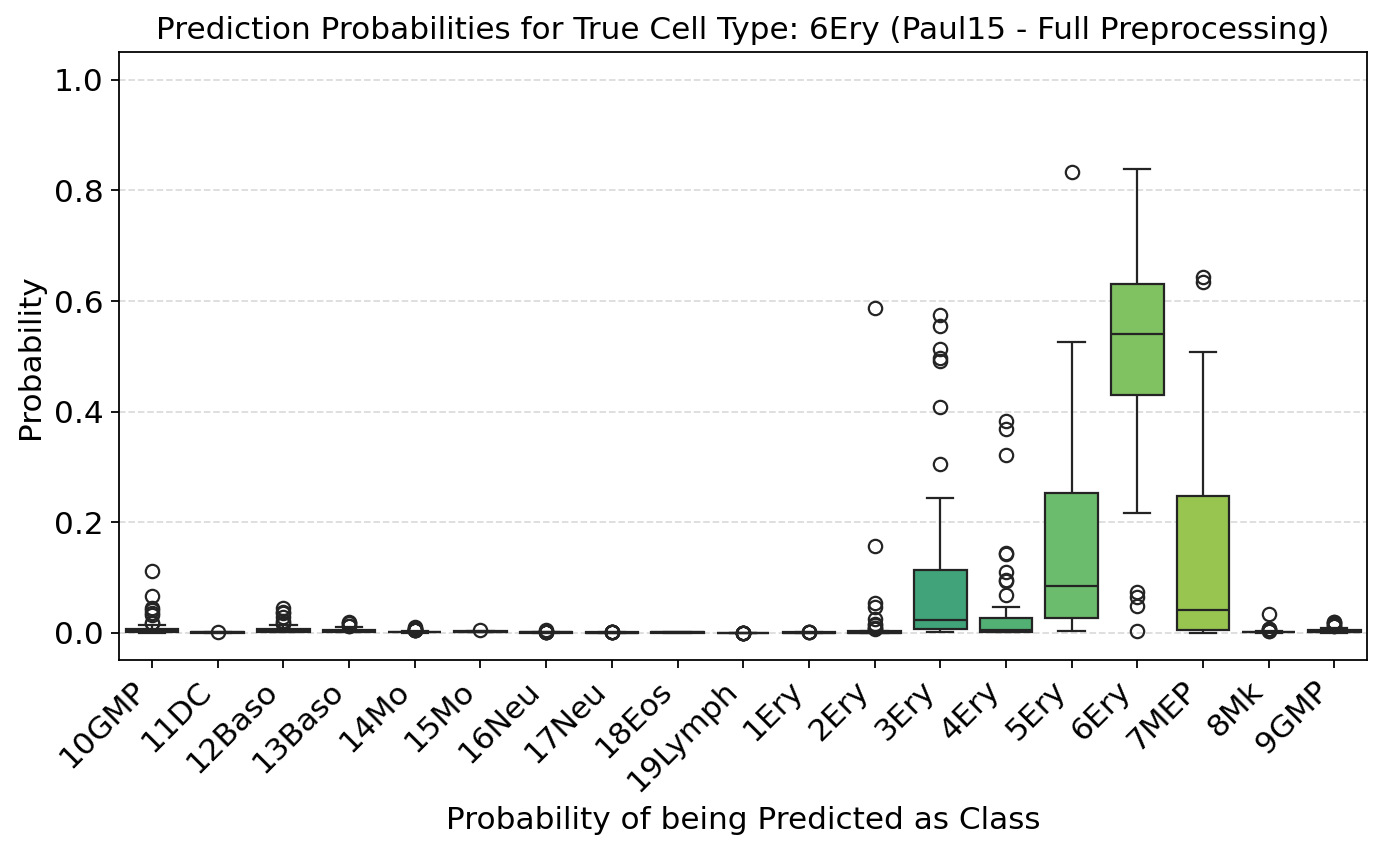

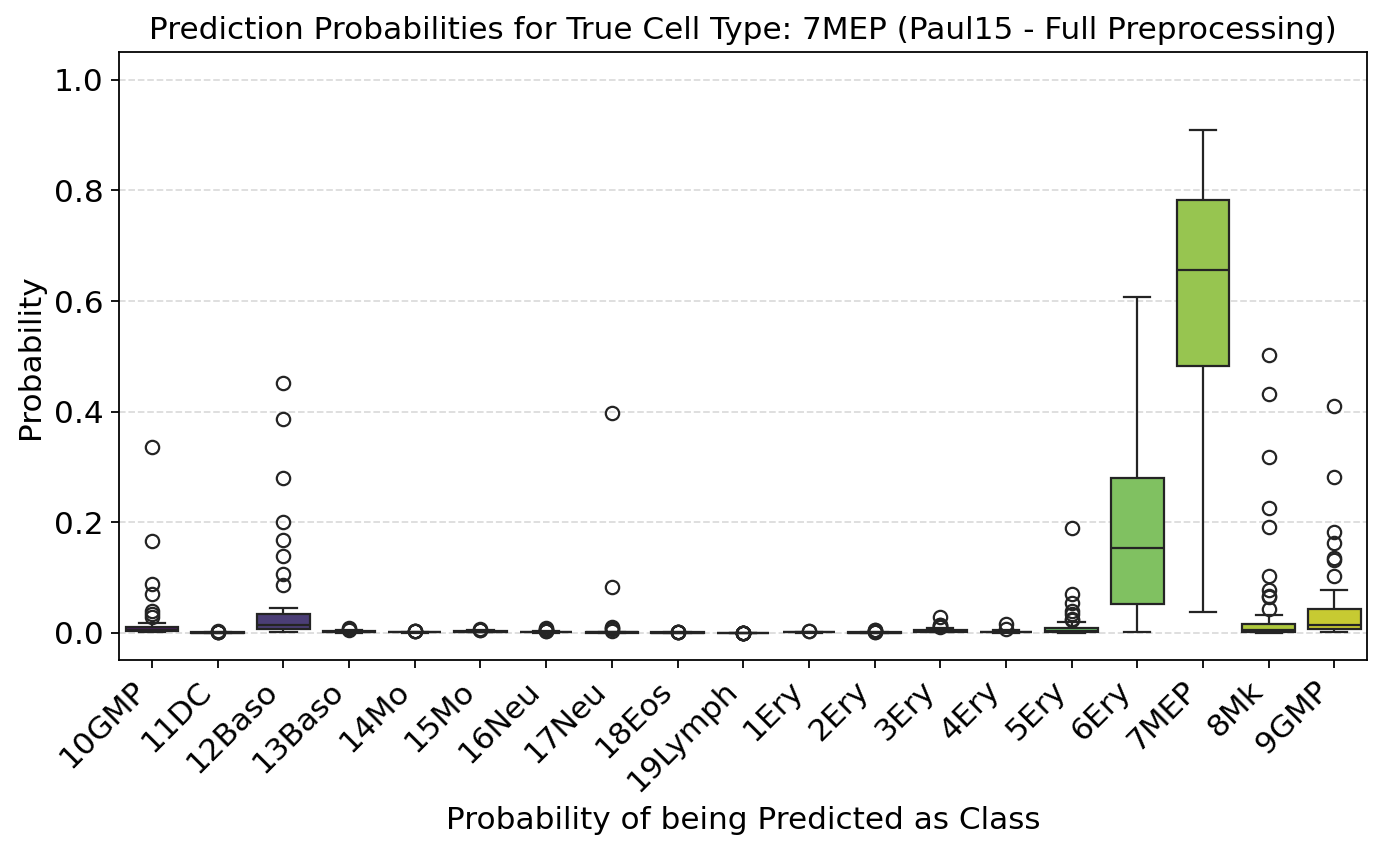

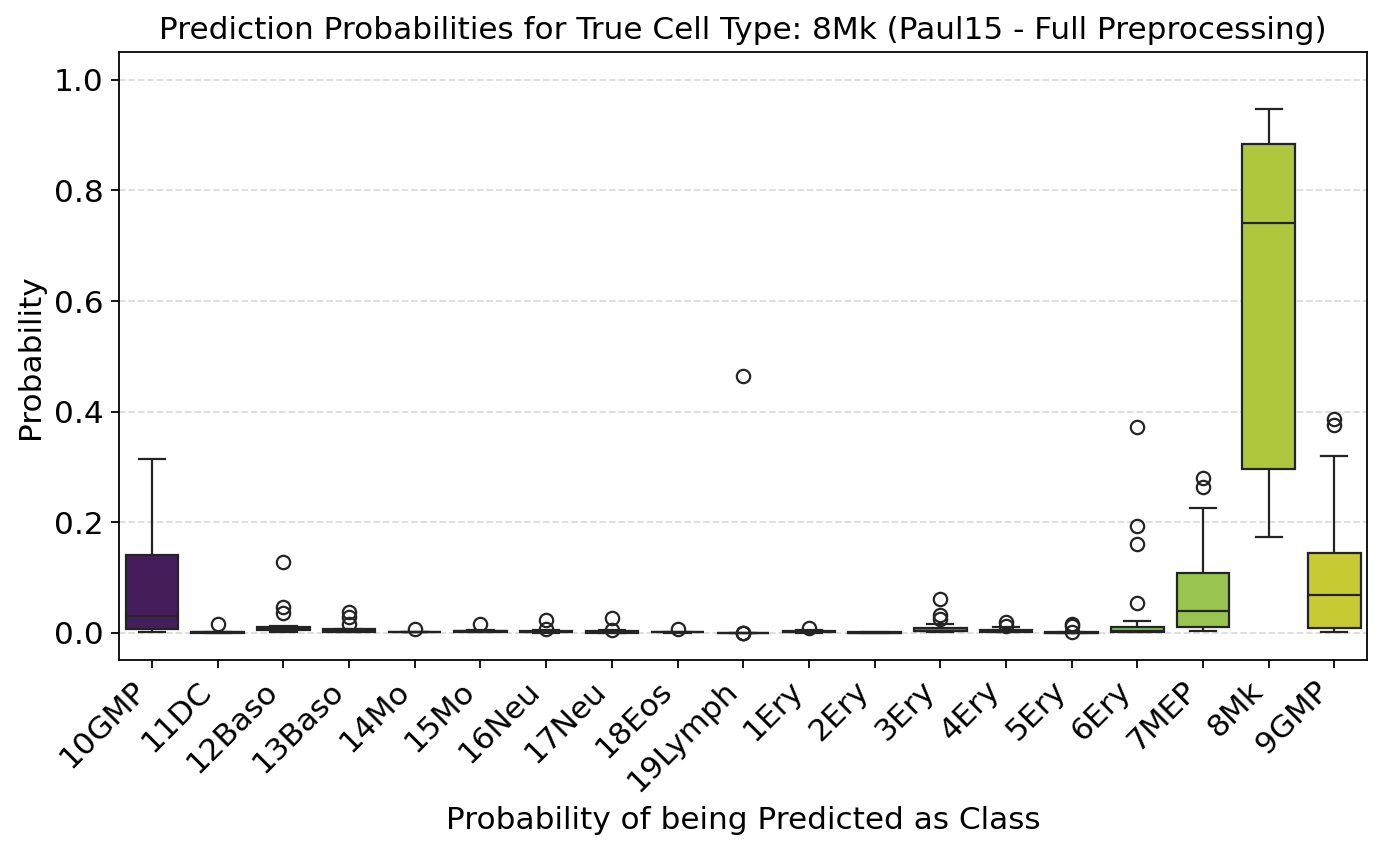

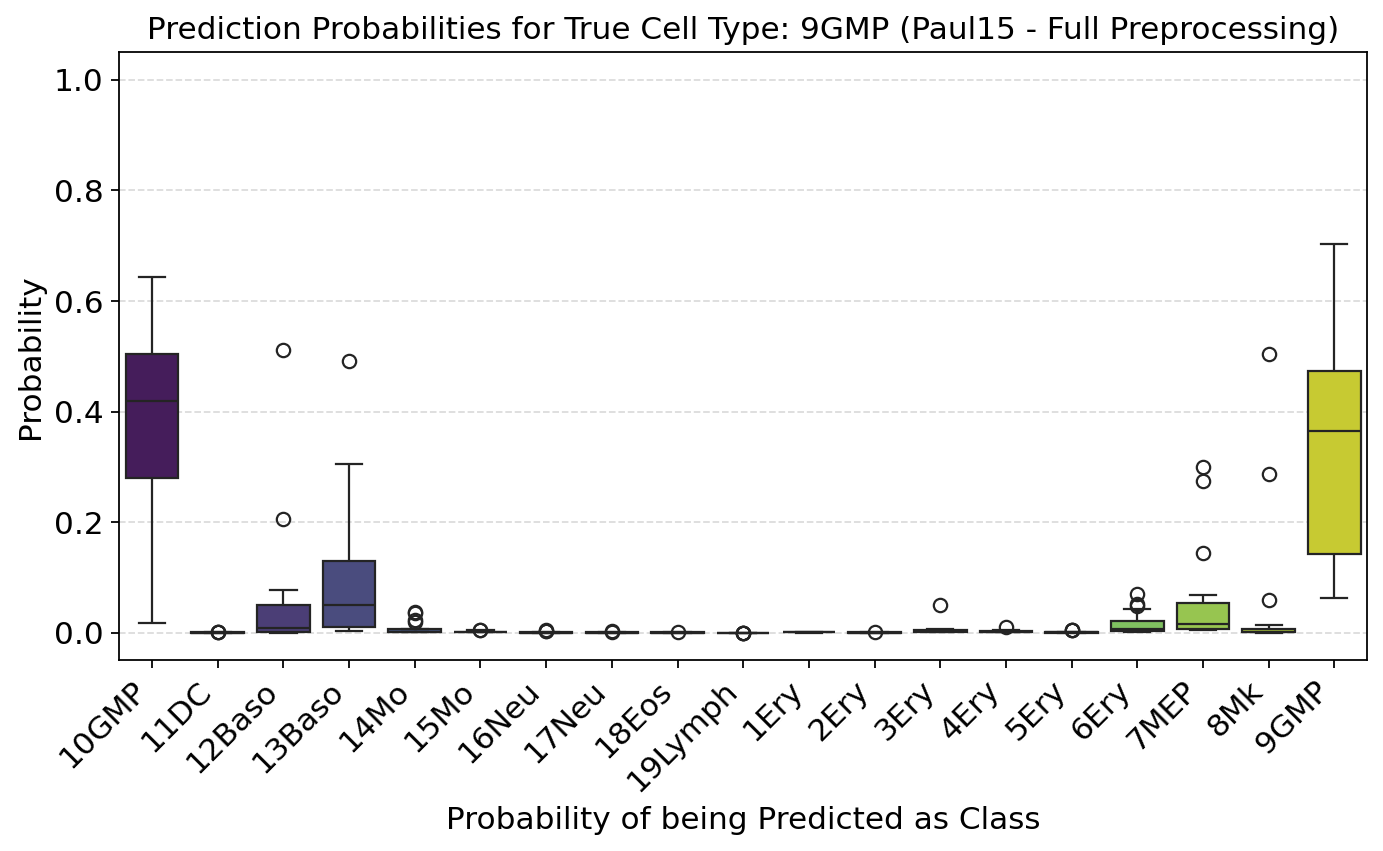


--- UMAP: True vs Predicted Labels (Paul15 - Full Preprocessing) ---


/tmp/ipykernel_1752/1843678817.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_full.tight_layout(rect=[0, 0.03, 1, 0.98])


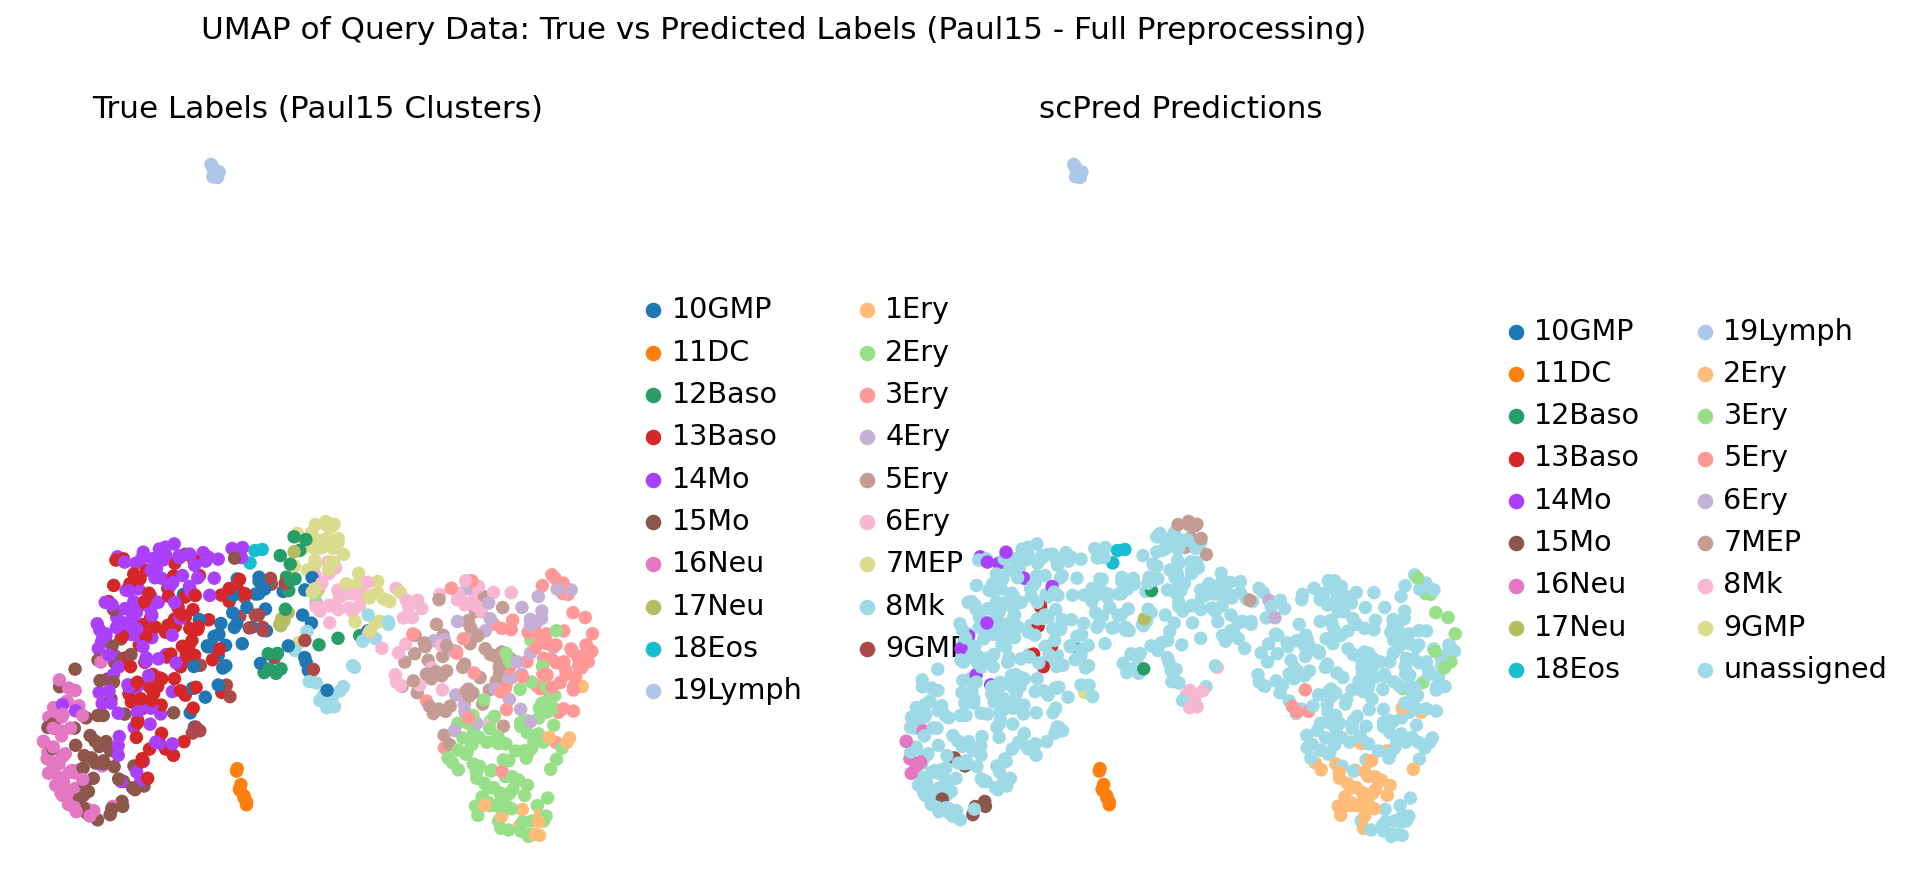


--- UMAP: Misclassified Cells (Paul15 - Full Preprocessing) ---


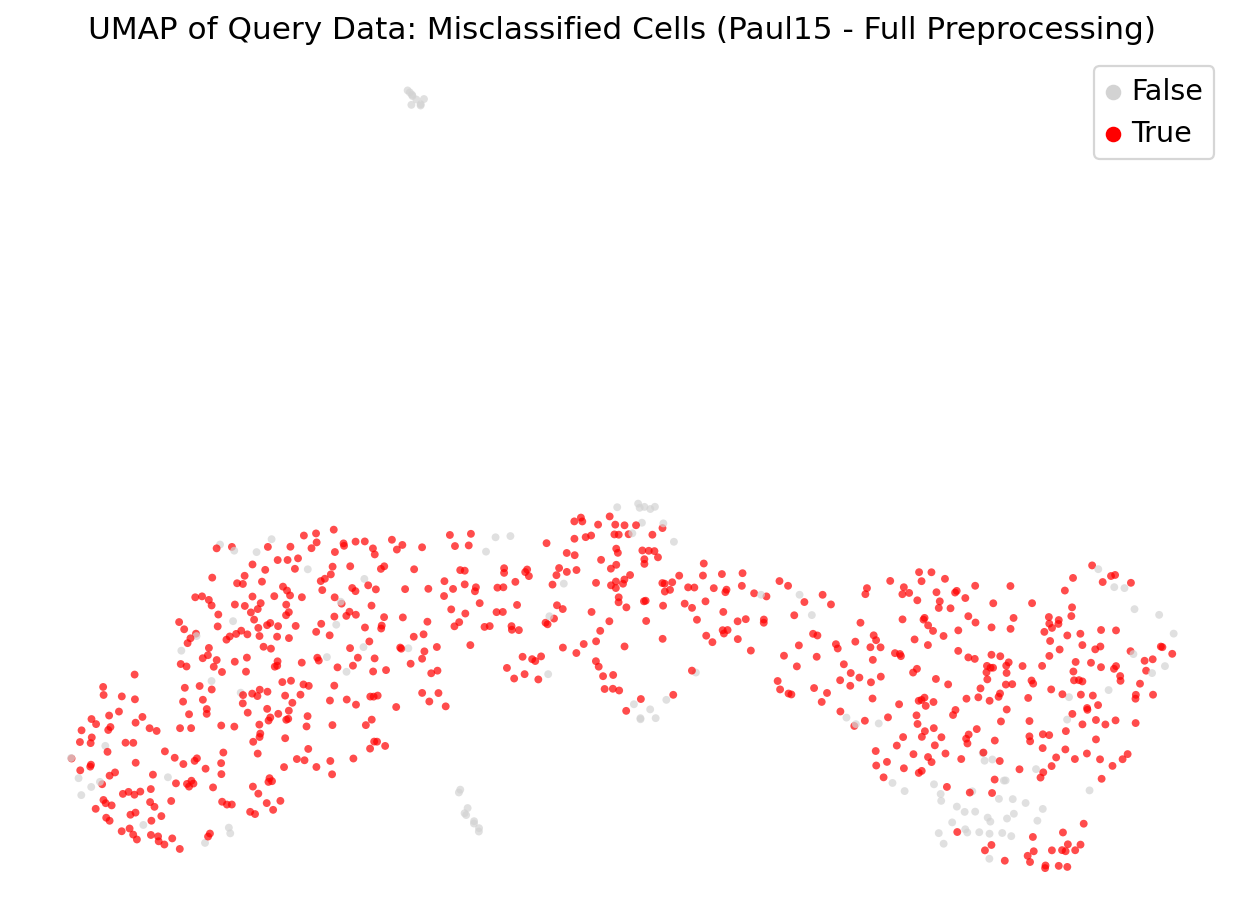


--- UMAP: Prediction Confidence (Paul15 - Full Preprocessing) ---


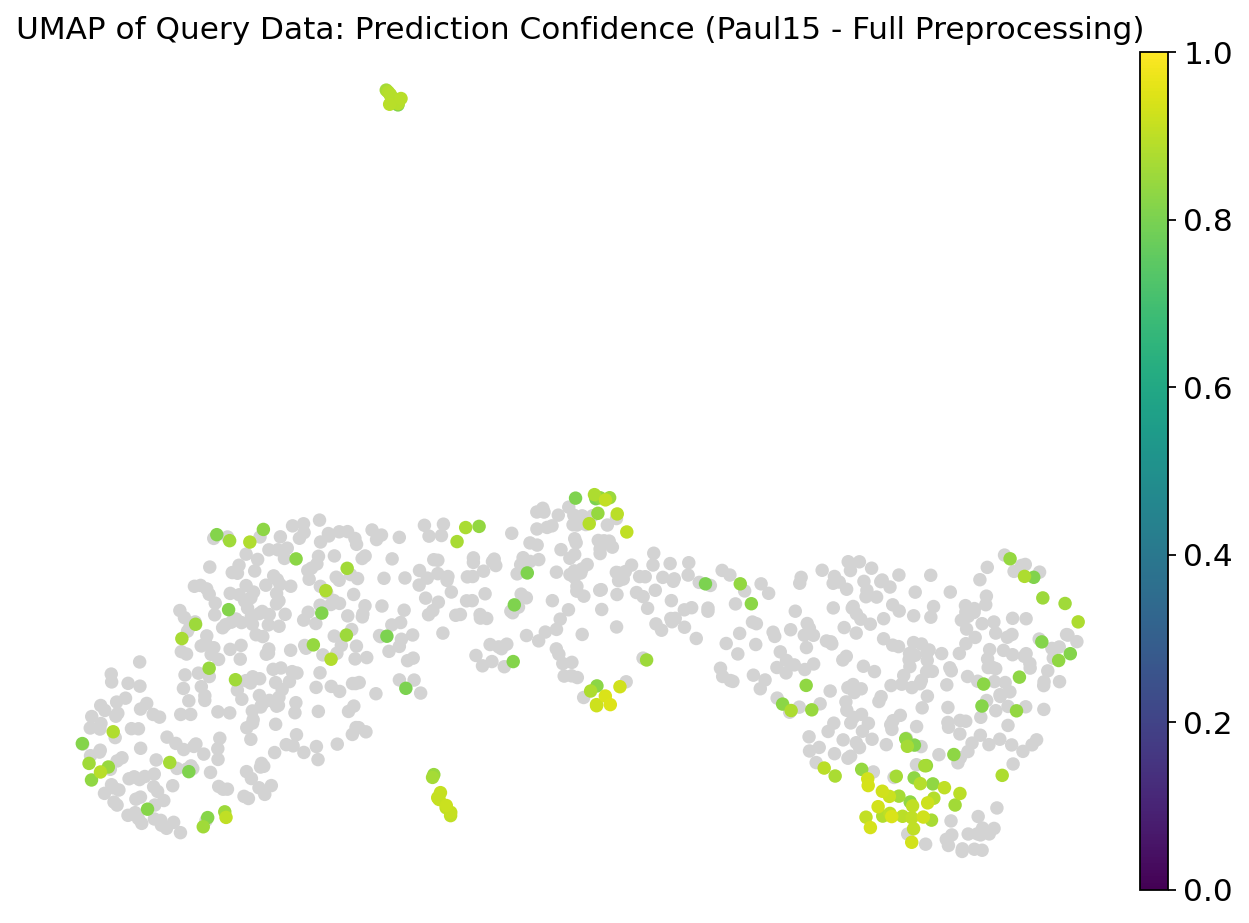


======== DEMONSTRATION 2: scPredModel (perform_preprocessing=False) ========

--- Manually Preprocessing Data for perform_preprocessing=False ---
  Manual normalization and log1p finished for reference and query.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
  Manually selected 2000 HVGs for reference.
  Manually aligned query data shape: (819, 2000)
Manually preprocessed reference data (Manual Preprocessing) saved to: ../data/preprocessed/paul15_ref_preprocessed_manual.h5ad

--- Step 3b: Training scPred Model (perform_preprocessing=False) ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 474 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardS

/tmp/ipykernel_1752/1843678817.py:496: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_partial.tight_layout(rect=[0, 0.03, 1, 0.98])


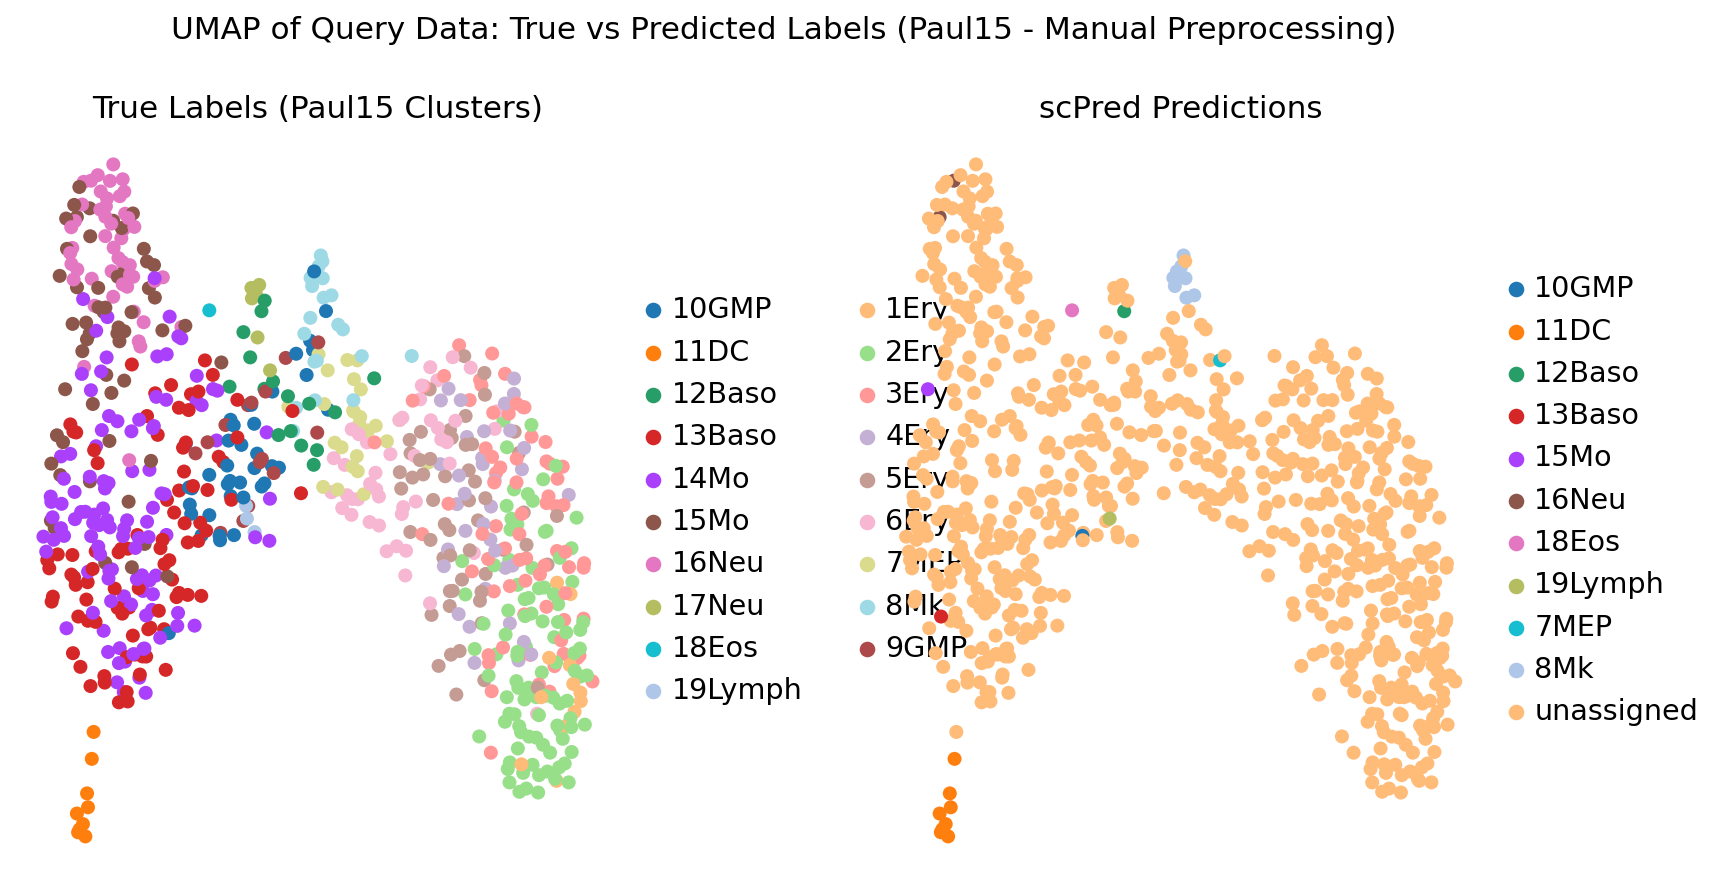


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( # Re-import these for direct use in notebook for plots/confusion matrix
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer # ADDED: Import LabelBinarizer for ROC plotting

# Adjust the path to import your scpred_py_revised package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_revised as per context
from scpred_py_final import _analysis_utils
from scpred_py_final import _preprocessing # Explicitly import for manual preprocessing steps


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation (for Paul15 dataset) ---
print("\n--- Step 1: Loading and Annotating Data (Paul15) ---")
# Load the Paul15 dataset from Scanpy
# This dataset is typically already normalized and log-transformed by Scanpy's datasets,
# but it usually does NOT have the 'log1p' flag in adata.uns, which our safety net checks.
adata_raw_paul15 = sc.datasets.paul15()
adata_raw_paul15.var_names_make_unique() # Ensure gene names are unique

print(f"Initial raw AnnData object shape (Paul15): {adata_raw_paul15.shape}")
print(f"Initial raw AnnData .obs keys: {adata_raw_paul15.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata_raw_paul15.var.keys().tolist()}\n")
print(f"Initial raw AnnData .uns keys: {list(adata_raw_paul15.uns.keys())}\n") # Check uns for log1p flag

# For the Paul15 dataset, the cell type labels are already available in .obs['paul15_clusters']
# We will use this directly as our 'cell_type' key for scPred.
# Convert to string category for consistent handling by metrics and plotting functions
adata_raw_paul15.obs['cell_type'] = adata_raw_paul15.obs['paul15_clusters'].astype(str).astype('category')

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata_raw_paul15.shape}")
print(f"Full dataset .obs keys after labeling: {adata_raw_paul15.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata_raw_paul15.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata_raw_paul15.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata_raw_paul15.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw_split = adata_raw_paul15[ref_idx, :].copy()
query_adata_raw_split = adata_raw_paul15[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw_split.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw_split.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw_split.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw_split.obs['cell_type'].value_counts())

# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw_split.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw_split.obs['cell_type'].value_counts(normalize=True).sort_index())


# ==============================================================================
# DEMONSTRATION 1: scPredModel with perform_preprocessing=True (Default)
# ==============================================================================
print("\n======== DEMONSTRATION 1: scPredModel (perform_preprocessing=True) ========")

# --- 3a. Training the scPred Model (Full Preprocessing) ---
print("\n--- Step 3a: Training scPred Model (perform_preprocessing=True) ---")
scpred_model_full = ScPredModel()

# Applying optimal parameters from comparative analysis: RBF, C=1.0, Balanced, 2000 HVGs
scpred_model_full.train(
    ref_adata=ref_adata_raw_split, # Pass the raw reference data
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=2000, # Optimal from comparative analysis
    hvg_flavor='seurat',
    svm_kernel='rbf',     # Optimal from comparative analysis
    svm_c=1.0,            # Optimal from comparative analysis
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight='balanced' # Optimal from comparative analysis
)

print("\nModel Trained (Full Preprocessing)!")
print(f"Scaler: {scpred_model_full.scaler_}")
print(f"PCA Model: {scpred_model_full.pca_model_}")
print(f"Classifier: {scpred_model_full.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model_full.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object using its new method
model_full_path = os.path.join(MODELS_DIR, 'scpred_model_paul15_full_preprocessing.pkl')
scpred_model_full.save(model_full_path)

# Save the preprocessed reference data for scenario 1
if hasattr(scpred_model_full, 'ref_adata_processed_') and scpred_model_full.ref_adata_processed_ is not None:
    preprocessed_ref_full_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_ref_preprocessed_full.h5ad')
    scpred_model_full.ref_adata_processed_.write(preprocessed_ref_full_path)
    print(f"Preprocessed reference data (Full Preprocessing) saved to: {preprocessed_ref_full_path}")
else:
    print("Warning: scpred_model_full.ref_adata_processed_ is not accessible. Preprocessed reference data not saved for Demo 1.")


# --- 4a. Predicting with the scPred Model (Full Preprocessing) ---
print("\n--- Step 4a: Predicting on Query Data (perform_preprocessing=True) ---")
PREDICTION_THRESHOLD = 0.8 # Consistent with comparative analysis
query_adata_pred_full = scpred_model_full.predict(query_adata_raw_split, threshold=PREDICTION_THRESHOLD)

print("\nQuery Data with Predictions (Full Preprocessing, first 5 rows):")
print(query_adata_pred_full.obs[['cell_type', 'scpred_prediction']].head())

# Save the preprocessed query data with predictions for scenario 1
preprocessed_query_full_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_query_pred_preprocessed_full.h5ad')
query_adata_pred_full.write(preprocessed_query_full_path)
print(f"Preprocessed query data with predictions (Full Preprocessing) saved to: {preprocessed_query_full_path}")


# --- 5a. Evaluating Predictions (Full Preprocessing) ---
# FIX: Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_full = query_adata_pred_full.obs['scpred_prediction'].notna()
true_labels_full = query_adata_pred_full.obs.loc[valid_cells_full, 'cell_type']
predicted_labels_full = query_adata_pred_full.obs.loc[valid_cells_full, 'scpred_prediction']

pred_prob_cols_full = [col for col in query_adata_pred_full.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_full = None
if len(pred_prob_cols_full) > 0:
    y_pred_probs_df_full = query_adata_pred_full.obs.loc[valid_cells_full, pred_prob_cols_full].copy()
    # Fill any remaining NaNs in probabilities with 0 (should ideally not happen if filtering by notna 'scpred_prediction')
    y_pred_probs_df_full = y_pred_probs_df_full.fillna(0.0)


print("\n--- Evaluation for Full Preprocessing Model ---")
metrics_results_full = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_full,
    predicted_labels=predicted_labels_full,
    classifier_classes=scpred_model_full.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_full
)


# --- 6a. Visualizing Results (Full Preprocessing) ---
print("\n--- Step 6a: Visualizing Results (Full Preprocessing) ---")

# For UMAP plots, we need the AnnData object to be filtered to only valid cells or handle NaNs in plots.
# It's safer to create a temporary filtered AnnData for plotting to avoid issues with NaN coordinates.
query_adata_pred_full_filtered_for_umap = query_adata_pred_full[valid_cells_full, :].copy()

# FIX: Remove potentially stale 'iroot' and 'neighbors' graph info from .uns of the subsetted AnnData
# This helps prevent warnings like "Root cell index X does not exist..."
if 'iroot' in query_adata_pred_full_filtered_for_umap.uns:
    del query_adata_pred_full_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_full_filtered_for_umap.uns:
    del query_adata_pred_full_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_full_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_full_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_full_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE) # Added random_state
    sc.tl.umap(query_adata_pred_full_filtered_for_umap, random_state=RANDOM_STATE) # Added random_state
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_full_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_full_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

# Plot 1: Confusion Matrix
print("\n--- Confusion Matrix (Full Preprocessing) ---")
true_labels_str_full = true_labels_full.astype(str) # Use already filtered labels
predicted_labels_str_full = predicted_labels_full.astype(str) # Use already filtered labels
cm_labels_str_full = sorted(true_labels_str_full.unique().tolist())
cm_full = confusion_matrix(true_labels_str_full, predicted_labels_str_full, labels=cm_labels_str_full)
cm_df_full = pd.DataFrame(cm_full, index=cm_labels_str_full, columns=cm_labels_str_full)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_full, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (Paul15 - Full Preprocessing)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot 2: Per-Class ROC AUC (Full Preprocessing)
print("\n--- Per-Class ROC AUC (Paul15 - Full Preprocessing) ---")
if hasattr(scpred_model_full.classifier_, 'predict_proba'):
    classes_full = scpred_model_full.classifier_.classes_
    y_true_binary_full = pd.get_dummies(true_labels_str_full, columns=classes_full, drop_first=False).values
    y_scores_full = y_pred_probs_df_full[[f"scpred_prob_{c}" for c in classes_full]].values

    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes_full):
        if y_true_binary_full.shape[1] > i and len(np.unique(y_true_binary_full[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true_binary_full[:, i], y_scores_full[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels.")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve (Paul15 - Full Preprocessing)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Plot 3: Distribution of Prediction Probabilities (Full Preprocessing)
print("\n--- Distribution of Prediction Probabilities (Paul15 - Full Preprocessing) ---")
if hasattr(scpred_model_full.classifier_, 'predict_proba'):
    prob_df_full = query_adata_pred_full_filtered_for_umap.obs[[f"scpred_prob_{c}" for c in scpred_model_full.classifier_.classes_]].copy()
    prob_df_full['true_cell_type'] = query_adata_pred_full_filtered_for_umap.obs['cell_type'].astype(str)
    prob_melted_full = prob_df_full.melt(
        id_vars='true_cell_type',
        value_vars=[f"scpred_prob_{c}" for c in scpred_model_full.classifier_.classes_],
        var_name='predicted_class_prob_of',
        value_name='probability'
    )
    prob_melted_full['predicted_class_prob_of'] = prob_melted_full['predicted_class_prob_of'].str.replace('scpred_prob_', '')
    for true_type in sorted(prob_melted_full['true_cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted_full[prob_melted_full['true_cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='predicted_class_prob_of', y='probability', hue='predicted_class_prob_of', palette='viridis', legend=False)
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} (Paul15 - Full Preprocessing)')
        plt.xlabel('Probability of being Predicted as Class')
        plt.ylabel('Probability')
        plt.ylim(-0.05, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45, ha='right') # FIX: Rotate x-axis labels
        plt.show()

# UMAP plots (Full Preprocessing)
if 'X_umap' in query_adata_pred_full_filtered_for_umap.obsm: # Use filtered adata for UMAP
    print("\n--- UMAP: True vs Predicted Labels (Paul15 - Full Preprocessing) ---")
    
    # sc.pl.umap with color as a list returns a list of Axes objects when show=False.
    # We need to get the figure from one of these axes.
    axes_list_full = sc.pl.umap(
        query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Paul15 Clusters)', 'scPred Predictions'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    # Get the figure from the first axis in the list
    fig_full = axes_list_full[0].figure
    fig_full.set_size_inches(12, 6) # Set the figure size after creation by scanpy
    fig_full.suptitle('UMAP of Query Data: True vs Predicted Labels (Paul15 - Full Preprocessing)', y=1.02, fontsize=14)
    fig_full.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("\n--- UMAP: Misclassified Cells (Paul15 - Full Preprocessing) ---")
    # true_labels_str_full and predicted_labels_str_full are already filtered
    query_adata_pred_full_filtered_for_umap.obs['misclassified'] = (true_labels_str_full != predicted_labels_str_full).astype(str).astype('category')
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    # FIX: Explicitly create figure and axes
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
        color='misclassified', palette=misclassified_palette, size=50, alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells (Paul15 - Full Preprocessing)',
        frameon=False, show=False, legend_loc='upper right', # Fixed legend_loc
        ax=ax # Pass the single axis
    )
    fig.tight_layout() # Apply tight_layout to the figure
    plt.show()

    print("\n--- UMAP: Prediction Confidence (Paul15 - Full Preprocessing) ---")
    if hasattr(scpred_model_full.classifier_, 'predict_proba'):
        def get_predicted_prob(row, classes):
            pred_class = row['scpred_prediction']
            # Handle 'unassigned' cells for confidence plot
            if pred_class == 'unassigned' or pd.isna(pred_class):
                return np.nan # Or 0.0, depending on desired visualization of unassigned
            prob_col_name = f'scpred_prob_{pred_class}'
            if prob_col_name in row.index:
                return row[prob_col_name]
            return np.nan
        prob_cols_full_model = [col for col in query_adata_pred_full_filtered_for_umap.obs.columns if col.startswith('scpred_prob_')] # Filter cols based on filtered adata
        if all(col in query_adata_pred_full_filtered_for_umap.obs.columns for col in prob_cols_full_model): # Check against filtered adata
            temp_obs_for_apply_full = query_adata_pred_full_filtered_for_umap.obs[['scpred_prediction'] + prob_cols_full_model]
            query_adata_pred_full_filtered_for_umap.obs['predicted_prob_score'] = temp_obs_for_apply_full.apply(
                lambda row: get_predicted_prob(row, scpred_model_full.classifier_.classes_), axis=1
            )
            # FIX: Explicitly create figure and axes
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            sc.pl.umap(
                query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
                color='predicted_prob_score', cmap='viridis',
                title='UMAP of Query Data: Prediction Confidence (Paul15 - Full Preprocessing)',
                frameon=False, vmin=0.0, vmax=1.0, show=False,
                ax=ax # Pass the single axis
            )
            fig.tight_layout() # Apply tight_layout to the figure
            plt.show()
    else:
        print("Skipping UMAP by prediction confidence: Classifier does not support `predict_proba`.")
else:
    print("Skipping UMAP plots as 'X_umap' is not available in .obsm.")


# ==============================================================================
# DEMONSTRATION 2: scPredModel with perform_preprocessing=False
# User explicitly preprocesses data before passing to model.
# This will *avoid* the redundant log1p application.
# ==============================================================================
print("\n======== DEMONSTRATION 2: scPredModel (perform_preprocessing=False) ========")

# --- Preprocessing Data MANUALLY for perform_preprocessing=False mode ---
print("\n--- Manually Preprocessing Data for perform_preprocessing=False ---")
# Create copies to avoid modifying original raw splits
ref_adata_manual_prep = ref_adata_raw_split.copy()
query_adata_manual_prep = query_adata_raw_split.copy()

# Step 1: Normalize and Log1p (Manually)
sc.pp.normalize_total(ref_adata_manual_prep, target_sum=1e4)
sc.pp.log1p(ref_adata_manual_prep)
# IMPORTANT: Manually set the 'log1p' flag in adata.uns to inform downstream tools
ref_adata_manual_prep.uns['log1p'] = {'base': None} # Indicate it's log-transformed

sc.pp.normalize_total(query_adata_manual_prep, target_sum=1e4)
sc.pp.log1p(query_adata_manual_prep)
query_adata_manual_prep.uns['log1p'] = {'base': None}

print("  Manual normalization and log1p finished for reference and query.")

# Step 2: Highly Variable Genes selection (on reference)
# For simplicity, we'll apply it after log1p here to get HVGs on the manually processed data.
ref_adata_manual_prep, ref_hvg_genes_manual = _preprocessing.select_highly_variable_genes(
    ref_adata_manual_prep, n_top_genes=2000, flavor='seurat' # Added flavor and n_top_genes
)
print(f"  Manually selected {ref_adata_manual_prep.shape[1]} HVGs for reference.")


# Step 3: Align query genes to reference HVGs
# The _preprocessing.align_genes_to_reference function will handle this.
# This aligns the genes in query_adata_manual_prep to the common HVGs found in reference.
query_expr_df_manual = pd.DataFrame(
    query_adata_manual_prep.X.toarray() if hasattr(query_adata_manual_prep.X, 'toarray') else query_adata_manual_prep.X,
    index=query_adata_manual_prep.obs_names,
    columns=query_adata_manual_prep.var_names
)
aligned_query_expr_df_manual = query_expr_df_manual.reindex(columns=ref_hvg_genes_manual, fill_value=0.0)

aligned_query_manual_prep = ad.AnnData(
    X=aligned_query_expr_df_manual.values,
    obs=query_adata_manual_prep.obs.loc[aligned_query_expr_df_manual.index],
    var=pd.DataFrame(index=aligned_query_expr_df_manual.columns)
)
print(f"  Manually aligned query data shape: {aligned_query_manual_prep.shape}")

# Save the manually preprocessed reference data for scenario 2
preprocessed_ref_manual_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_ref_preprocessed_manual.h5ad')
ref_adata_manual_prep.write(preprocessed_ref_manual_path)
print(f"Manually preprocessed reference data (Manual Preprocessing) saved to: {preprocessed_ref_manual_path}")


# --- 3b. Training the scPred Model (perform_preprocessing=False) ---
print("\n--- Step 3b: Training scPred Model (perform_preprocessing=False) ---")
scpred_model_partial = ScPredModel()

# Pass the manually preprocessed data (normalized, log1p, HVG-selected)
# Model will then only perform scaling and PCA internally.
# Applying optimal parameters from comparative analysis: RBF, C=1.0, Balanced, 2000 HVGs
scpred_model_partial.train(
    ref_adata=ref_adata_manual_prep, # Pass the manually preprocessed data
    cell_type_key='cell_type',
    n_components=30, # Same as before
    # hvg parameters are now ignored by ScPredModel's train when perform_preprocessing=False
    svm_kernel='rbf',     # Optimal from comparative analysis
    svm_c=1.0,            # Optimal from comparative analysis
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight='balanced' # Optimal from comparative analysis
)

print("\nModel Trained (Manual Preprocessing)! (Optimal Parameters Applied)")
print(f"Scaler: {scpred_model_partial.scaler_}")
print(f"PCA Model: {scpred_model_partial.pca_model_}")
print(f"Classifier: {scpred_model_partial.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model_partial.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object for scenario 2
model_partial_path = os.path.join(MODELS_DIR, 'scpred_model_paul15_manual_preprocessing.pkl')
scpred_model_partial.save(model_partial_path)


# --- 4b. Predicting with the scPred Model (perform_preprocessing=False) ---
print("\n--- Step 4b: Predicting on Query Data (perform_preprocessing=False) ---")
# Pass the manually preprocessed query data (normalized, log1p, aligned to reference HVGs)
query_adata_pred_partial = scpred_model_partial.predict(aligned_query_manual_prep, threshold=PREDICTION_THRESHOLD)

print("\nQuery Data with Predictions (Manual Preprocessing, first 5 rows):")
print(query_adata_pred_partial.obs[['cell_type', 'scpred_prediction']].head())

# Save the preprocessed query data with predictions for scenario 2
preprocessed_query_manual_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_query_pred_preprocessed_manual.h5ad')
query_adata_pred_partial.write(preprocessed_query_manual_path)
print(f"Manually preprocessed query data with predictions (Manual Preprocessing) saved to: {preprocessed_query_manual_path}")


# --- 5b. Evaluating Predictions (Manual Preprocessing) ---
# FIX: Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_partial = query_adata_pred_partial.obs['scpred_prediction'].notna()
true_labels_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, 'cell_type']
predicted_labels_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, 'scpred_prediction']

pred_prob_cols_partial = [col for col in query_adata_pred_partial.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_partial = None
if len(pred_prob_cols_partial) > 0:
    y_pred_probs_df_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, pred_prob_cols_partial].copy()
    # Fill any remaining NaNs in probabilities with 0
    y_pred_probs_df_partial = y_pred_probs_df_partial.fillna(0.0)


print("\n--- Evaluation for Manual Preprocessing Model ---")
metrics_results_partial = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_partial,
    predicted_labels=predicted_labels_partial,
    classifier_classes=scpred_model_partial.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_partial
)

# --- 6b. Visualizing Results (Manual Preprocessing) ---
# For brevity, we'll only compute UMAP for this run and assume similar plots.
# You can copy/paste/adapt plotting code from 6a here if you want to see all plots for this mode.
print("\n--- Step 6b: Visualizing Results (Manual Preprocessing) ---")

# Create a temporary filtered AnnData for plotting for scenario 2
query_adata_pred_partial_filtered_for_umap = query_adata_pred_partial[valid_cells_partial, :].copy()

# FIX: Remove potentially stale 'iroot' and 'neighbors' graph info from .uns of the subsetted AnnData
# This helps prevent warnings like "Root cell index X does not exist..."
if 'iroot' in query_adata_pred_partial_filtered_for_umap.uns:
    del query_adata_pred_partial_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_partial_filtered_for_umap.uns:
    del query_adata_pred_partial_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_partial_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_partial_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_partial_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE) # Added random_state
    sc.tl.umap(query_adata_pred_partial_filtered_for_umap, random_state=RANDOM_STATE) # Added random_state
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_partial_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_partial_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

if 'X_umap' in query_adata_pred_partial_filtered_for_umap.obsm:
    print("\n--- UMAP: True vs Predicted Labels (Paul15 - Manual Preprocessing) ---")
    # sc.pl.umap with color as a list returns a list of axes when show=False
    # We need to get the figure from one of these axes.
    axes_list_partial = sc.pl.umap(
        query_adata_pred_partial_filtered_for_umap, # Use filtered adata for UMAP
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Paul15 Clusters)', 'scPred Predictions'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    # Get the figure from the first axis in the list
    fig_partial = axes_list_partial[0].figure
    fig_partial.set_size_inches(12, 6) # Set the figure size after creation by scanpy
    fig_partial.suptitle('UMAP of Query Data: True vs Predicted Labels (Paul15 - Manual Preprocessing)', y=1.02, fontsize=14)
    fig_partial.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("Skipping UMAP: True vs Predicted Labels as 'X_umap' is not available in .obsm.")

print("\n--- Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating Data (Paul15) ---
Initial raw AnnData object shape (Paul15): (2730, 3451)
Initial raw AnnData .obs keys: ['paul15_clusters']
Initial raw AnnData .var keys: []

Initial raw AnnData .uns keys: ['iroot']

Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference d

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Overall Balanced Accuracy (excluding 'unassigned'): 0.8586
Matthews Correlation Coefficient (MCC) (excluding 'unassigned'): 0.9225

--- Full Classification Report ---
              precision    recall  f1-score   support

       10GMP       1.00      0.02      0.04        46
        11DC       1.00      1.00      1.00         9
      12Baso       1.00      0.10      0.17        21
      13Baso       1.00      0.06      0.11        90
        14Mo       1.00      0.10      0.18       112
        15Mo       0.71      0.09      0.16        56
       16Neu       1.00      0.12      0.22        49
       17Neu       1.00      0.17      0.29         6
       18Eos       1.00      1.00      1.00         3
     19Lymph       1.00      1.00      1.00         9
        1Ery       0.00      0.00      0.00        13
        2Ery       0.90      0.36      0.52        99
        3Ery       1.00      0.15      0.26        74
        4Ery       0.00      0.00      0.00        37
        5Ery       0.7

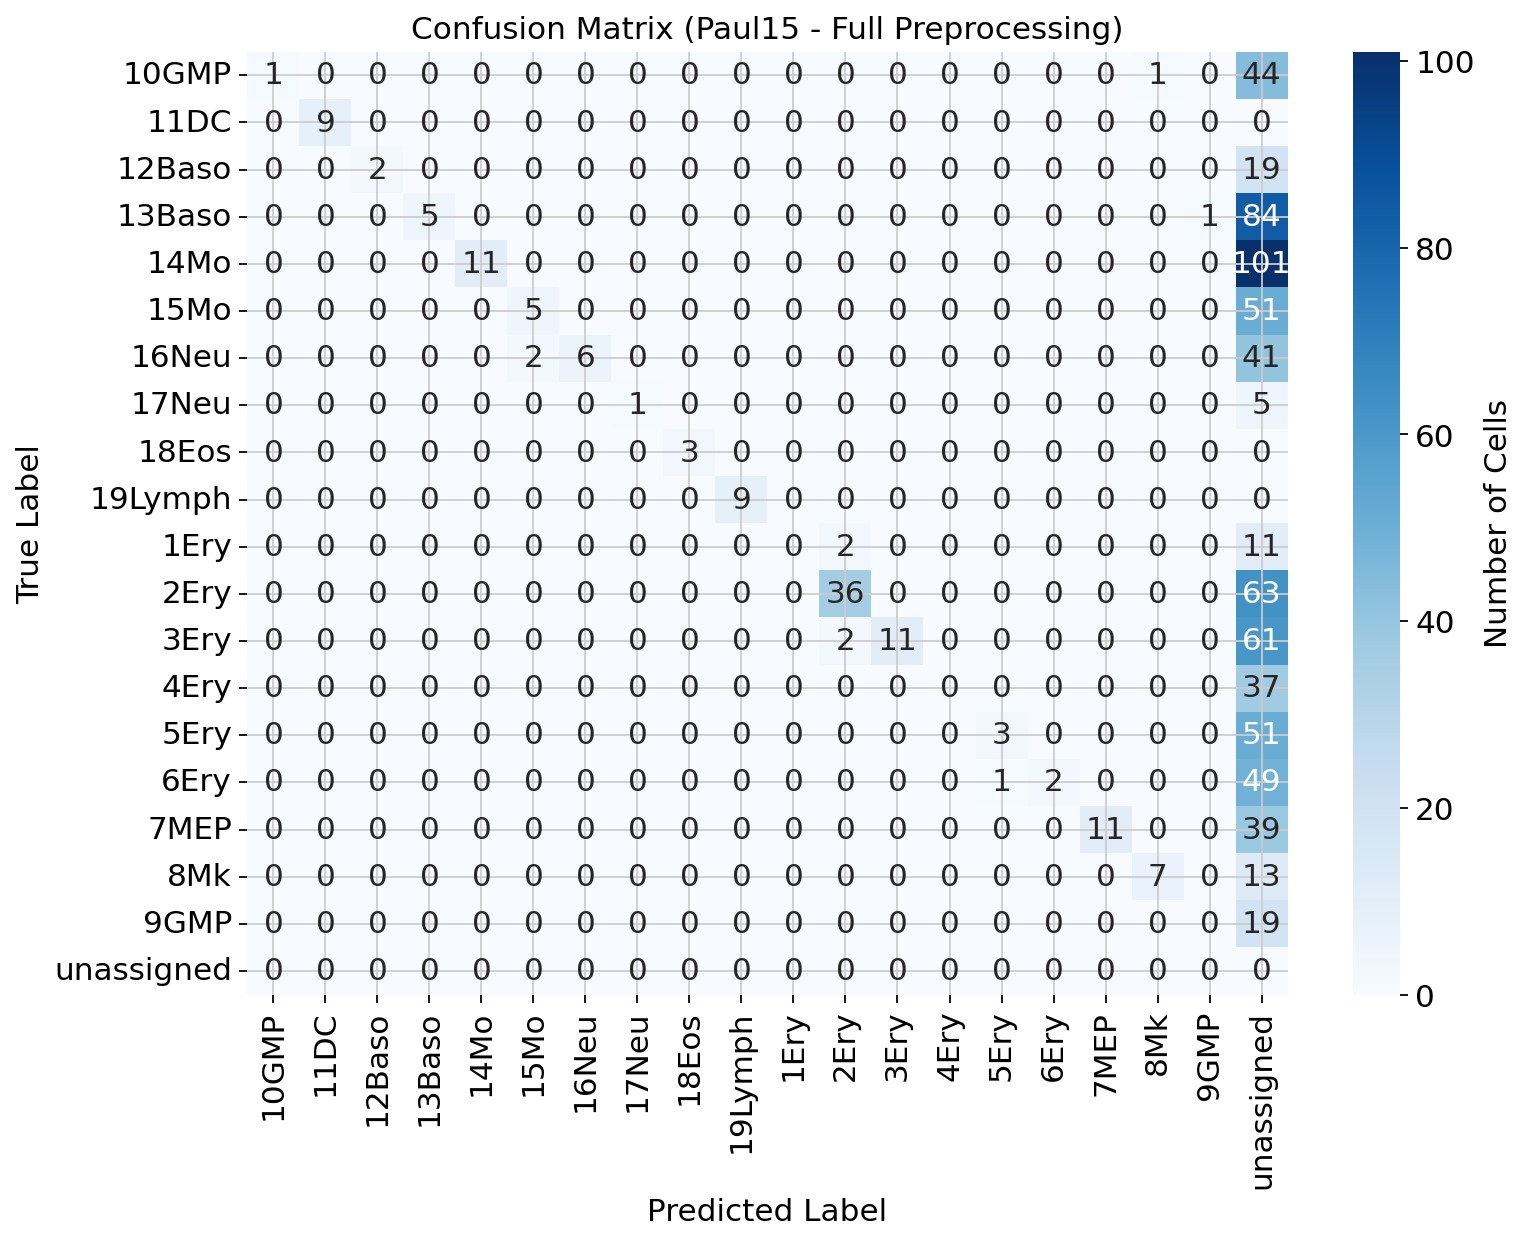


--- Per-Class ROC AUC (Paul15 - Full Preprocessing) ---


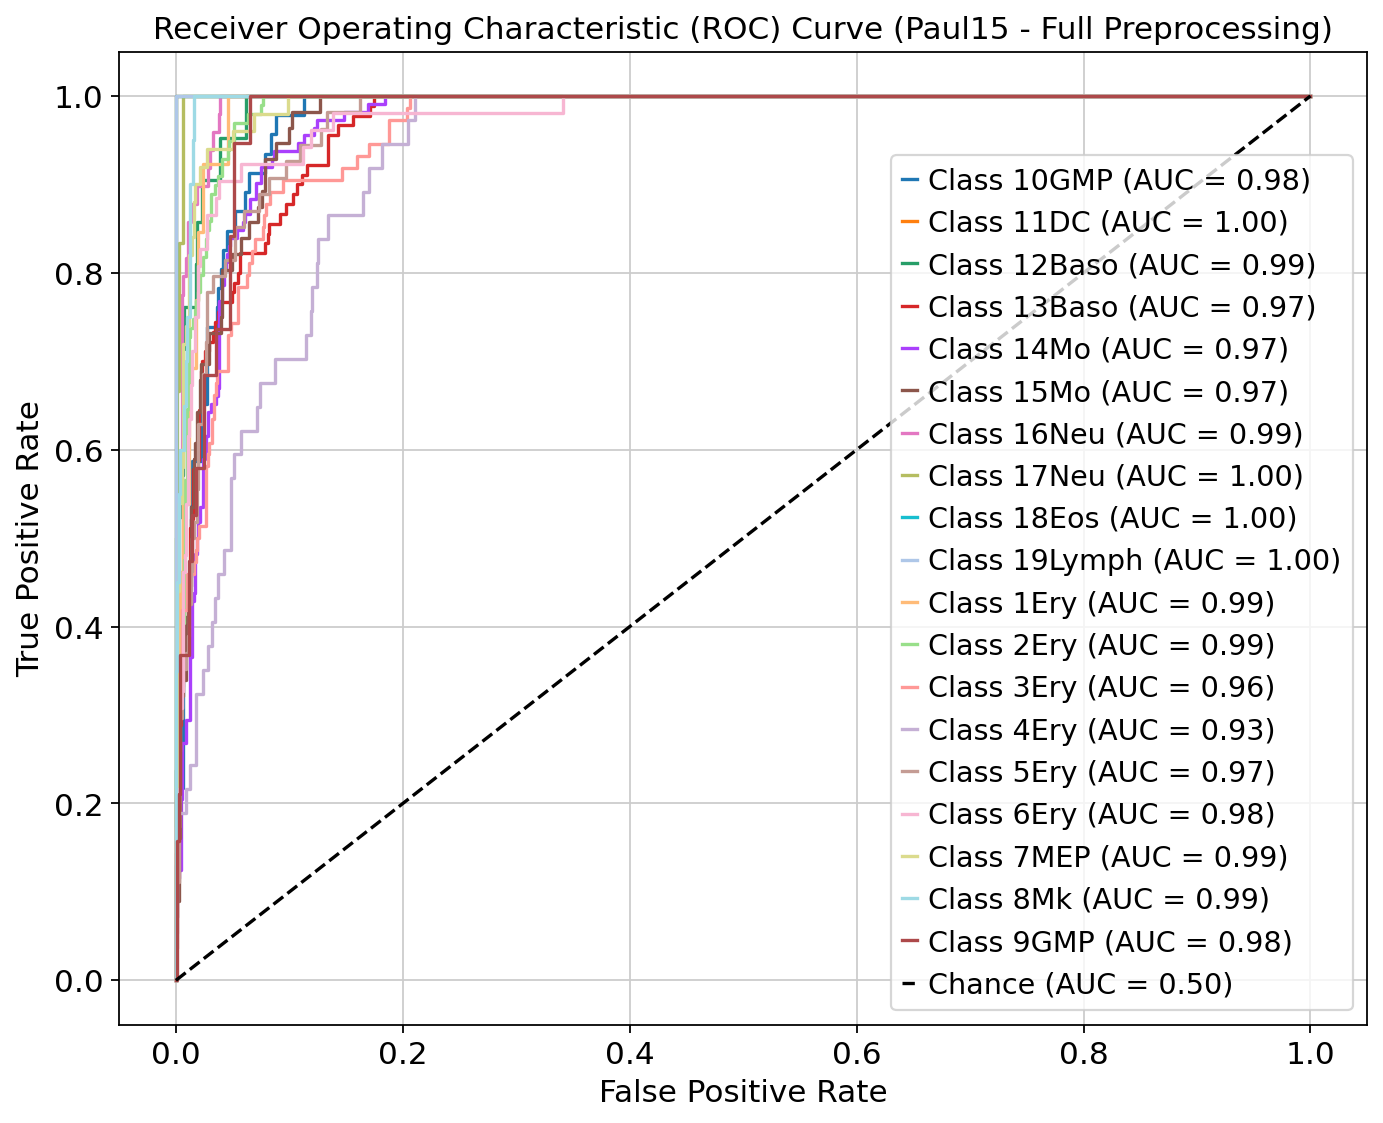


--- Distribution of Prediction Probabilities (Paul15 - Full Preprocessing) ---


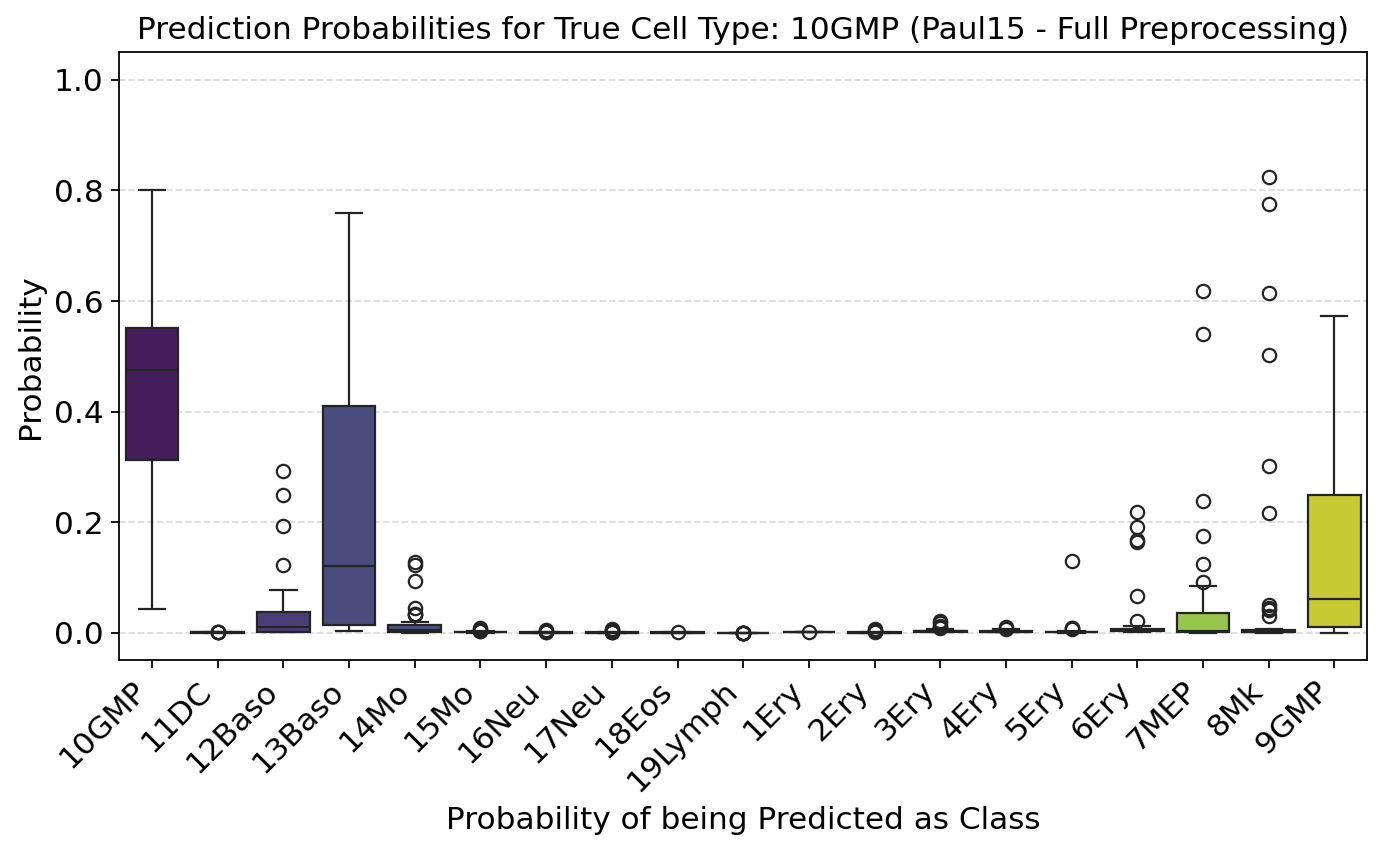

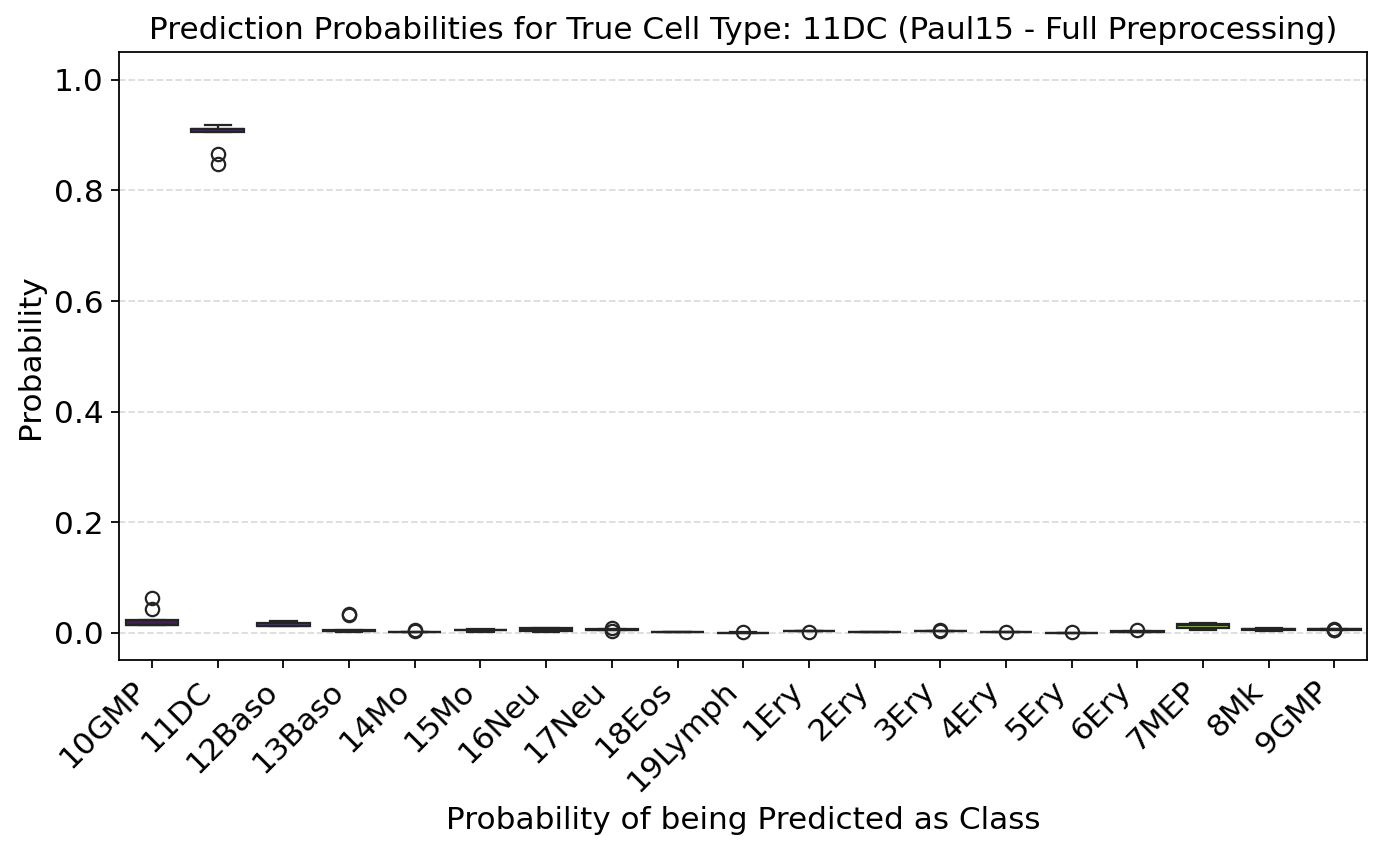

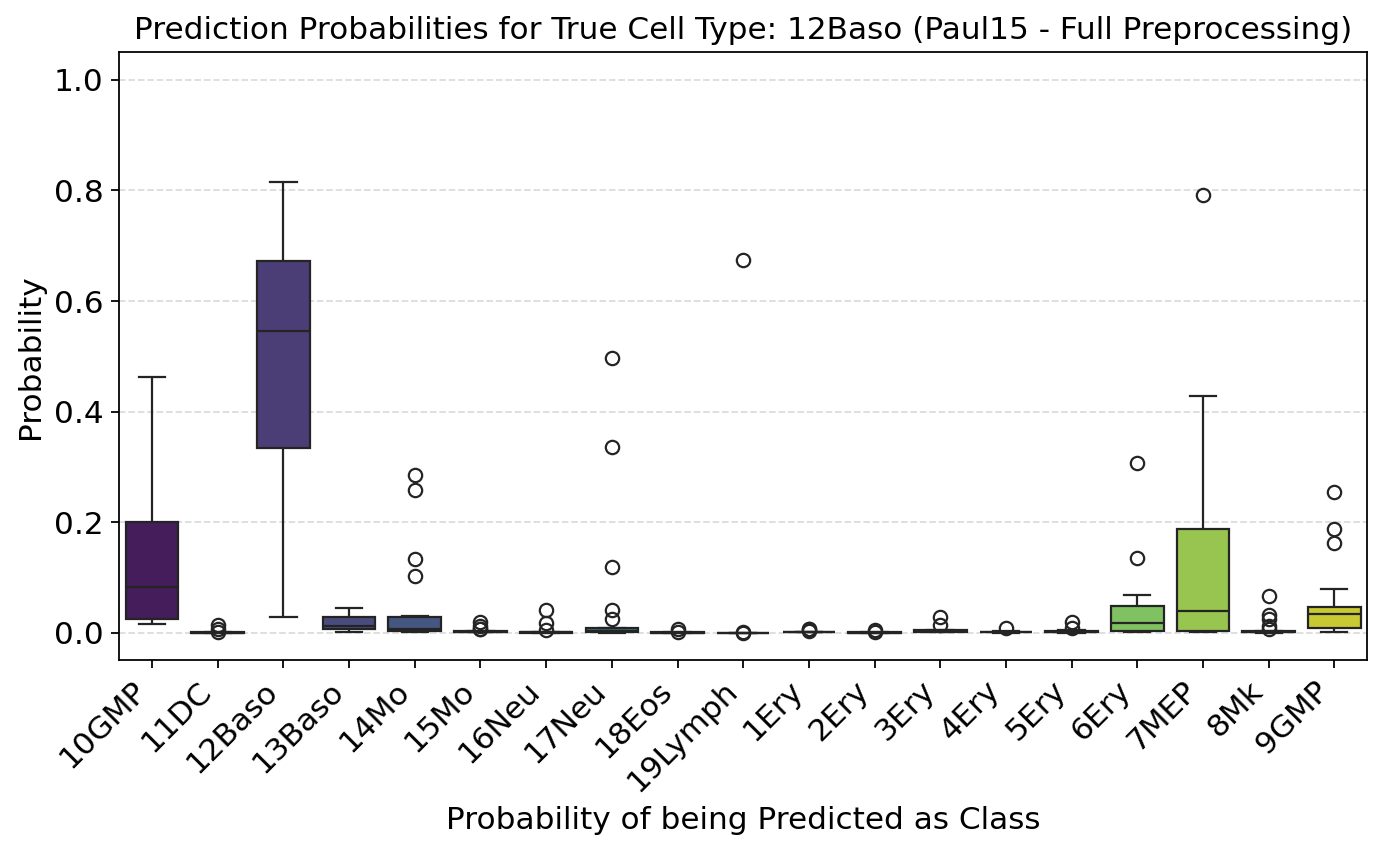

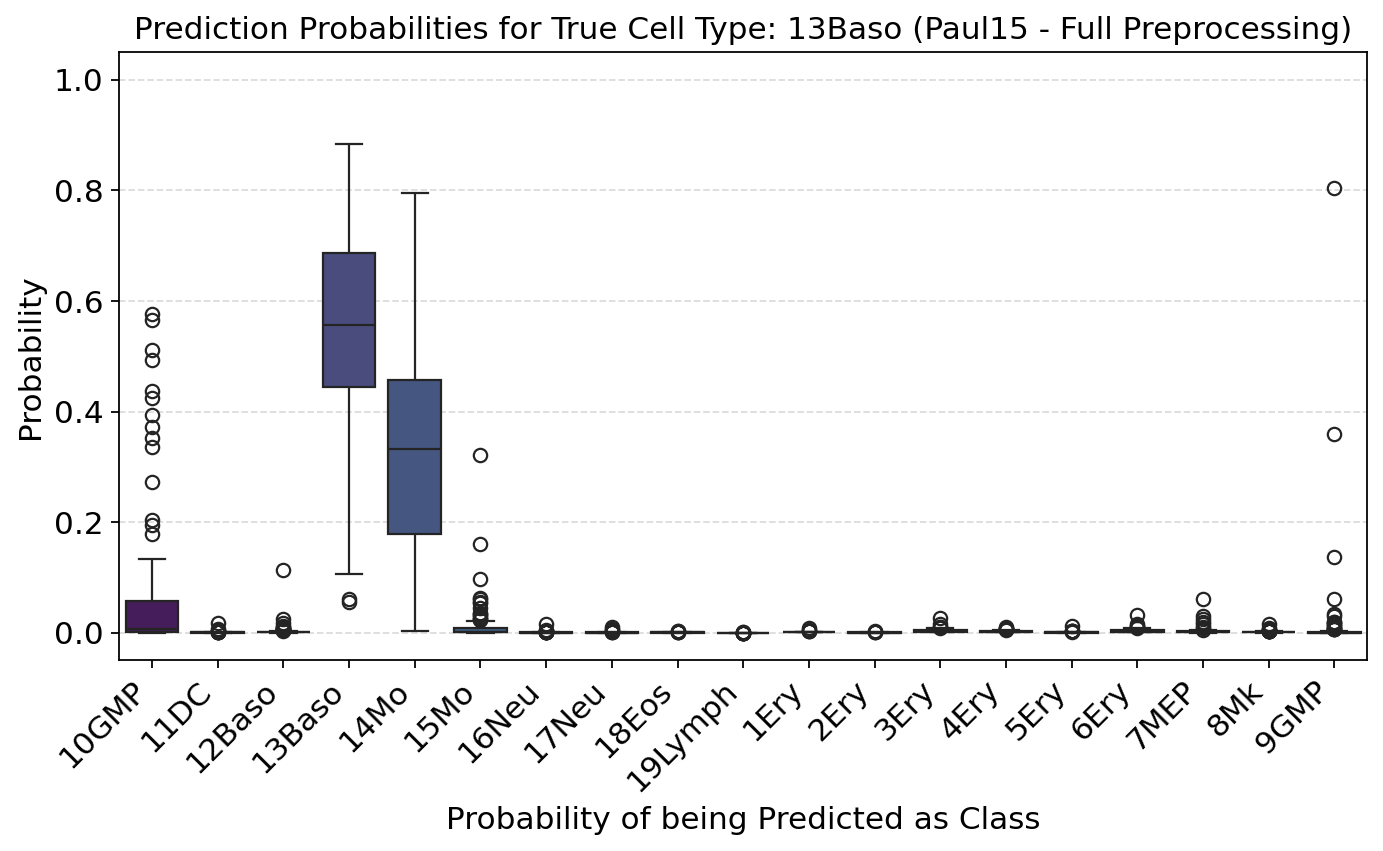

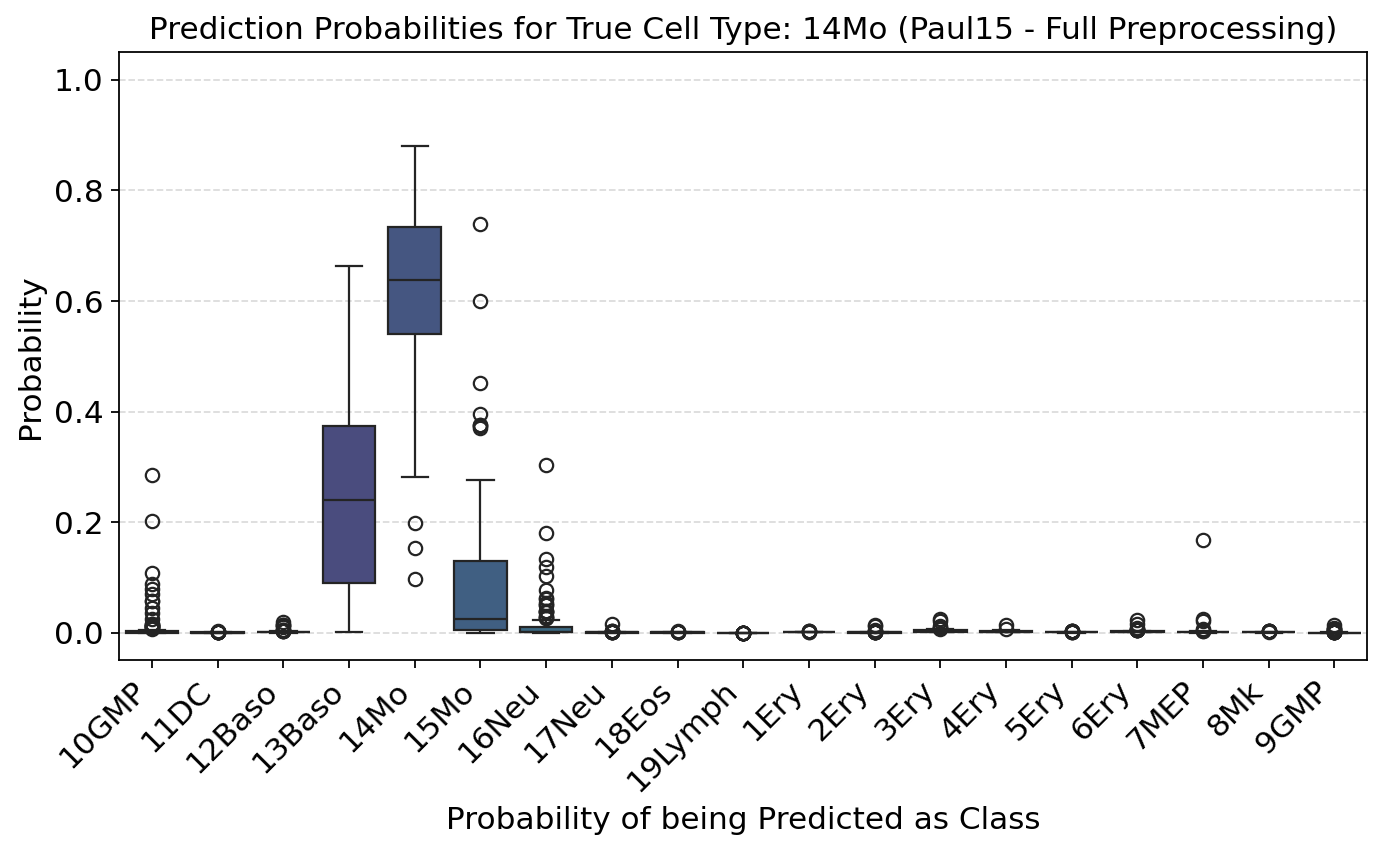

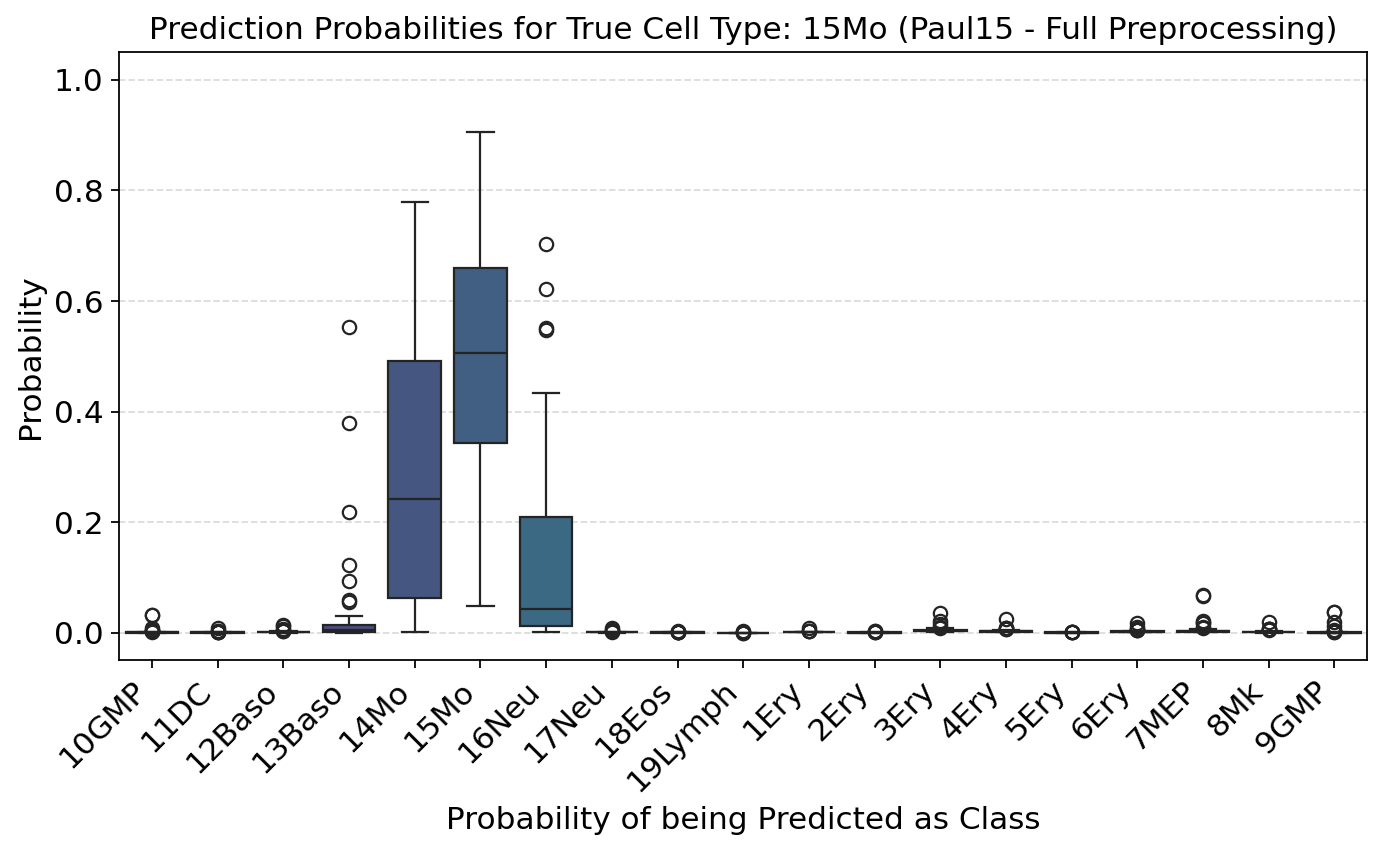

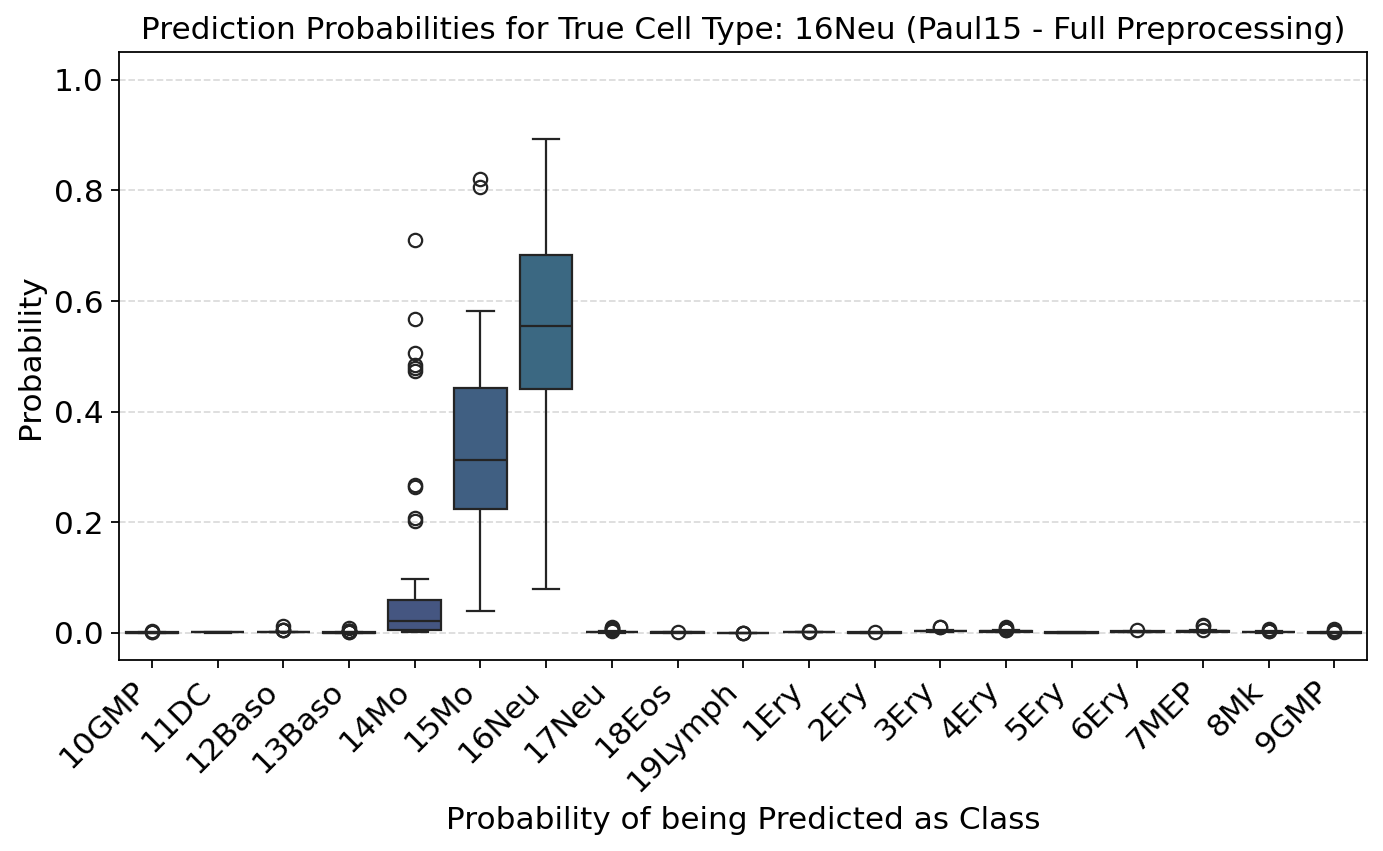

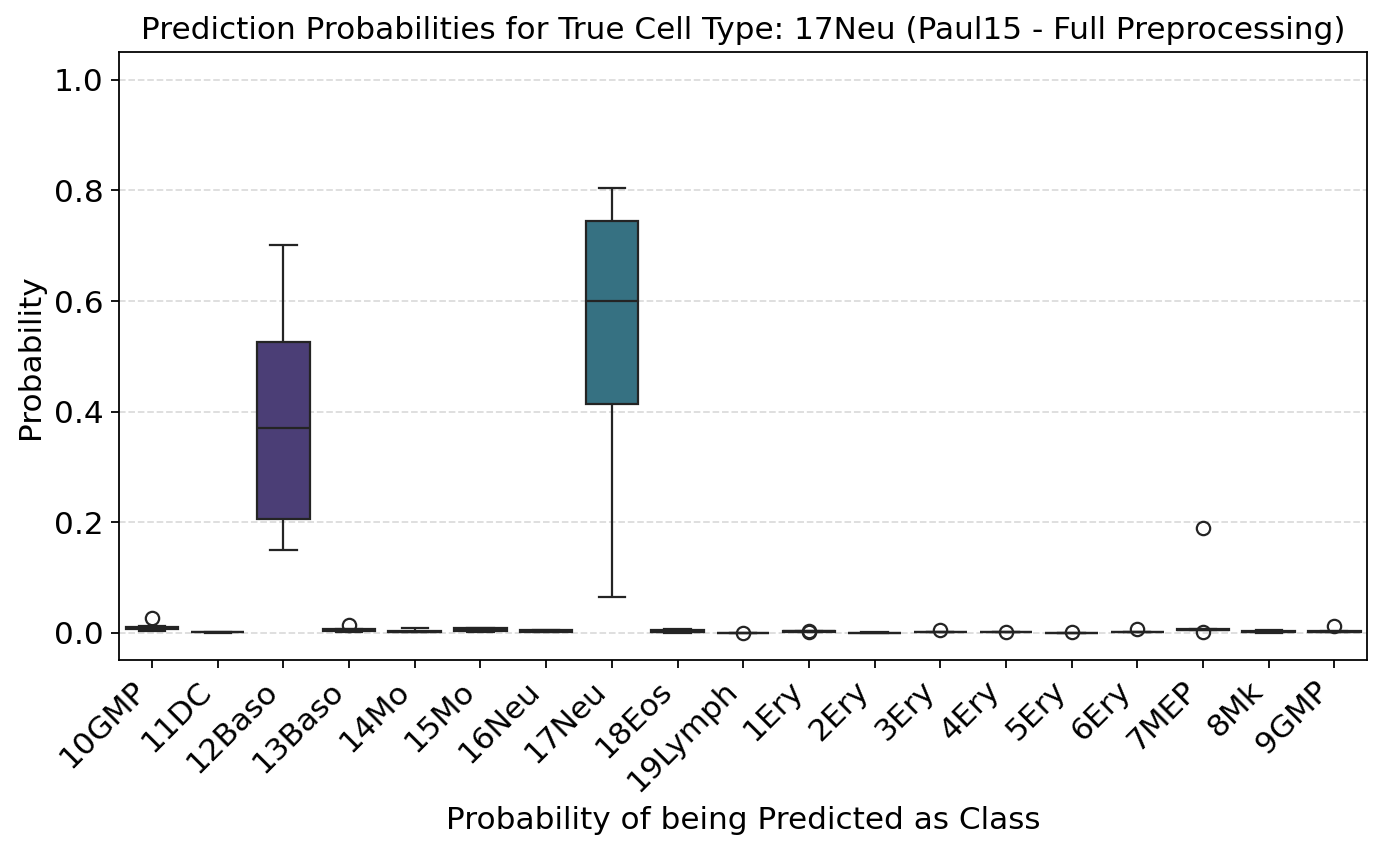

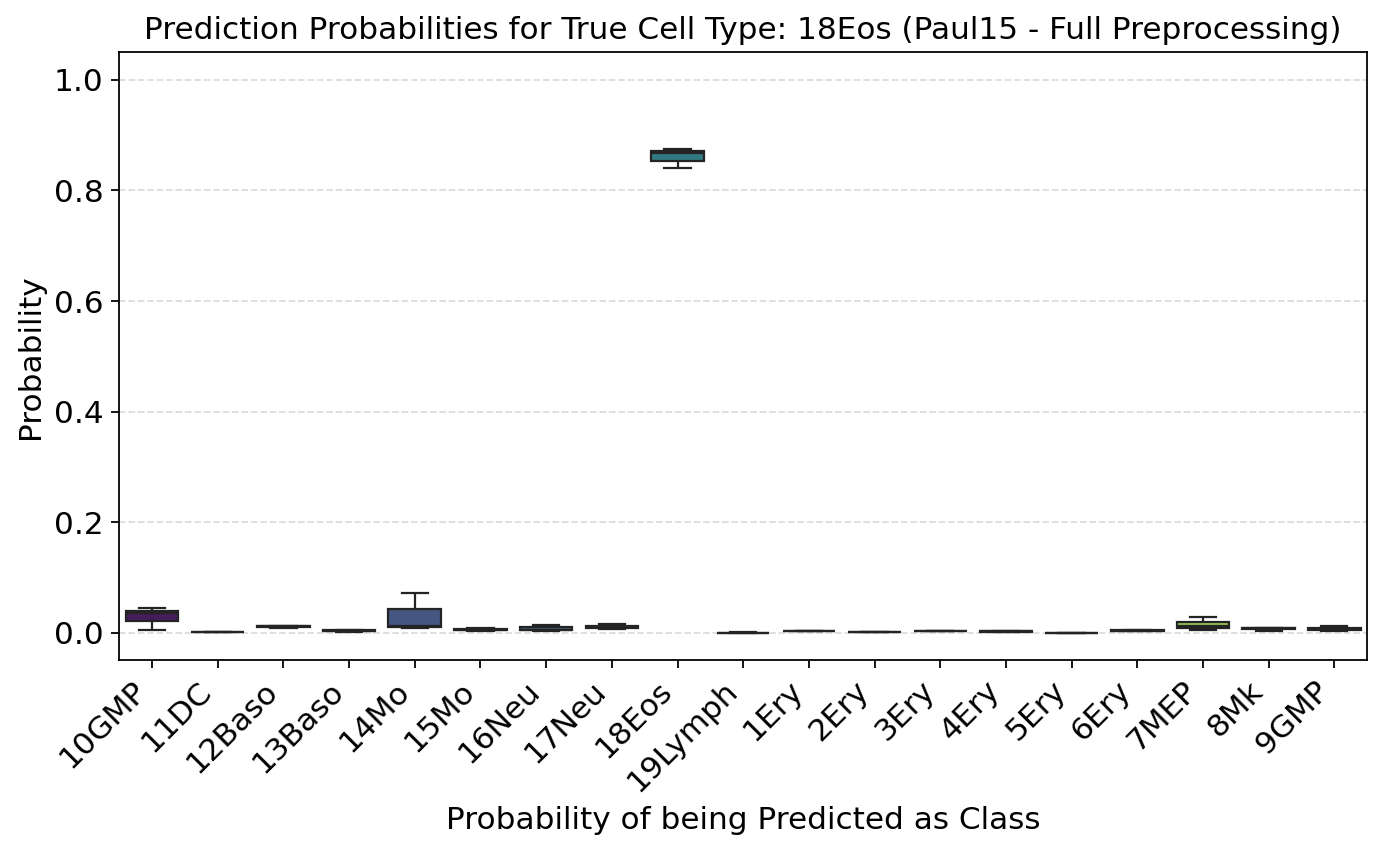

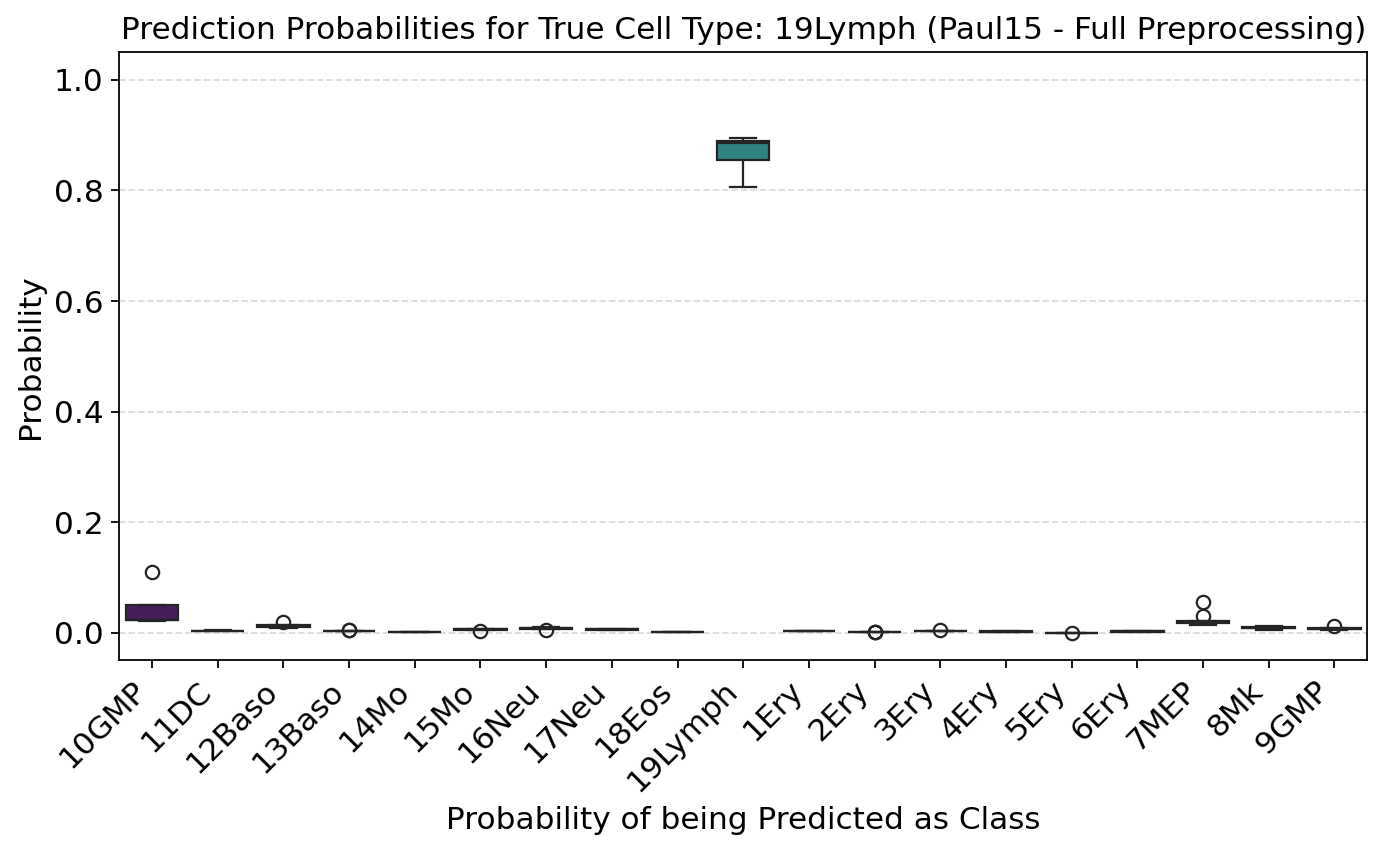

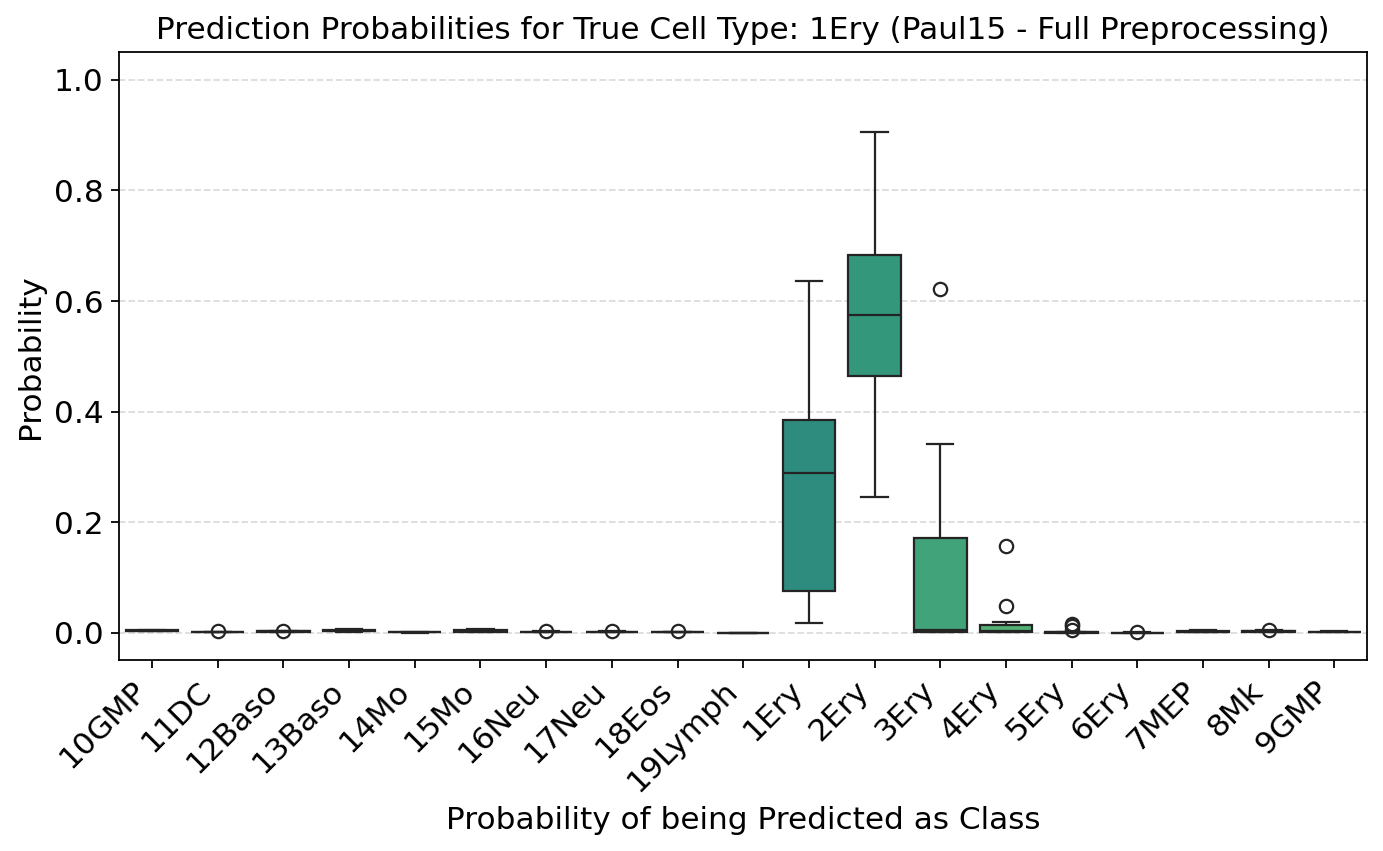

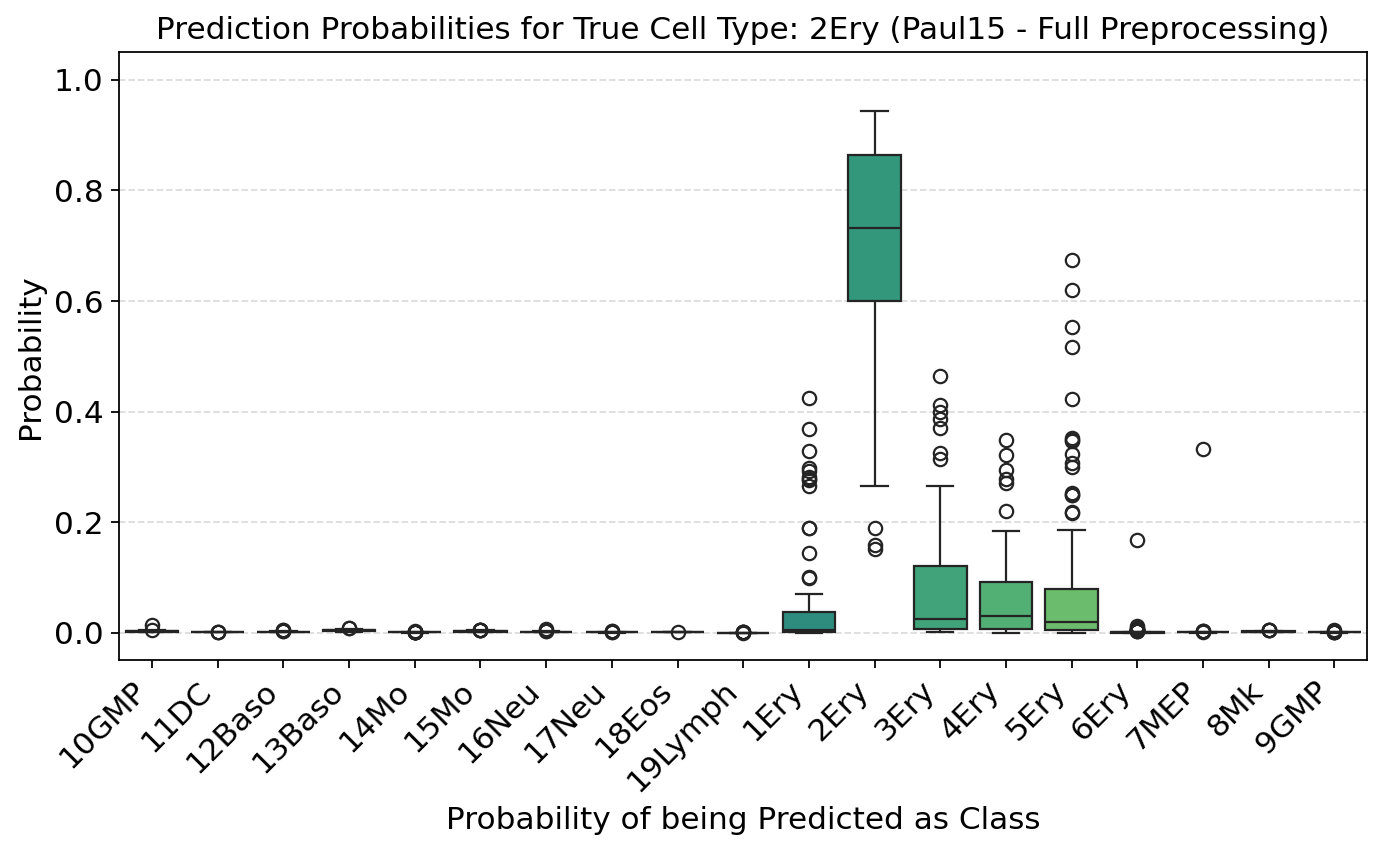

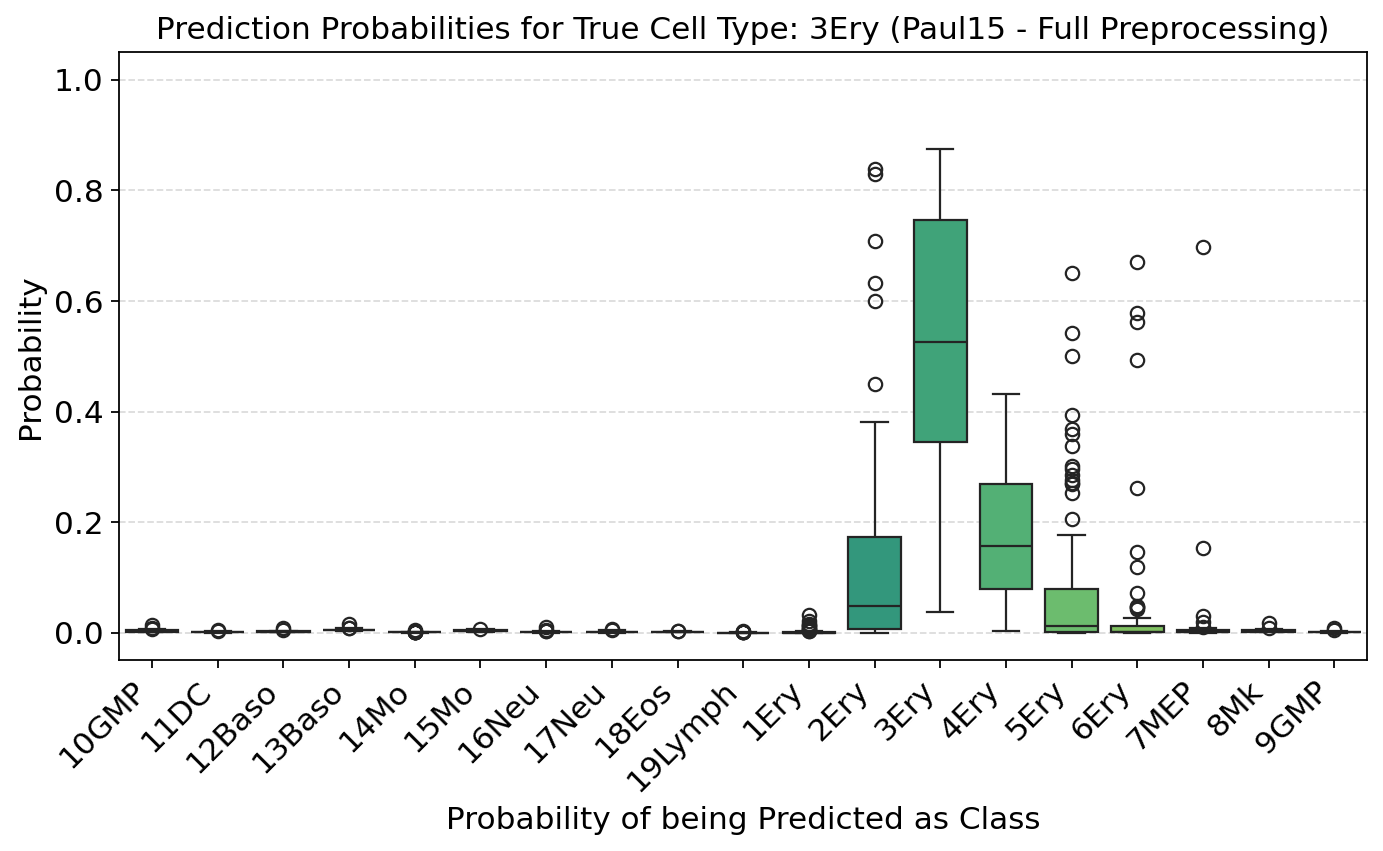

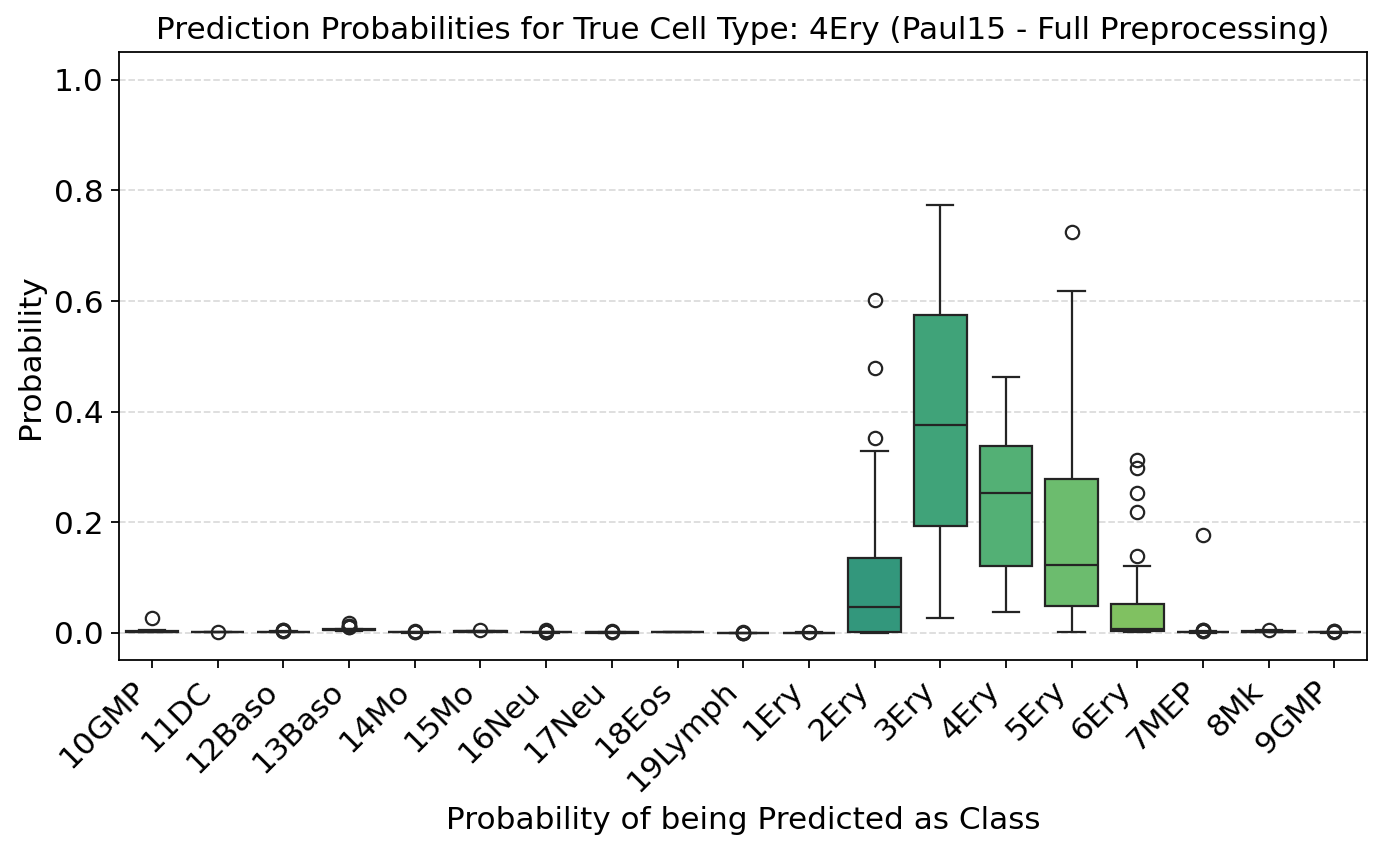

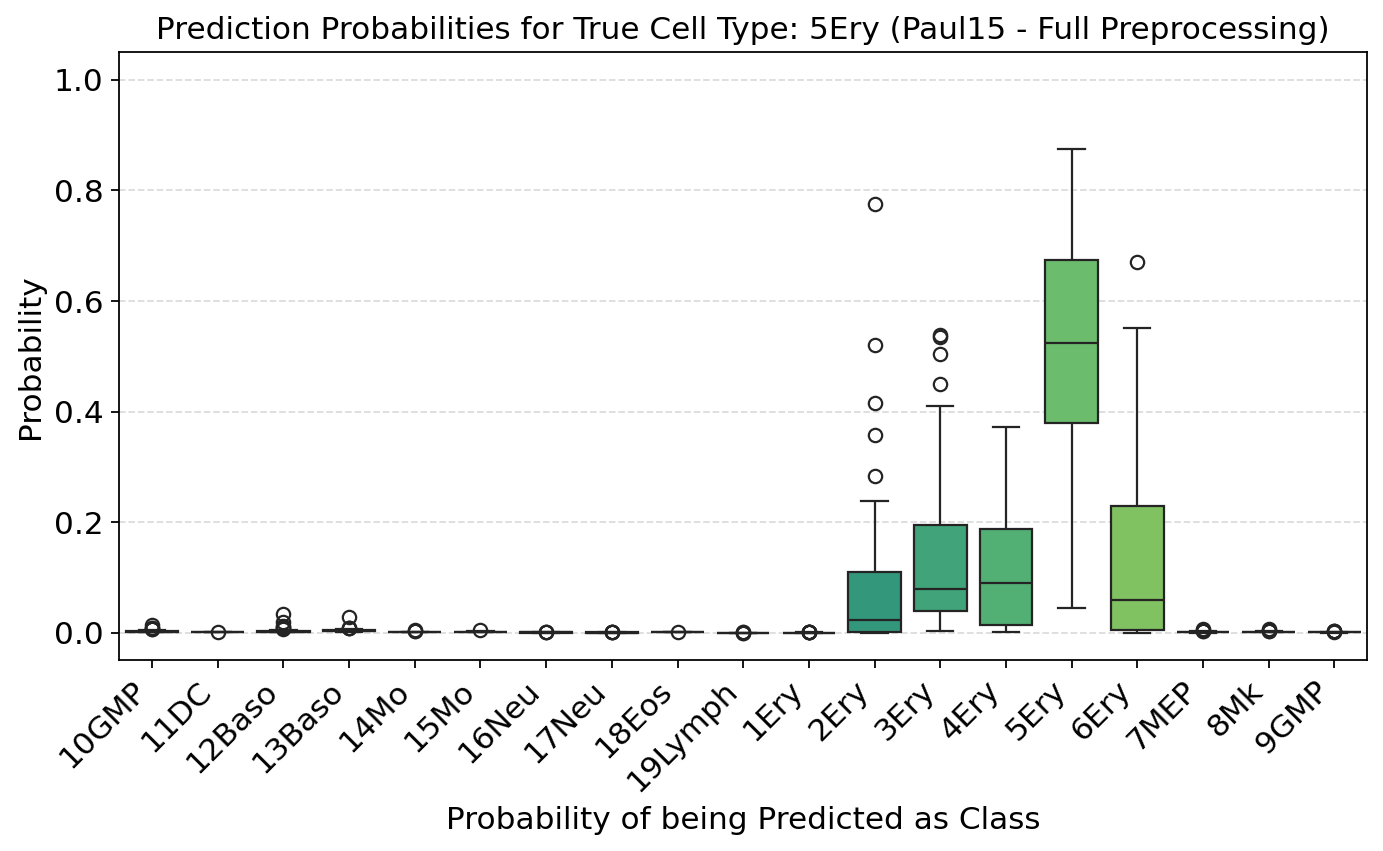

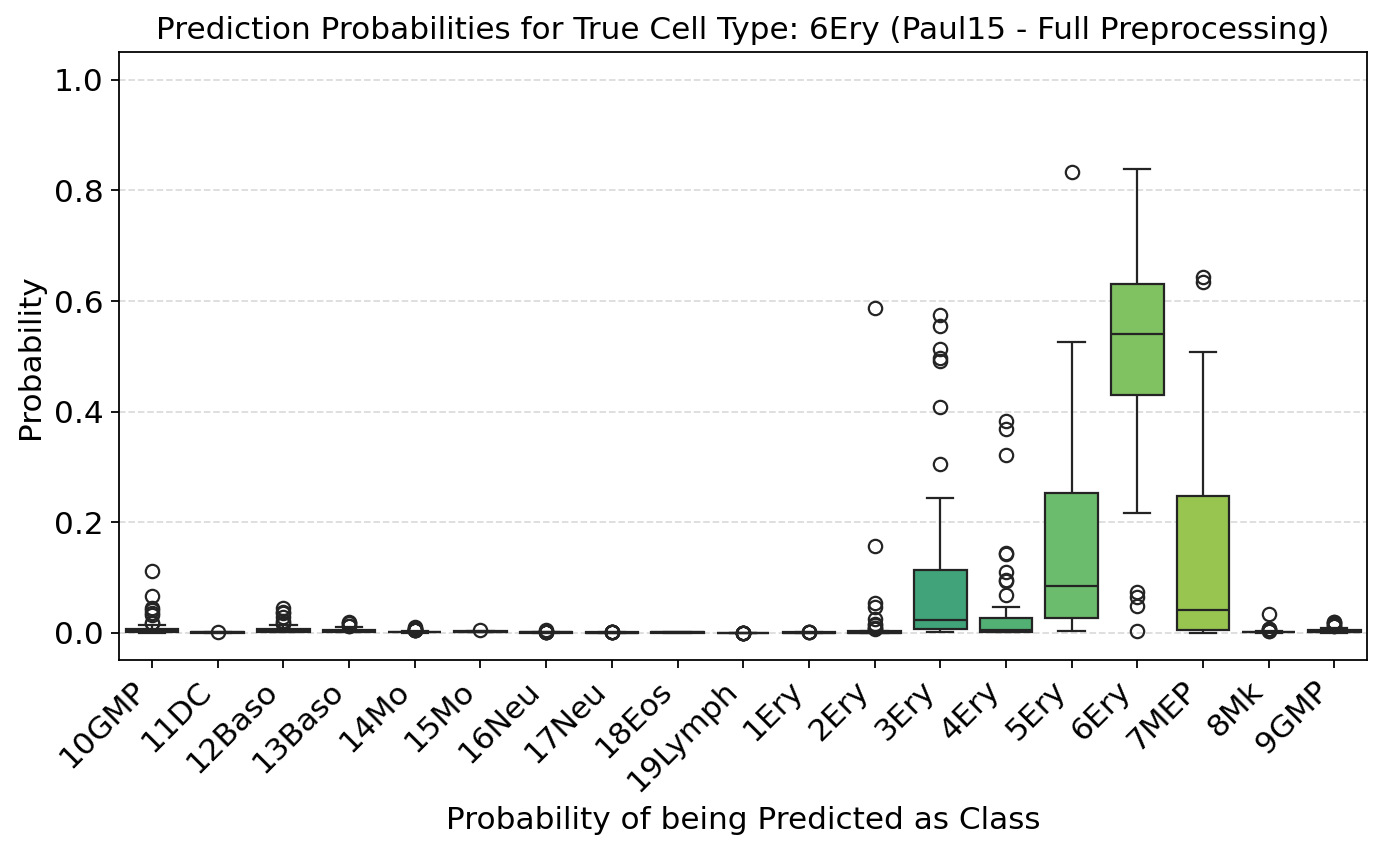

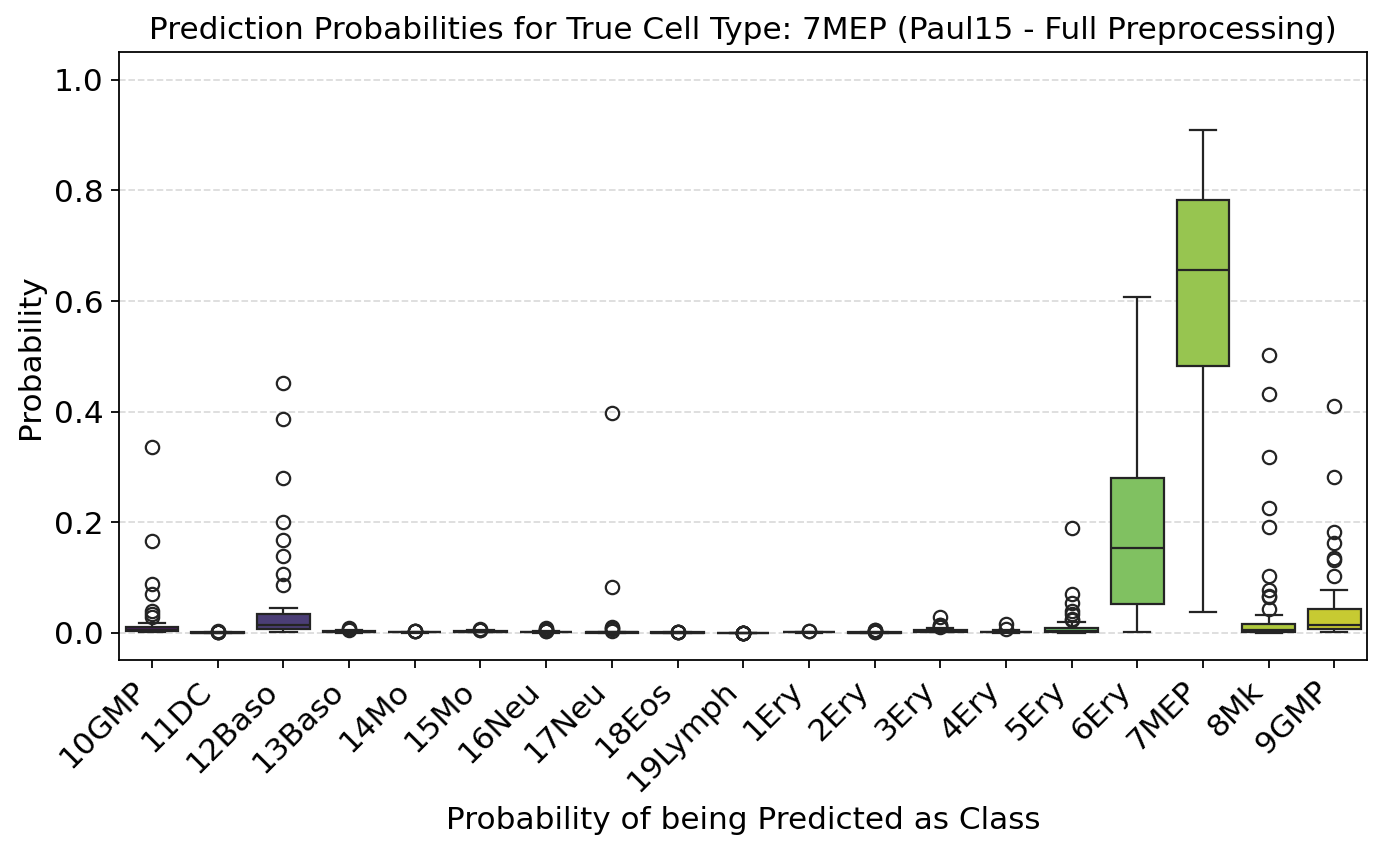

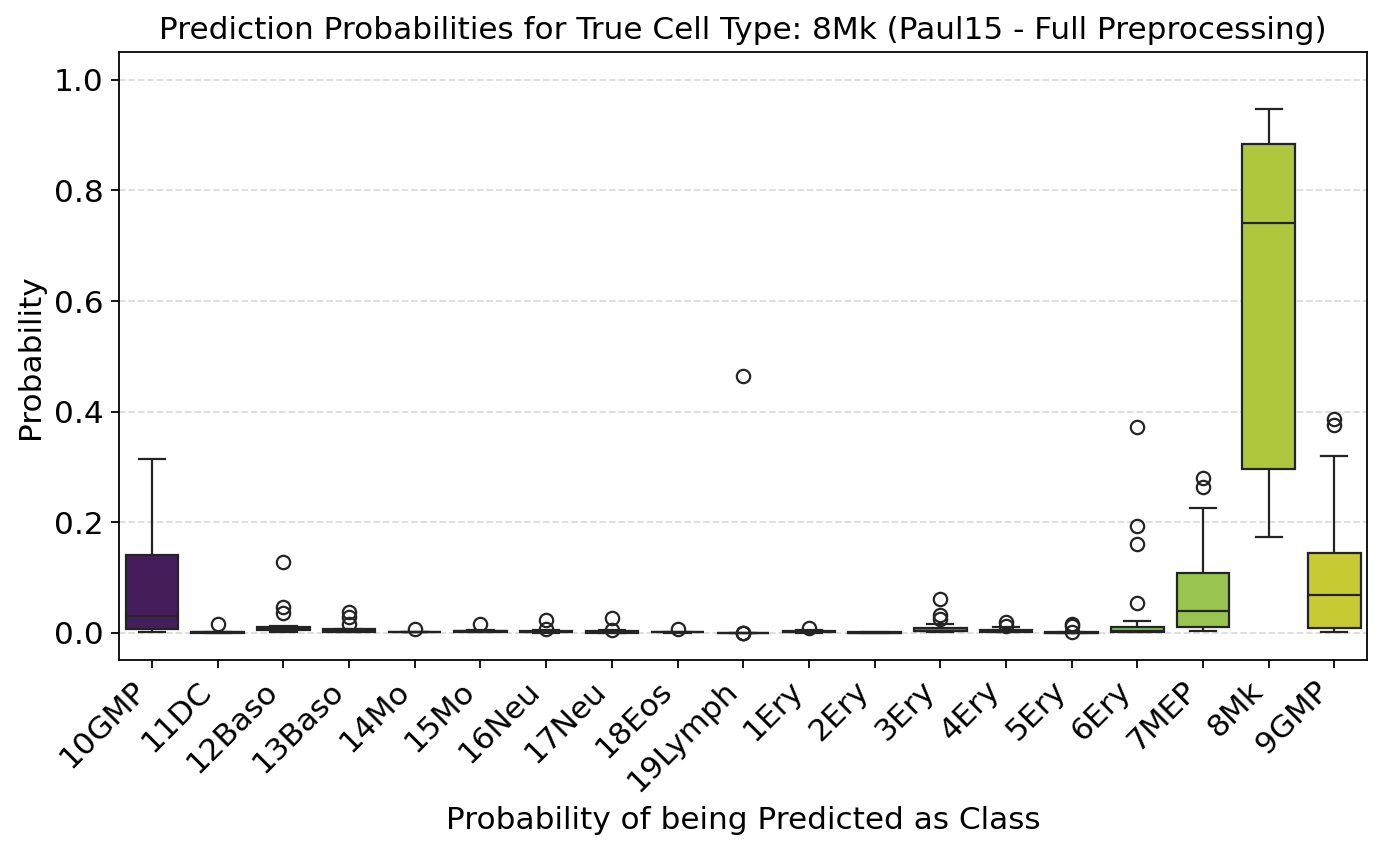

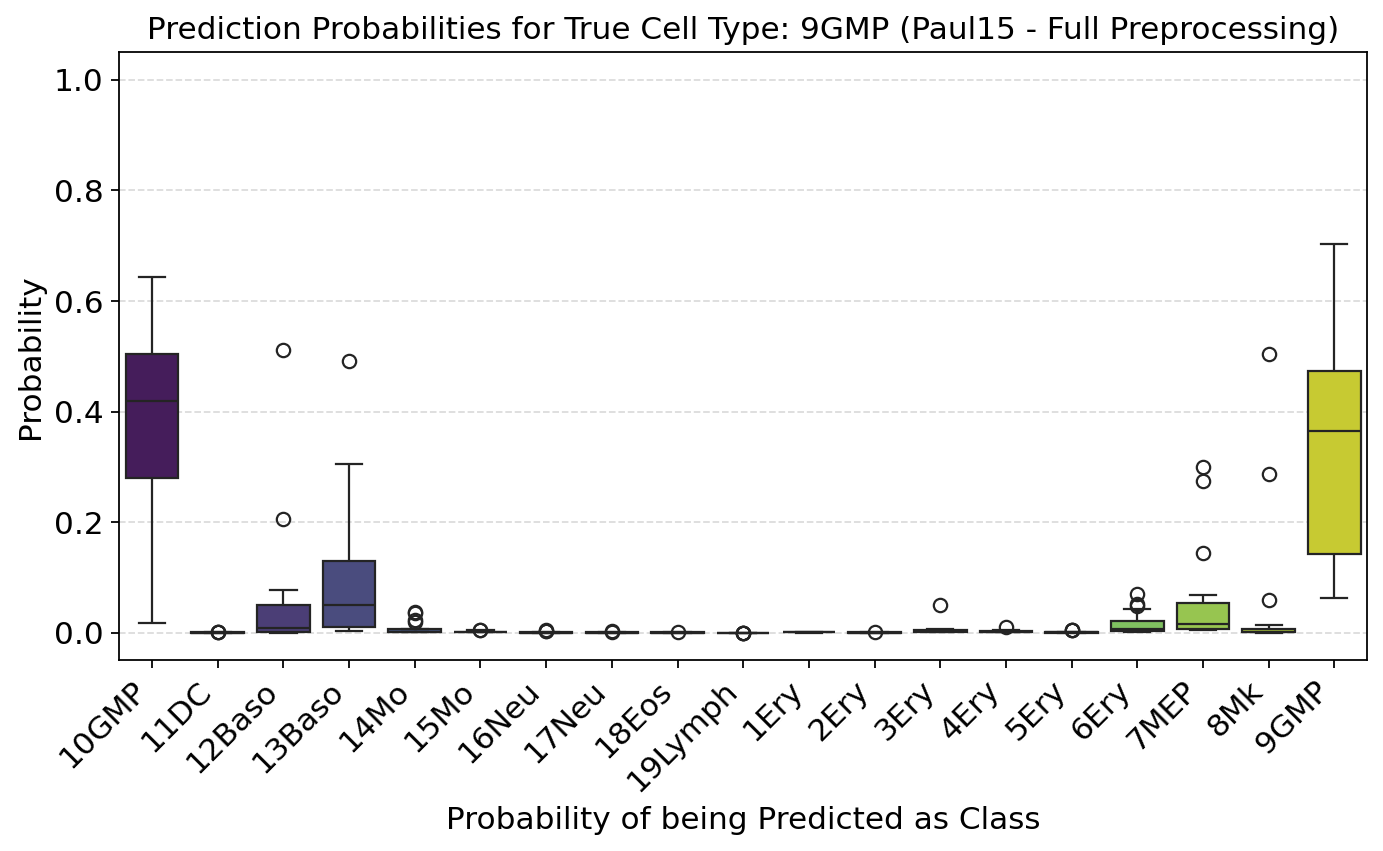


--- UMAP: True vs Predicted Labels (Paul15 - Full Preprocessing) ---


/tmp/ipykernel_4939/266608084.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_full.tight_layout(rect=[0, 0.03, 1, 0.98])


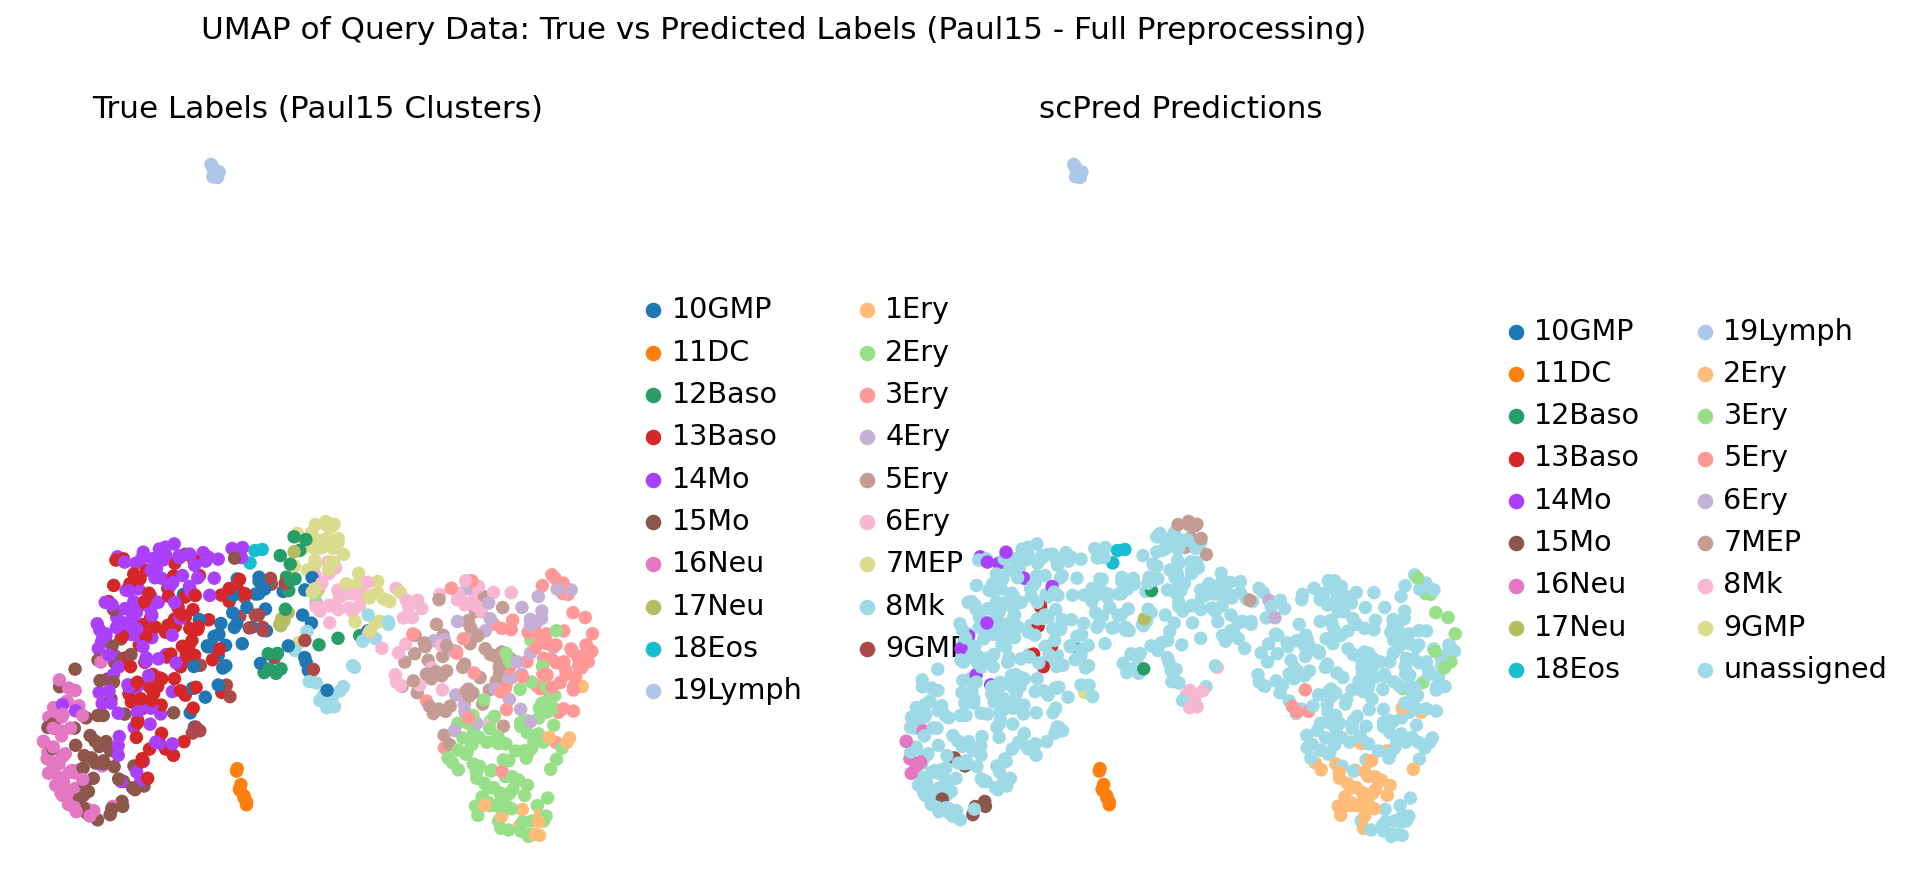


--- UMAP: Misclassified Cells (Paul15 - Full Preprocessing) ---


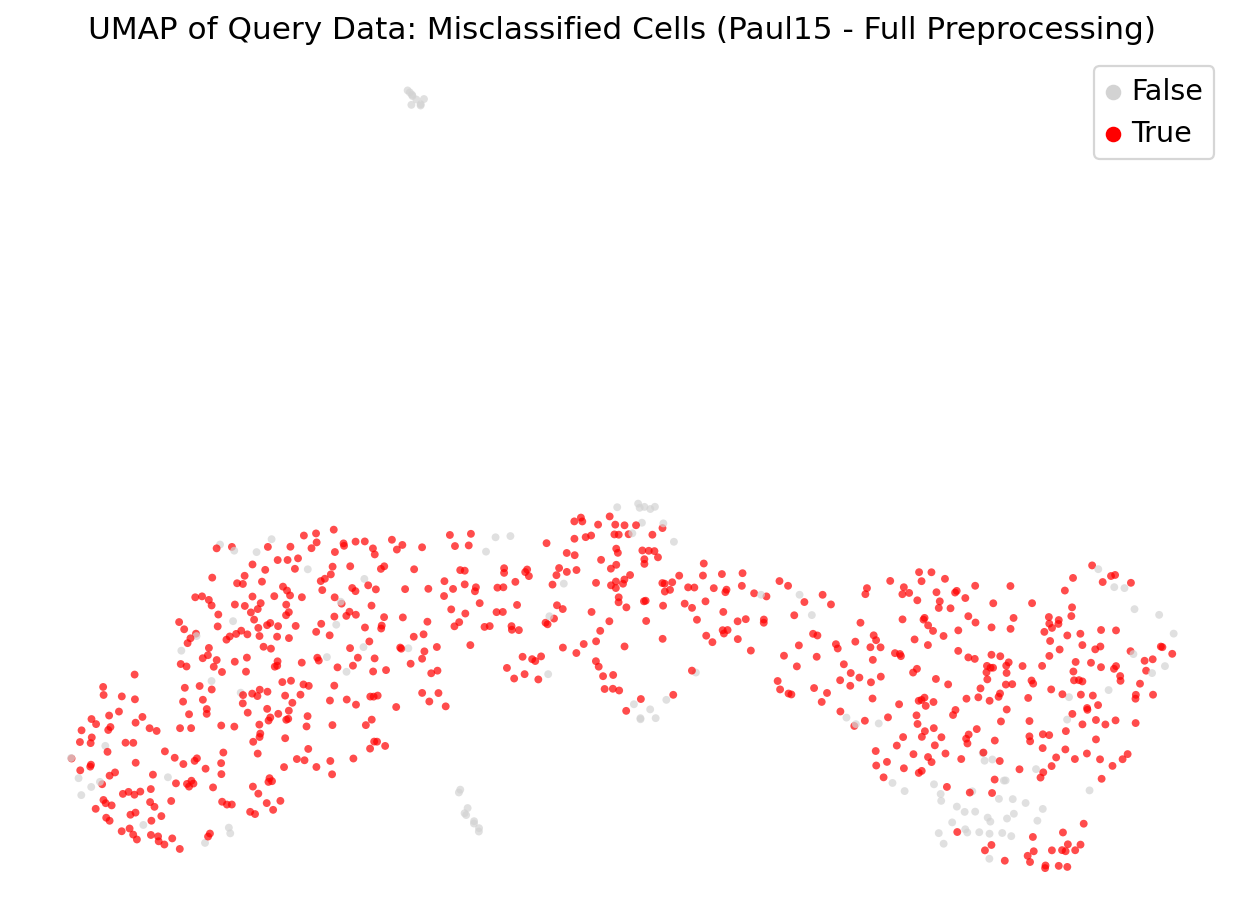


--- UMAP: Prediction Confidence (Paul15 - Full Preprocessing) ---


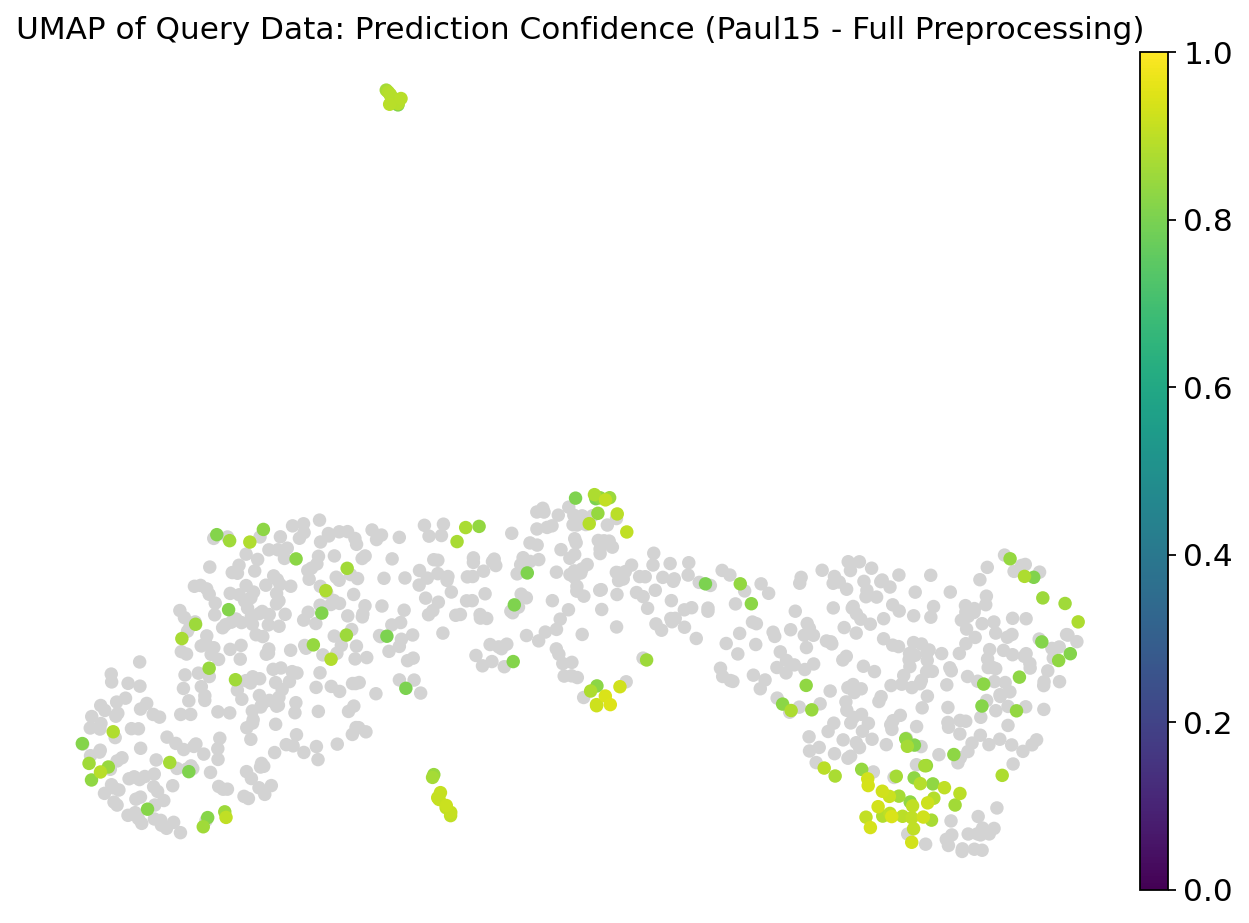


======== DEMONSTRATION 2: scPredModel (perform_preprocessing=False) ========

--- Manually Preprocessing Data for perform_preprocessing=False ---
  Manual normalization and log1p finished for reference and query.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
  Manually selected 2000 HVGs for reference.
  Manually aligned query data shape: (819, 2000)
Manually preprocessed reference data (Manual Preprocessing) saved to: ../data/preprocessed/paul15_ref_preprocessed_manual.h5ad

--- Step 3b: Training scPred Model (perform_preprocessing=False) ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 474 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardS

/tmp/ipykernel_4939/266608084.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_partial.tight_layout(rect=[0, 0.03, 1, 0.98])


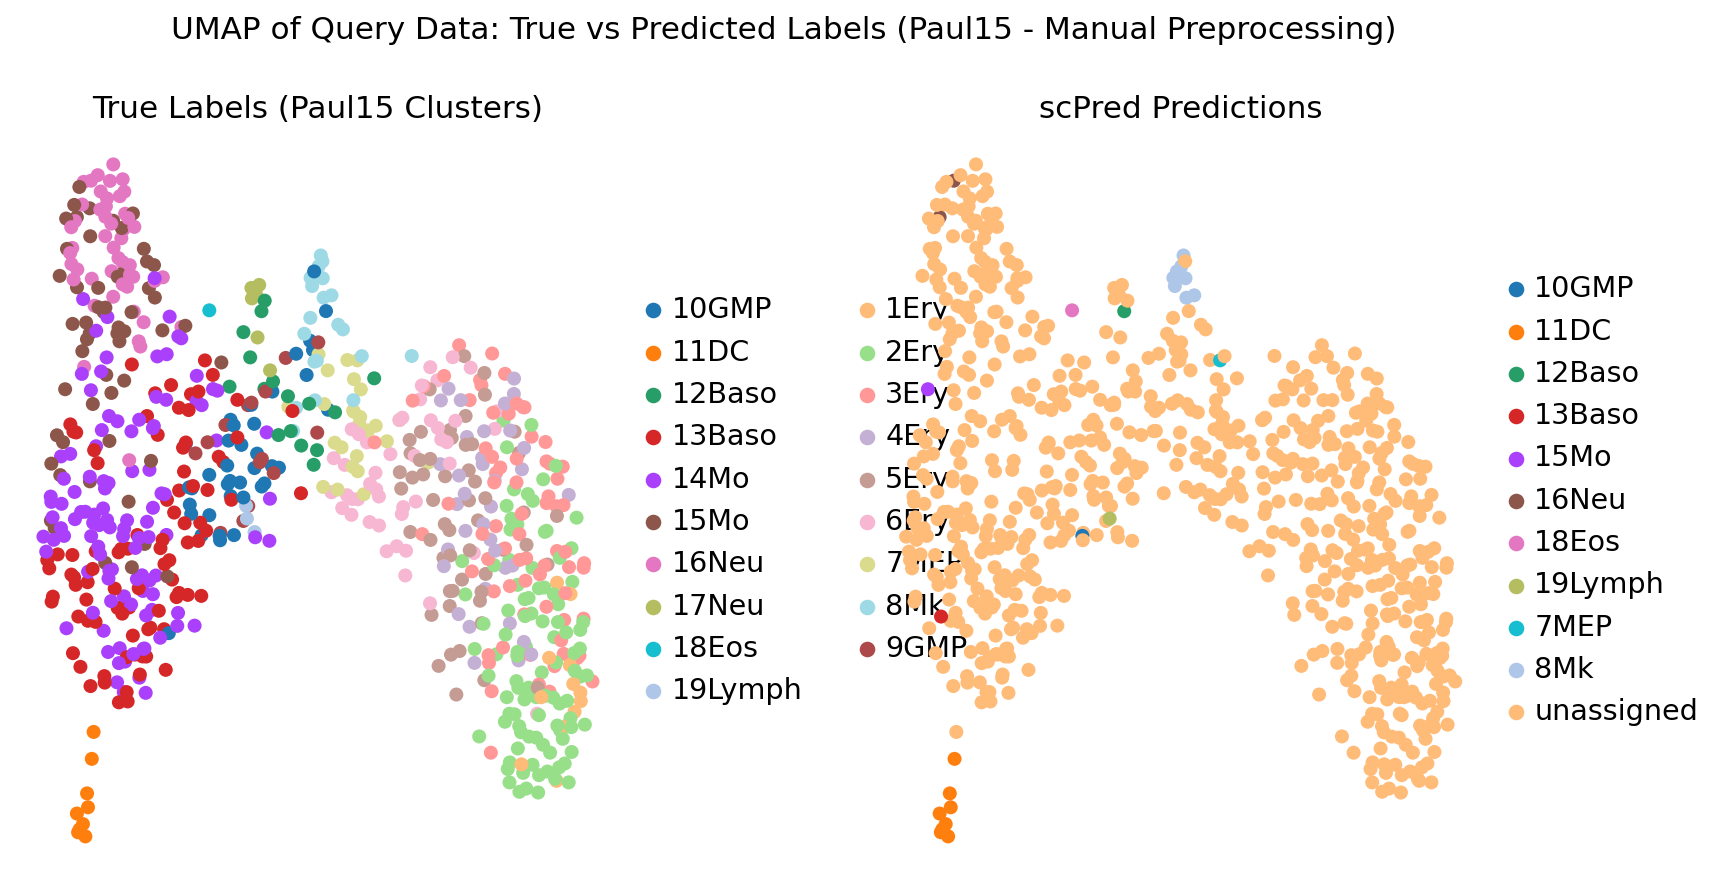


--- Confusion Matrix (Manual Preprocessing) ---


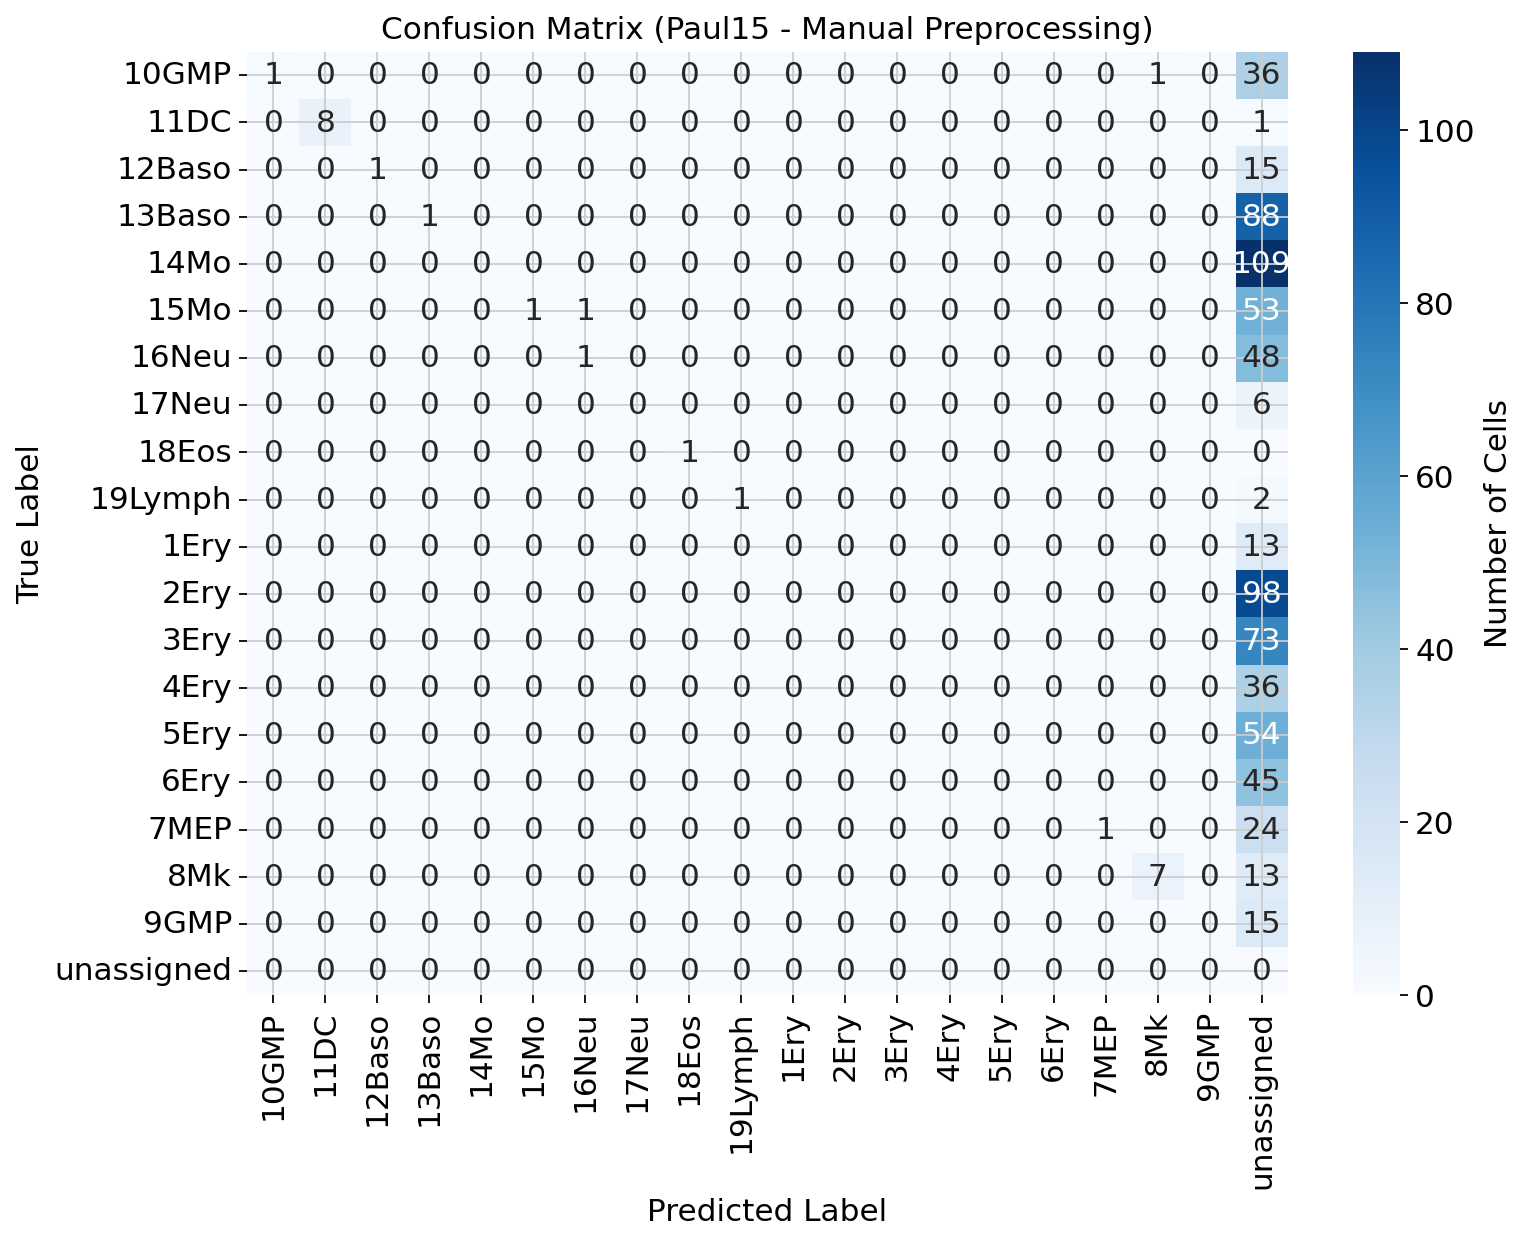


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( # Re-import these for direct use in notebook for plots/confusion matrix
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer # ADDED: Import LabelBinarizer for ROC plotting

# Adjust the path to import your scpred_py_revised package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_revised as per context
from scpred_py_final import _analysis_utils
from scpred_py_final import _preprocessing # Explicitly import for manual preprocessing steps


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation (for Paul15 dataset) ---
print("\n--- Step 1: Loading and Annotating Data (Paul15) ---")
# Load the Paul15 dataset from Scanpy
# This dataset is typically already normalized and log-transformed by Scanpy's datasets,
# but it usually does NOT have the 'log1p' flag in adata.uns, which our safety net checks.
adata_raw_paul15 = sc.datasets.paul15()
adata_raw_paul15.var_names_make_unique() # Ensure gene names are unique

print(f"Initial raw AnnData object shape (Paul15): {adata_raw_paul15.shape}")
print(f"Initial raw AnnData .obs keys: {adata_raw_paul15.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata_raw_paul15.var.keys().tolist()}\n")
print(f"Initial raw AnnData .uns keys: {list(adata_raw_paul15.uns.keys())}\n") # Check uns for log1p flag

# For the Paul15 dataset, the cell type labels are already available in .obs['paul15_clusters']
# We will use this directly as our 'cell_type' key for scPred.
# Convert to string category for consistent handling by metrics and plotting functions
adata_raw_paul15.obs['cell_type'] = adata_raw_paul15.obs['paul15_clusters'].astype(str).astype('category')

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata_raw_paul15.shape}")
print(f"Full dataset .obs keys after labeling: {adata_raw_paul15.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata_raw_paul15.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata_raw_paul15.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata_raw_paul15.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw_split = adata_raw_paul15[ref_idx, :].copy()
query_adata_raw_split = adata_raw_paul15[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw_split.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw_split.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw_split.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw_split.obs['cell_type'].value_counts())

# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw_split.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw_split.obs['cell_type'].value_counts(normalize=True).sort_index())


# ==============================================================================
# DEMONSTRATION 1: scPredModel with perform_preprocessing=True (Default)
# ==============================================================================
print("\n======== DEMONSTRATION 1: scPredModel (perform_preprocessing=True) ========")

# --- 3a. Training the scPred Model (Full Preprocessing) ---
print("\n--- Step 3a: Training scPred Model (perform_preprocessing=True) ---")
scpred_model_full = ScPredModel()

# Applying optimal parameters from comparative analysis: RBF, C=1.0, Balanced, 2000 HVGs
scpred_model_full.train(
    ref_adata=ref_adata_raw_split, # Pass the raw reference data
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=2000, # Optimal from comparative analysis
    hvg_flavor='seurat',
    svm_kernel='rbf',     # Optimal from comparative analysis
    svm_c=1.0,            # Optimal from comparative analysis
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight='balanced' # Optimal from comparative analysis
)

print("\nModel Trained (Full Preprocessing)!")
print(f"Scaler: {scpred_model_full.scaler_}")
print(f"PCA Model: {scpred_model_full.pca_model_}")
print(f"Classifier: {scpred_model_full.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model_full.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object using its new method
model_full_path = os.path.join(MODELS_DIR, 'scpred_model_paul15_full_preprocessing.pkl')
scpred_model_full.save(model_full_path)

# Save the preprocessed reference data for scenario 1
if hasattr(scpred_model_full, 'ref_adata_processed_') and scpred_model_full.ref_adata_processed_ is not None:
    preprocessed_ref_full_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_ref_preprocessed_full.h5ad')
    scpred_model_full.ref_adata_processed_.write(preprocessed_ref_full_path)
    print(f"Preprocessed reference data (Full Preprocessing) saved to: {preprocessed_ref_full_path}")
else:
    print("Warning: scpred_model_full.ref_adata_processed_ is not accessible. Preprocessed reference data not saved for Demo 1.")


# --- 4a. Predicting with the scPred Model (Full Preprocessing) ---
print("\n--- Step 4a: Predicting on Query Data (perform_preprocessing=True) ---")
PREDICTION_THRESHOLD = 0.8 # Consistent with comparative analysis
query_adata_pred_full = scpred_model_full.predict(query_adata_raw_split, threshold=PREDICTION_THRESHOLD)

print("\nQuery Data with Predictions (Full Preprocessing, first 5 rows):")
print(query_adata_pred_full.obs[['cell_type', 'scpred_prediction']].head())

# Save the preprocessed query data with predictions for scenario 1
preprocessed_query_full_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_query_pred_preprocessed_full.h5ad')
query_adata_pred_full.write(preprocessed_query_full_path)
print(f"Preprocessed query data with predictions (Full Preprocessing) saved to: {preprocessed_query_full_path}")


# --- 5a. Evaluating Predictions (Full Preprocessing) ---
# FIX: Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_full = query_adata_pred_full.obs['scpred_prediction'].notna()
true_labels_full = query_adata_pred_full.obs.loc[valid_cells_full, 'cell_type']
predicted_labels_full = query_adata_pred_full.obs.loc[valid_cells_full, 'scpred_prediction']

pred_prob_cols_full = [col for col in query_adata_pred_full.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_full = None
if len(pred_prob_cols_full) > 0:
    y_pred_probs_df_full = query_adata_pred_full.obs.loc[valid_cells_full, pred_prob_cols_full].copy()
    # Fill any remaining NaNs in probabilities with 0 (should ideally not happen if filtering by notna 'scpred_prediction')
    y_pred_probs_df_full = y_pred_probs_df_full.fillna(0.0)


print("\n--- Evaluation for Full Preprocessing Model ---")
metrics_results_full = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_full,
    predicted_labels=predicted_labels_full,
    classifier_classes=scpred_model_full.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_full
)


# --- 6a. Visualizing Results (Full Preprocessing) ---
print("\n--- Step 6a: Visualizing Results (Full Preprocessing) ---")

# For UMAP plots, we need the AnnData object to be filtered to only valid cells or handle NaNs in plots.
# It's safer to create a temporary filtered AnnData for plotting to avoid issues with NaN coordinates.
query_adata_pred_full_filtered_for_umap = query_adata_pred_full[valid_cells_full, :].copy()

# FIX: Remove potentially stale 'iroot' and 'neighbors' graph info from .uns of the subsetted AnnData
# This helps prevent warnings like "Root cell index X does not exist..."
if 'iroot' in query_adata_pred_full_filtered_for_umap.uns:
    del query_adata_pred_full_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_full_filtered_for_umap.uns:
    del query_adata_pred_full_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_full_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_full_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_full_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE) # Added random_state
    sc.tl.umap(query_adata_pred_full_filtered_for_umap, random_state=RANDOM_STATE) # Added random_state
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_full_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_full_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

# Plot 1: Confusion Matrix
print("\n--- Confusion Matrix (Full Preprocessing) ---")
true_labels_str_full = true_labels_full.astype(str) # Use already filtered labels
predicted_labels_str_full = predicted_labels_full.astype(str) # Use already filtered labels

# --- FIX: Ensure 'unassigned' is included in confusion matrix labels ---
# Get all unique labels from both true and predicted sets
cm_all_labels_full = sorted(list(set(true_labels_str_full.unique()) | set(predicted_labels_str_full.unique())))
# Move 'unassigned' to the end if present
if 'unassigned' in cm_all_labels_full:
    cm_all_labels_full.remove('unassigned')
    cm_all_labels_full.append('unassigned')

cm_full = confusion_matrix(true_labels_str_full, predicted_labels_str_full, labels=cm_all_labels_full)
cm_df_full = pd.DataFrame(cm_full, index=cm_all_labels_full, columns=cm_all_labels_full)

plt.figure(figsize=(10, 8)) # Increased figure size for better readability
sns.heatmap(cm_df_full, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (Paul15 - Full Preprocessing)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout() # Ensure labels fit
plt.show()

# Plot 2: Per-Class ROC AUC (Full Preprocessing)
print("\n--- Per-Class ROC AUC (Paul15 - Full Preprocessing) ---")
if hasattr(scpred_model_full.classifier_, 'predict_proba'):
    classes_full = scpred_model_full.classifier_.classes_
    y_true_binary_full = pd.get_dummies(true_labels_str_full, columns=classes_full, drop_first=False).values
    y_scores_full = y_pred_probs_df_full[[f"scpred_prob_{c}" for c in classes_full]].values

    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes_full):
        if y_true_binary_full.shape[1] > i and len(np.unique(y_true_binary_full[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true_binary_full[:, i], y_scores_full[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels.")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve (Paul15 - Full Preprocessing)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Plot 3: Distribution of Prediction Probabilities (Full Preprocessing)
print("\n--- Distribution of Prediction Probabilities (Paul15 - Full Preprocessing) ---")
if hasattr(scpred_model_full.classifier_, 'predict_proba'):
    prob_df_full = query_adata_pred_full_filtered_for_umap.obs[[f"scpred_prob_{c}" for c in scpred_model_full.classifier_.classes_]].copy()
    prob_df_full['true_cell_type'] = query_adata_pred_full_filtered_for_umap.obs['cell_type'].astype(str)
    prob_melted_full = prob_df_full.melt(
        id_vars='true_cell_type',
        value_vars=[f"scpred_prob_{c}" for c in scpred_model_full.classifier_.classes_],
        var_name='predicted_class_prob_of',
        value_name='probability'
    )
    prob_melted_full['predicted_class_prob_of'] = prob_melted_full['predicted_class_prob_of'].str.replace('scpred_prob_', '')
    for true_type in sorted(prob_melted_full['true_cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted_full[prob_melted_full['true_cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='predicted_class_prob_of', y='probability', hue='predicted_class_prob_of', palette='viridis', legend=False)
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} (Paul15 - Full Preprocessing)')
        plt.xlabel('Probability of being Predicted as Class')
        plt.ylabel('Probability')
        plt.ylim(-0.05, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45, ha='right') # FIX: Rotate x-axis labels
        plt.show()

# UMAP plots (Full Preprocessing)
if 'X_umap' in query_adata_pred_full_filtered_for_umap.obsm: # Use filtered adata for UMAP
    print("\n--- UMAP: True vs Predicted Labels (Paul15 - Full Preprocessing) ---")
    
    # sc.pl.umap with color as a list returns a list of Axes objects when show=False.
    # We need to get the figure from one of these axes.
    axes_list_full = sc.pl.umap(
        query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Paul15 Clusters)', 'scPred Predictions'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    # Get the figure from the first axis in the list
    fig_full = axes_list_full[0].figure
    fig_full.set_size_inches(12, 6) # Set the figure size after creation by scanpy
    fig_full.suptitle('UMAP of Query Data: True vs Predicted Labels (Paul15 - Full Preprocessing)', y=1.02, fontsize=14)
    fig_full.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("\n--- UMAP: Misclassified Cells (Paul15 - Full Preprocessing) ---")
    # true_labels_str_full and predicted_labels_str_full are already filtered
    query_adata_pred_full_filtered_for_umap.obs['misclassified'] = (true_labels_str_full != predicted_labels_str_full).astype(str).astype('category')
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    # FIX: Explicitly create figure and axes
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
        color='misclassified', palette=misclassified_palette, size=50, alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells (Paul15 - Full Preprocessing)',
        frameon=False, show=False, legend_loc='upper right', # Fixed legend_loc
        ax=ax # Pass the single axis
    )
    fig.tight_layout() # Apply tight_layout to the figure
    plt.show()

    print("\n--- UMAP: Prediction Confidence (Paul15 - Full Preprocessing) ---")
    if hasattr(scpred_model_full.classifier_, 'predict_proba'):
        def get_predicted_prob(row, classes):
            pred_class = row['scpred_prediction']
            # Handle 'unassigned' cells for confidence plot
            if pred_class == 'unassigned' or pd.isna(pred_class):
                return np.nan # Or 0.0, depending on desired visualization of unassigned
            prob_col_name = f'scpred_prob_{pred_class}'
            if prob_col_name in row.index:
                return row[prob_col_name]
            return np.nan
        prob_cols_full_model = [col for col in query_adata_pred_full_filtered_for_umap.obs.columns if col.startswith('scpred_prob_')] # Filter cols based on filtered adata
        if all(col in query_adata_pred_full_filtered_for_umap.obs.columns for col in prob_cols_full_model): # Check against filtered adata
            temp_obs_for_apply_full = query_adata_pred_full_filtered_for_umap.obs[['scpred_prediction'] + prob_cols_full_model]
            query_adata_pred_full_filtered_for_umap.obs['predicted_prob_score'] = temp_obs_for_apply_full.apply(
                lambda row: get_predicted_prob(row, scpred_model_full.classifier_.classes_), axis=1
            )
            # FIX: Explicitly create figure and axes
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            sc.pl.umap(
                query_adata_pred_full_filtered_for_umap, # Use filtered adata for UMAP
                color='predicted_prob_score', cmap='viridis',
                title='UMAP of Query Data: Prediction Confidence (Paul15 - Full Preprocessing)',
                frameon=False, vmin=0.0, vmax=1.0, show=False,
                ax=ax # Pass the single axis
            )
            fig.tight_layout() # Apply tight_layout to the figure
            plt.show()
    else:
        print("Skipping UMAP by prediction confidence: Classifier does not support `predict_proba`.")
else:
    print("Skipping UMAP plots as 'X_umap' is not available in .obsm.")


# ==============================================================================
# DEMONSTRATION 2: scPredModel with perform_preprocessing=False
# User explicitly preprocesses data before passing to model.
# This will *avoid* the redundant log1p application.
# ==============================================================================
print("\n======== DEMONSTRATION 2: scPredModel (perform_preprocessing=False) ========")

# --- Preprocessing Data MANUALLY for perform_preprocessing=False mode ---
print("\n--- Manually Preprocessing Data for perform_preprocessing=False ---")
# Create copies to avoid modifying original raw splits
ref_adata_manual_prep = ref_adata_raw_split.copy()
query_adata_manual_prep = query_adata_raw_split.copy()

# Step 1: Normalize and Log1p (Manually)
sc.pp.normalize_total(ref_adata_manual_prep, target_sum=1e4)
sc.pp.log1p(ref_adata_manual_prep)
# IMPORTANT: Manually set the 'log1p' flag in adata.uns to inform downstream tools
ref_adata_manual_prep.uns['log1p'] = {'base': None} # Indicate it's log-transformed

sc.pp.normalize_total(query_adata_manual_prep, target_sum=1e4)
sc.pp.log1p(query_adata_manual_prep)
query_adata_manual_prep.uns['log1p'] = {'base': None}

print("  Manual normalization and log1p finished for reference and query.")

# Step 2: Highly Variable Genes selection (on reference)
# For simplicity, we'll apply it after log1p here to get HVGs on the manually processed data.
ref_adata_manual_prep, ref_hvg_genes_manual = _preprocessing.select_highly_variable_genes(
    ref_adata_manual_prep, n_top_genes=2000, flavor='seurat' # Added flavor and n_top_genes
)
print(f"  Manually selected {ref_adata_manual_prep.shape[1]} HVGs for reference.")


# Step 3: Align query genes to reference HVGs
# The _preprocessing.align_genes_to_reference function will handle this.
# This aligns the genes in query_adata_manual_prep to the common HVGs found in reference.
query_expr_df_manual = pd.DataFrame(
    query_adata_manual_prep.X.toarray() if hasattr(query_adata_manual_prep.X, 'toarray') else query_adata_manual_prep.X,
    index=query_adata_manual_prep.obs_names,
    columns=query_adata_manual_prep.var_names
)
aligned_query_expr_df_manual = query_expr_df_manual.reindex(columns=ref_hvg_genes_manual, fill_value=0.0)

aligned_query_manual_prep = ad.AnnData(
    X=aligned_query_expr_df_manual.values,
    obs=query_adata_manual_prep.obs.loc[aligned_query_expr_df_manual.index],
    var=pd.DataFrame(index=aligned_query_expr_df_manual.columns)
)
print(f"  Manually aligned query data shape: {aligned_query_manual_prep.shape}")

# Save the manually preprocessed reference data for scenario 2
preprocessed_ref_manual_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_ref_preprocessed_manual.h5ad')
ref_adata_manual_prep.write(preprocessed_ref_manual_path)
print(f"Manually preprocessed reference data (Manual Preprocessing) saved to: {preprocessed_ref_manual_path}")


# --- 3b. Training the scPred Model (perform_preprocessing=False) ---
print("\n--- Step 3b: Training scPred Model (perform_preprocessing=False) ---")
scpred_model_partial = ScPredModel()

# Pass the manually preprocessed data (normalized, log1p, HVG-selected)
# Model will then only perform scaling and PCA internally.
# Applying optimal parameters from comparative analysis: RBF, C=1.0, Balanced, 2000 HVGs
scpred_model_partial.train(
    ref_adata=ref_adata_manual_prep, # Pass the manually preprocessed data
    cell_type_key='cell_type',
    n_components=30, # Same as before
    # hvg parameters are now ignored by ScPredModel's train when perform_preprocessing=False
    svm_kernel='rbf',     # Optimal from comparative analysis
    svm_c=1.0,            # Optimal from comparative analysis
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight='balanced' # Optimal from comparative analysis
)

print("\nModel Trained (Manual Preprocessing)! (Optimal Parameters Applied)")
print(f"Scaler: {scpred_model_partial.scaler_}")
print(f"PCA Model: {scpred_model_partial.pca_model_}")
print(f"Classifier: {scpred_model_partial.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model_partial.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object for scenario 2
model_partial_path = os.path.join(MODELS_DIR, 'scpred_model_paul15_manual_preprocessing.pkl')
scpred_model_partial.save(model_partial_path)


# --- 4b. Predicting with the scPred Model (perform_preprocessing=False) ---
print("\n--- Step 4b: Predicting on Query Data (perform_preprocessing=False) ---")
# Pass the manually preprocessed query data (normalized, log1p, aligned to reference HVGs)
query_adata_pred_partial = scpred_model_partial.predict(aligned_query_manual_prep, threshold=PREDICTION_THRESHOLD)

print("\nQuery Data with Predictions (Manual Preprocessing, first 5 rows):")
print(query_adata_pred_partial.obs[['cell_type', 'scpred_prediction']].head())

# Save the preprocessed query data with predictions for scenario 2
preprocessed_query_manual_path = os.path.join(PREPROCESSED_DATA_DIR, 'paul15_query_pred_preprocessed_manual.h5ad')
query_adata_pred_partial.write(preprocessed_query_manual_path)
print(f"Manually preprocessed query data with predictions (Manual Preprocessing) saved to: {preprocessed_query_manual_path}")


# --- 5b. Evaluating Predictions (Manual Preprocessing) ---
# FIX: Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_partial = query_adata_pred_partial.obs['scpred_prediction'].notna()
true_labels_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, 'cell_type']
predicted_labels_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, 'scpred_prediction']

pred_prob_cols_partial = [col for col in query_adata_pred_partial.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_partial = None
if len(pred_prob_cols_partial) > 0:
    y_pred_probs_df_partial = query_adata_pred_partial.obs.loc[valid_cells_partial, pred_prob_cols_partial].copy()
    # Fill any remaining NaNs in probabilities with 0
    y_pred_probs_df_partial = y_pred_probs_df_partial.fillna(0.0)


print("\n--- Evaluation for Manual Preprocessing Model ---")
metrics_results_partial = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_partial,
    predicted_labels=predicted_labels_partial,
    classifier_classes=scpred_model_partial.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_partial
)

# --- 6b. Visualizing Results (Manual Preprocessing) ---
# For brevity, we'll only compute UMAP for this run and assume similar plots.
# You can copy/paste/adapt plotting code from 6a here if you want to see all plots for this mode.
print("\n--- Step 6b: Visualizing Results (Manual Preprocessing) ---")

# Create a temporary filtered AnnData for plotting for scenario 2
query_adata_pred_partial_filtered_for_umap = query_adata_pred_partial[valid_cells_partial, :].copy()

# FIX: Remove potentially stale 'iroot' and 'neighbors' graph info from .uns of the subsetted AnnData
# This helps prevent warnings like "Root cell index X does not exist..."
if 'iroot' in query_adata_pred_partial_filtered_for_umap.uns:
    del query_adata_pred_partial_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_partial_filtered_for_umap.uns:
    del query_adata_pred_partial_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_partial_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_partial_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_partial_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE) # Added random_state
    sc.tl.umap(query_adata_pred_partial_filtered_for_umap, random_state=RANDOM_STATE) # Added random_state
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_partial_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_partial_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

if 'X_umap' in query_adata_pred_partial_filtered_for_umap.obsm:
    print("\n--- UMAP: True vs Predicted Labels (Paul15 - Manual Preprocessing) ---")
    # sc.pl.umap with color as a list returns a list of axes when show=False
    # We need to get the figure from one of these axes.
    axes_list_partial = sc.pl.umap(
        query_adata_pred_partial_filtered_for_umap, # Use filtered adata for UMAP
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Paul15 Clusters)', 'scPred Predictions'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    # Get the figure from the first axis in the list
    fig_partial = axes_list_partial[0].figure
    fig_partial.set_size_inches(12, 6) # Set the figure size after creation by scanpy
    fig_partial.suptitle('UMAP of Query Data: True vs Predicted Labels (Paul15 - Manual Preprocessing)', y=1.02, fontsize=14)
    fig_partial.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    # Plot 1: Confusion Matrix for Manual Preprocessing
    print("\n--- Confusion Matrix (Manual Preprocessing) ---")
    # true_labels_partial and predicted_labels_partial are already filtered
    true_labels_str_partial = true_labels_partial.astype(str)
    predicted_labels_str_partial = predicted_labels_partial.astype(str)

    # --- FIX: Ensure 'unassigned' is included in confusion matrix labels ---
    # Get all unique labels from both true and predicted sets
    cm_all_labels_partial = sorted(list(set(true_labels_str_partial.unique()) | set(predicted_labels_str_partial.unique())))
    # Move 'unassigned' to the end if present
    if 'unassigned' in cm_all_labels_partial:
        cm_all_labels_partial.remove('unassigned')
        cm_all_labels_partial.append('unassigned')

    cm_partial = confusion_matrix(true_labels_str_partial, predicted_labels_str_partial, labels=cm_all_labels_partial)
    cm_df_partial = pd.DataFrame(cm_partial, index=cm_all_labels_partial, columns=cm_all_labels_partial)

    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm_df_partial, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title('Confusion Matrix (Paul15 - Manual Preprocessing)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout() # Ensure labels fit
    plt.show()

else:
    print("Skipping UMAP: True vs Predicted Labels as 'X_umap' is not available in .obsm.")

print("\n--- Analysis Complete ---")
